In [1]:
import pandas as pd
import matplotlib.pyplot as plt
train = pd.read_csv('open/train.csv')
test = pd.read_csv('open/test.csv')
best = pd.read_csv('./classifier/baseline-best.csv')
best_ = pd.read_csv('./classifier/baseline12.csv')

FileNotFoundError: [Errno 2] No such file or directory: './classifier/baseline12.csv'

### Dataset 검사

In [27]:
train['label'].value_counts()

label
rabbit          128
bird            119
building        108
airplane         95
cat              90
emotion_face     88
apple            51
ball             37
truck            32
police_car       21
Name: count, dtype: int64

In [15]:
incorrect_idx = best[best['label'] != best_['label']].index

Label: building, Len: 108


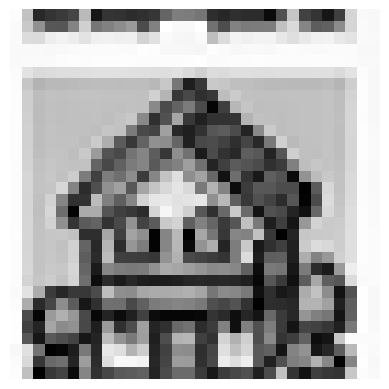

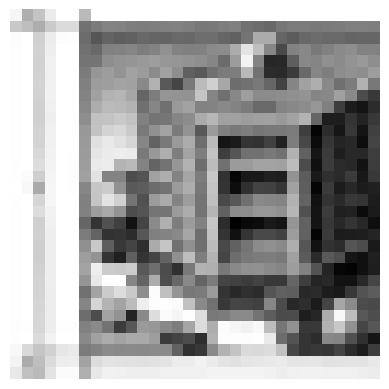

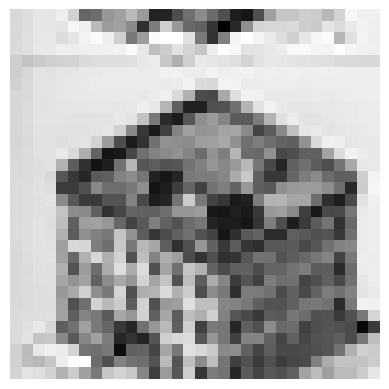

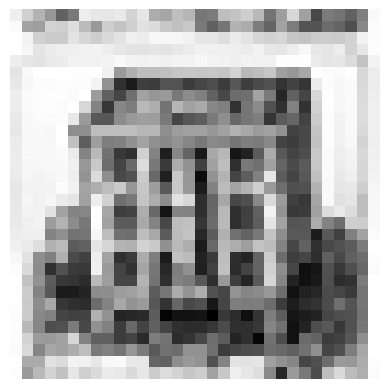

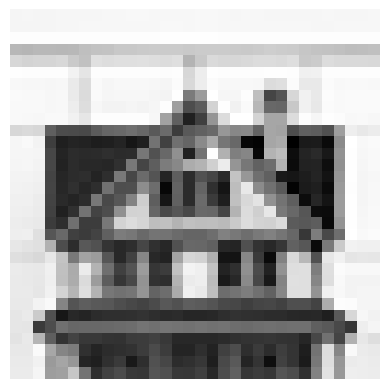

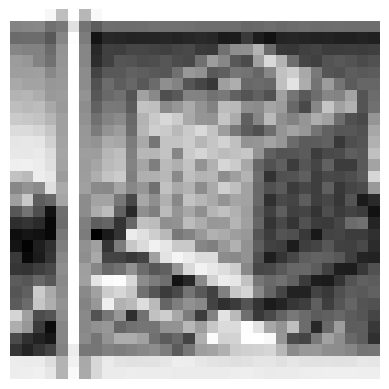

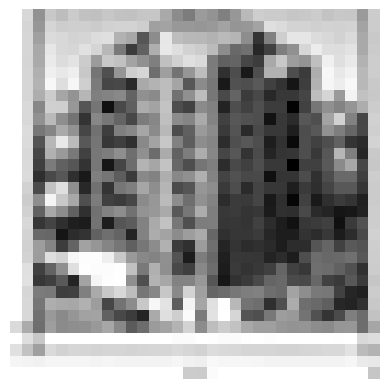

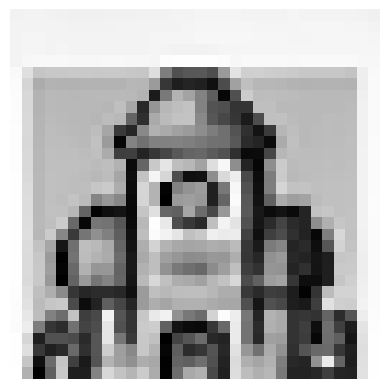

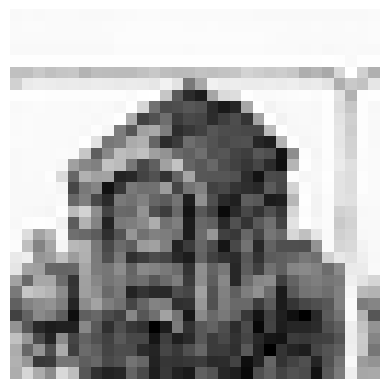

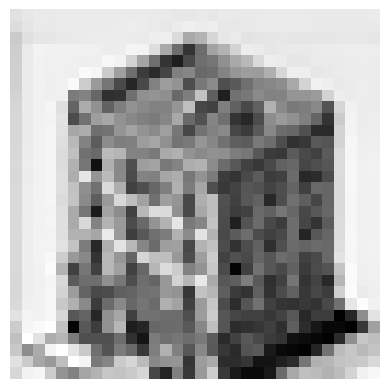

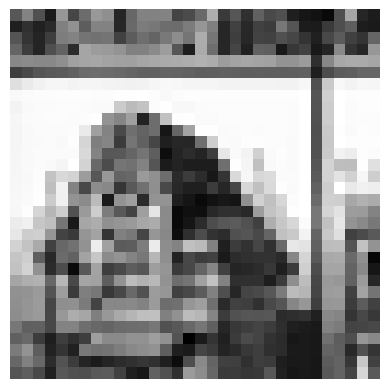

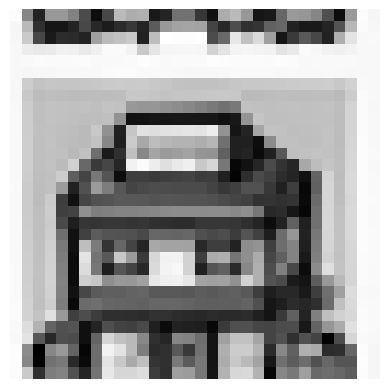

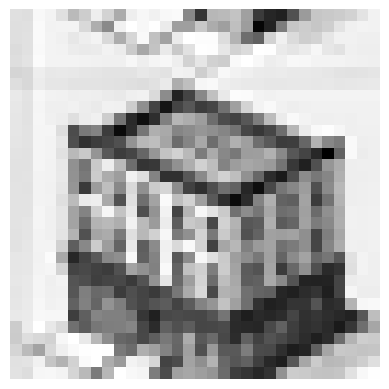

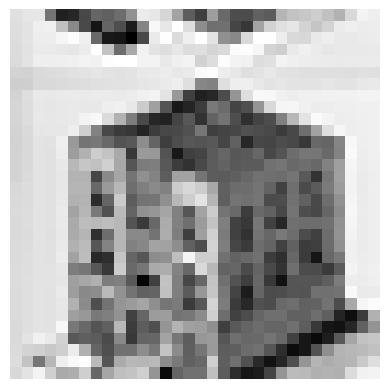

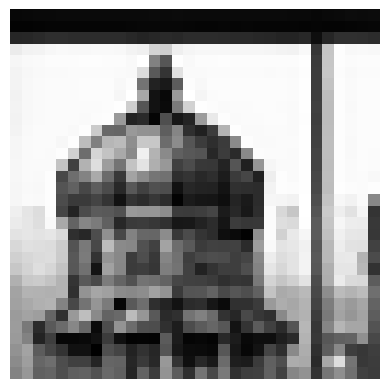

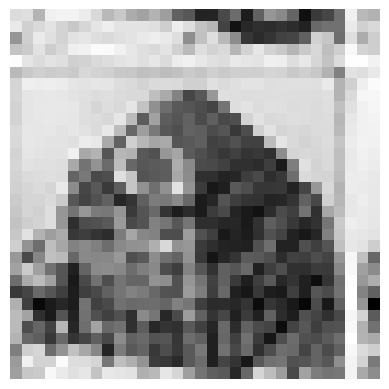

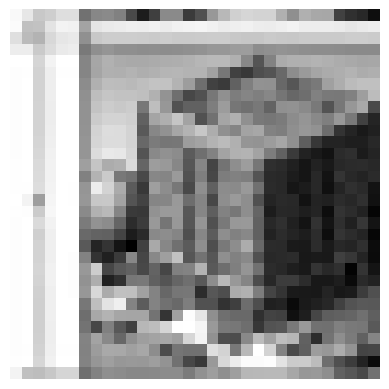

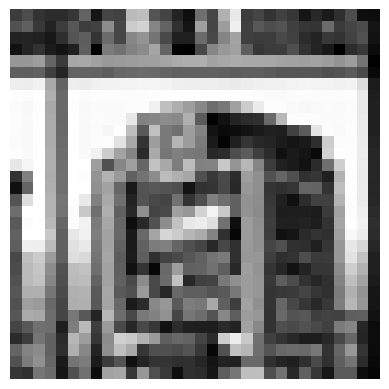

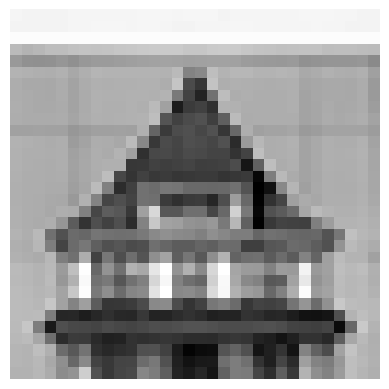

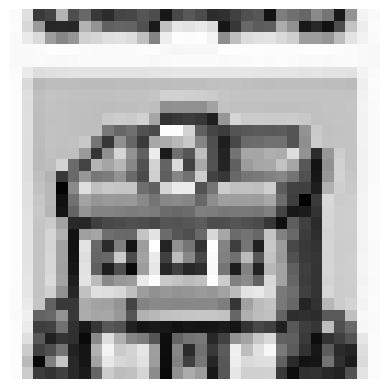

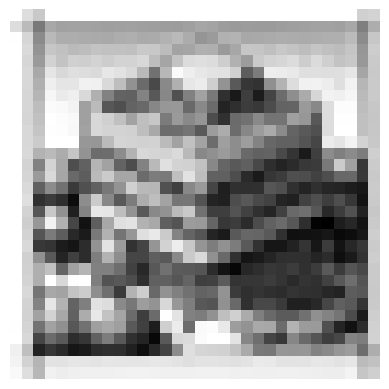

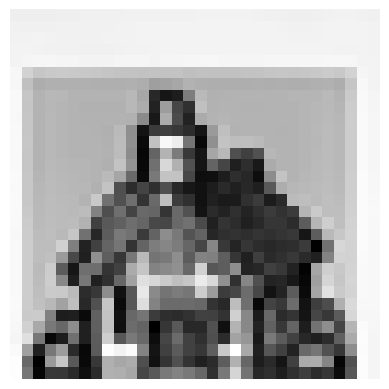

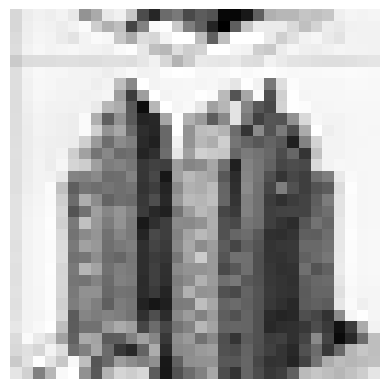

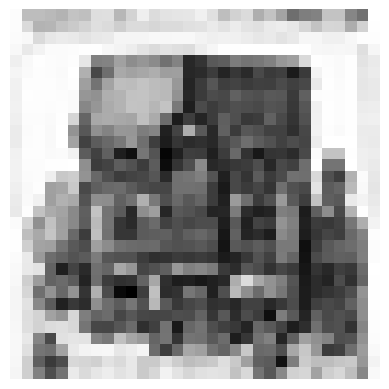

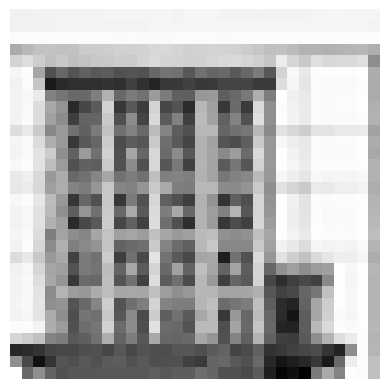

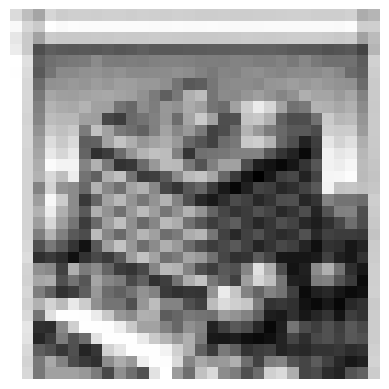

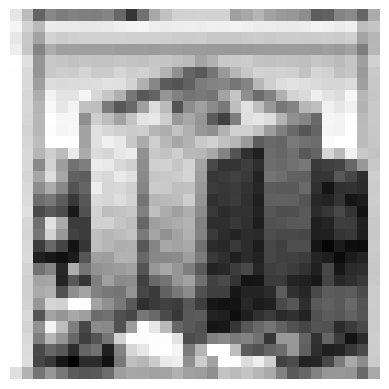

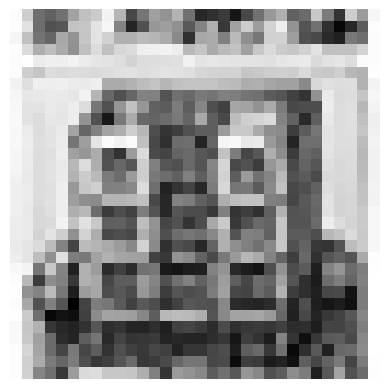

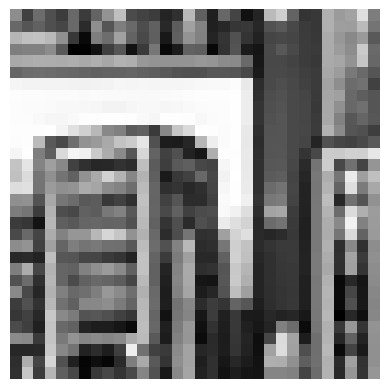

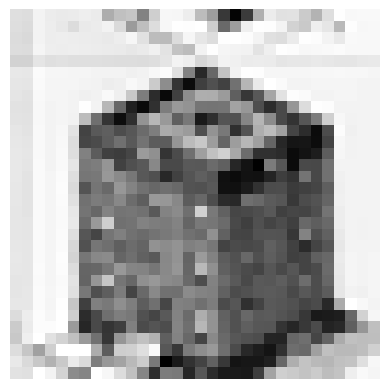

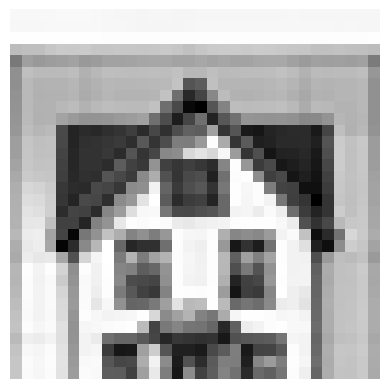

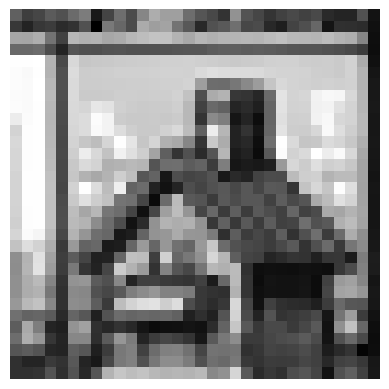

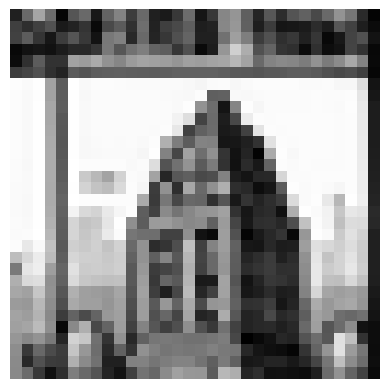

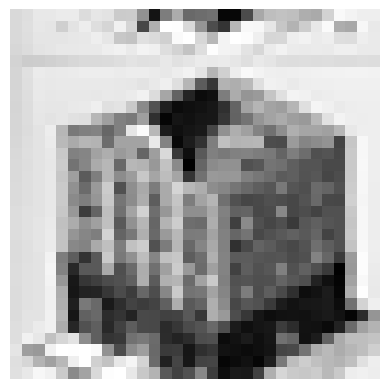

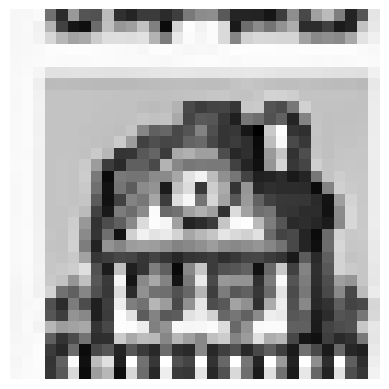

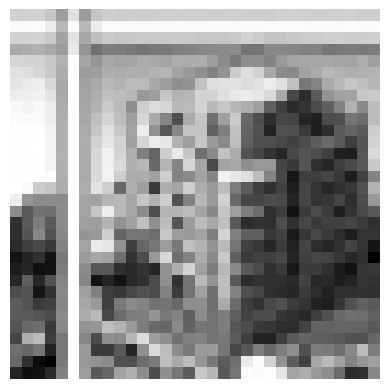

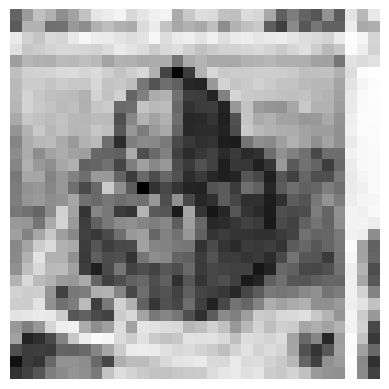

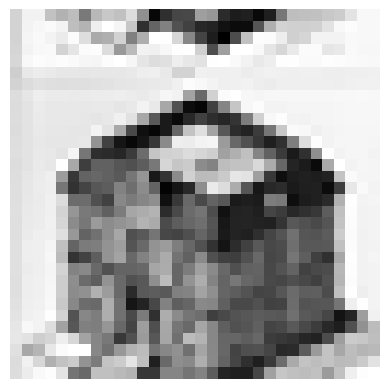

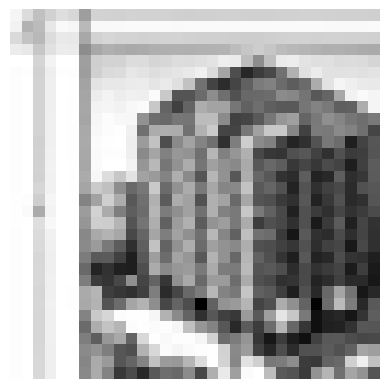

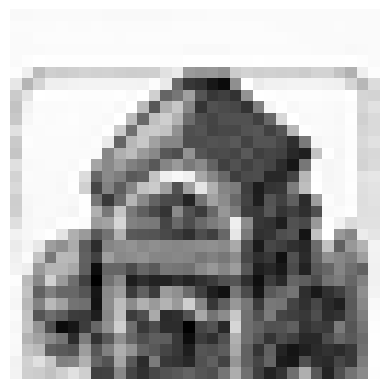

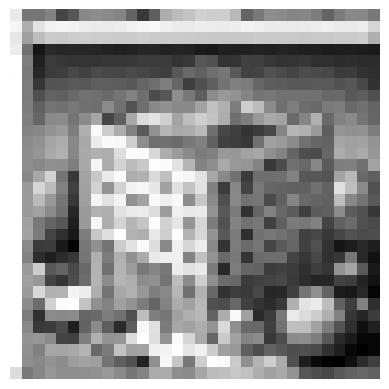

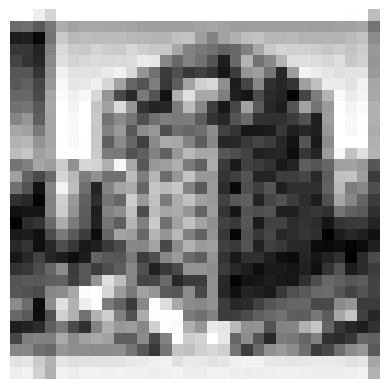

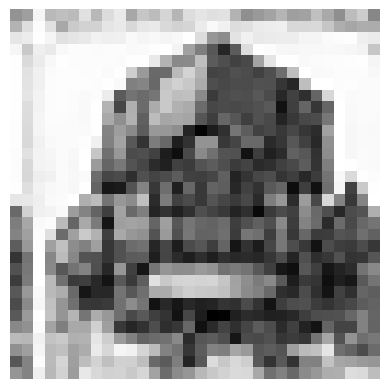

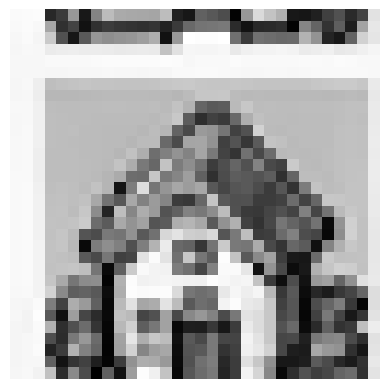

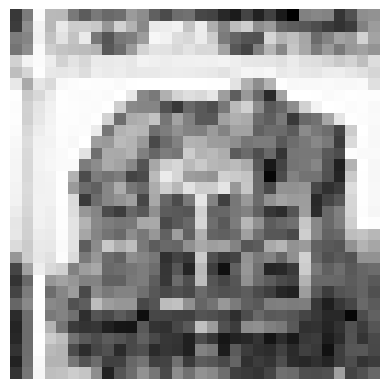

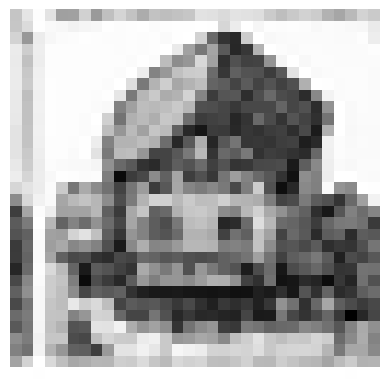

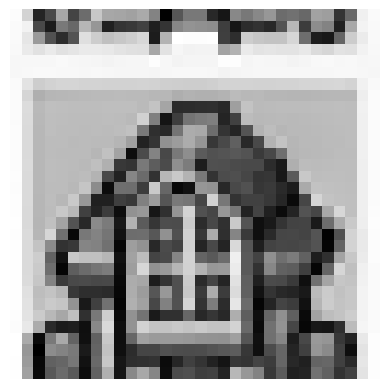

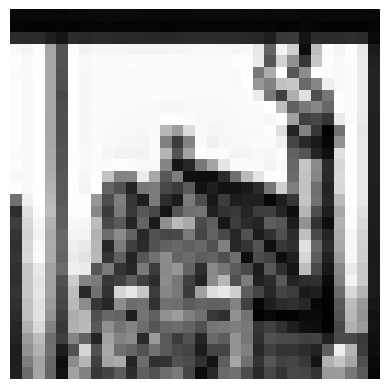

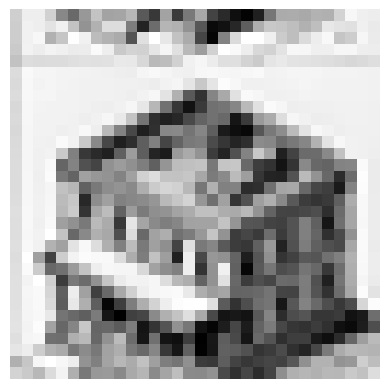

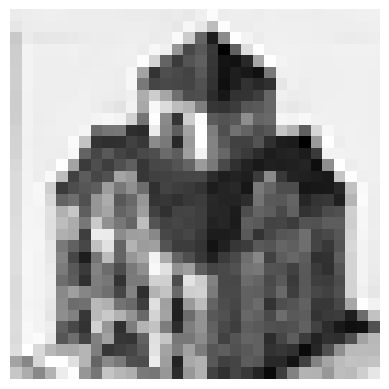

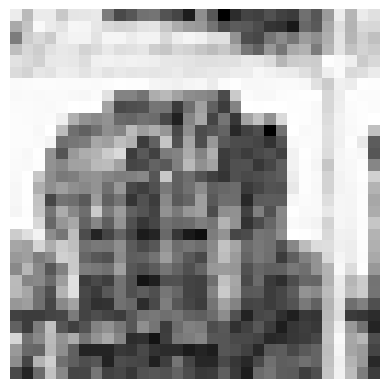

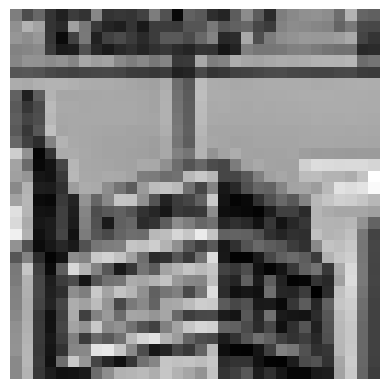

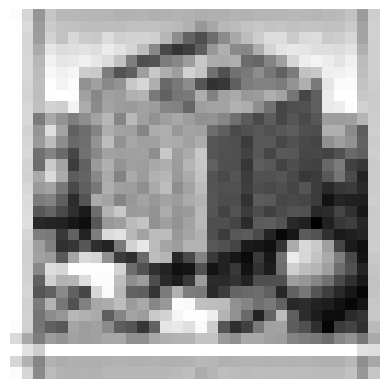

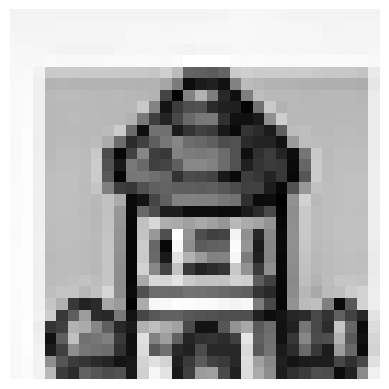

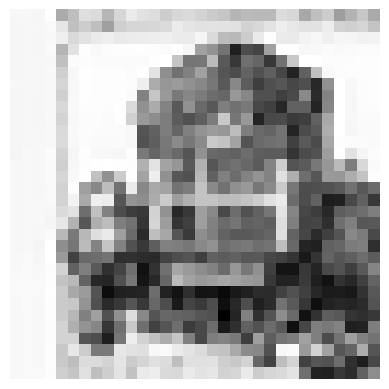

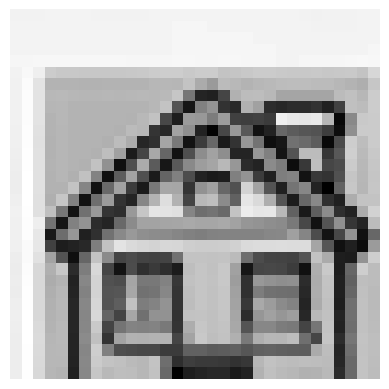

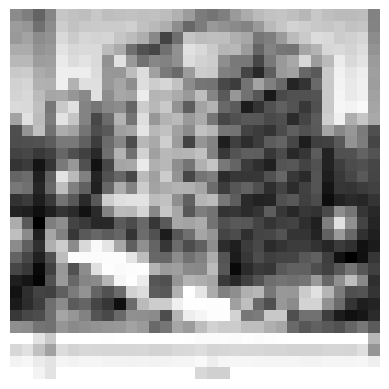

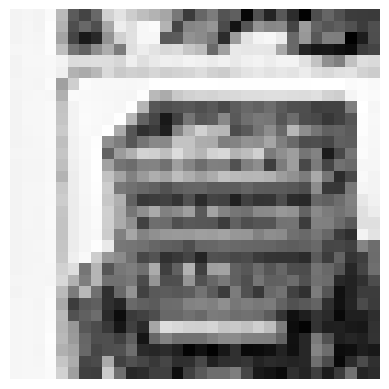

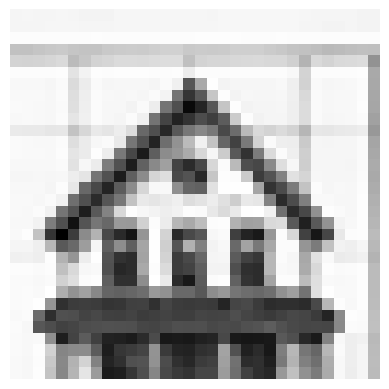

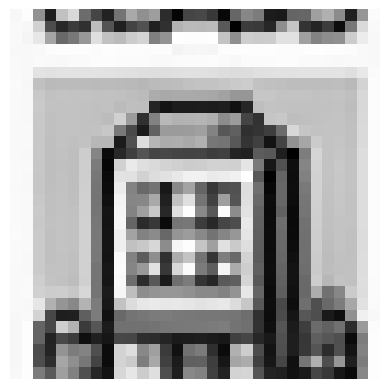

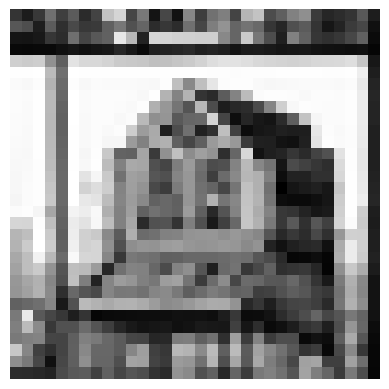

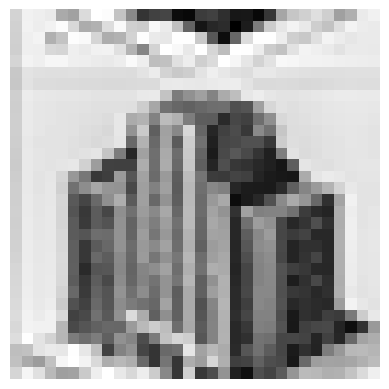

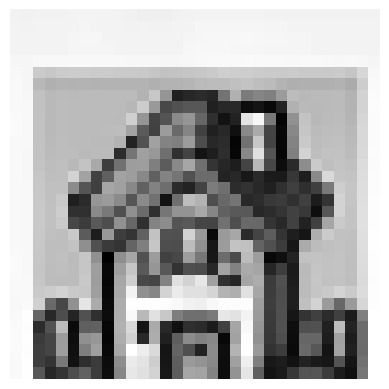

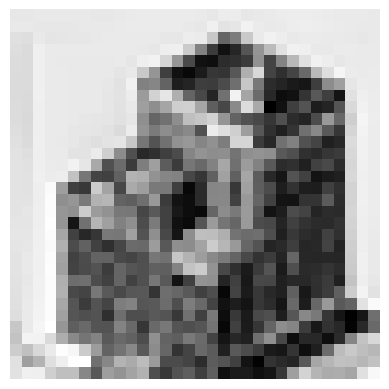

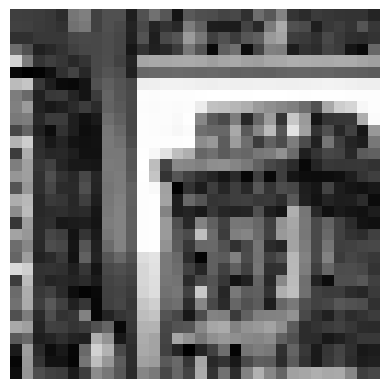

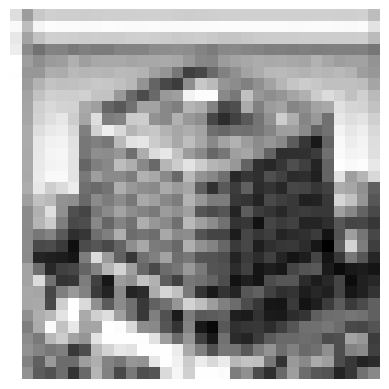

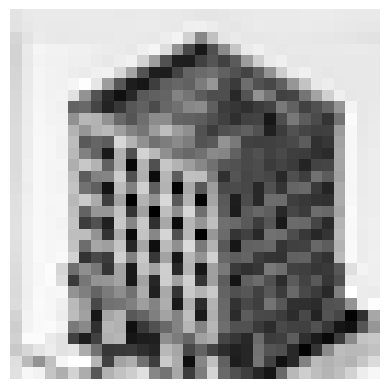

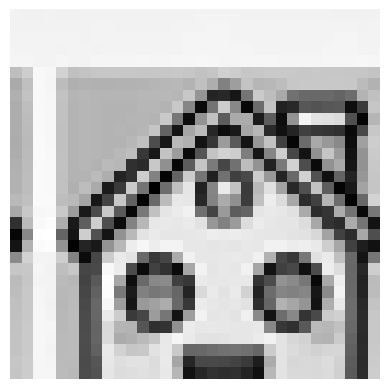

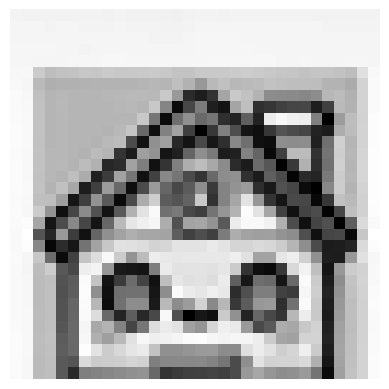

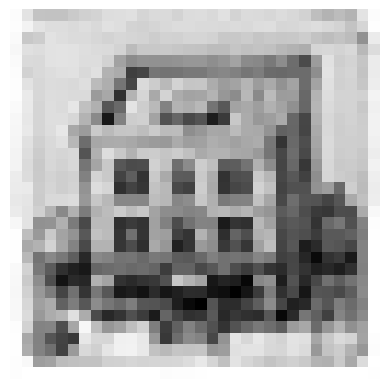

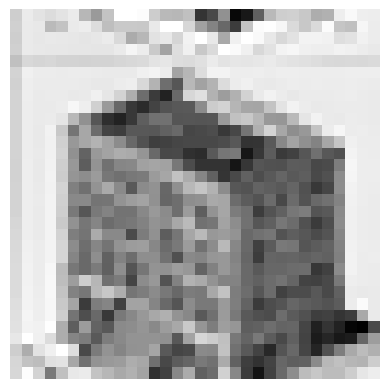

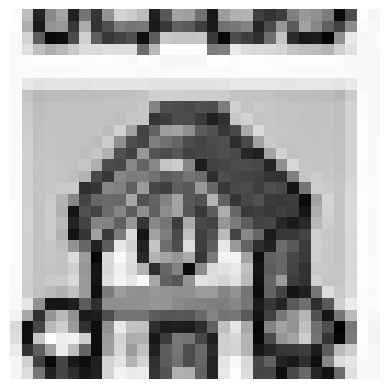

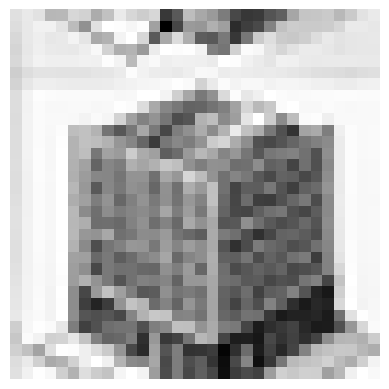

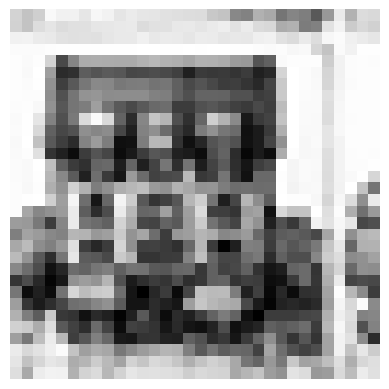

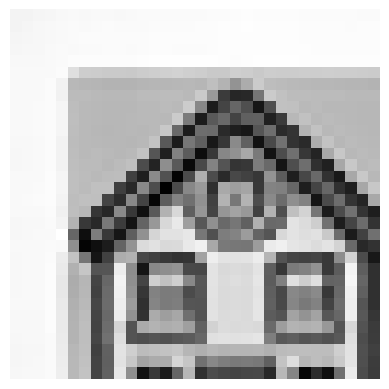

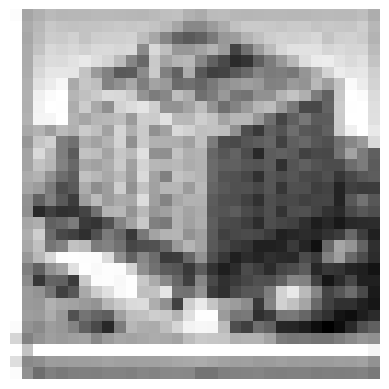

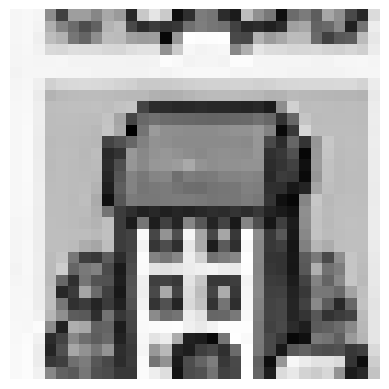

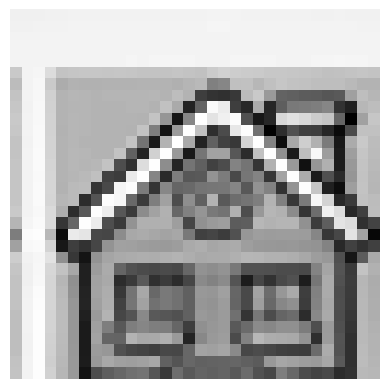

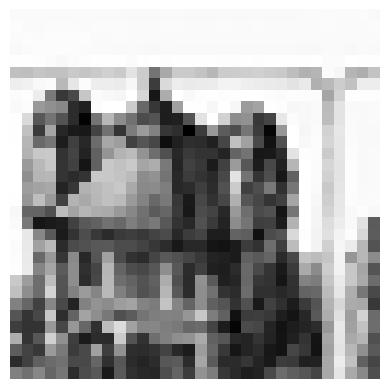

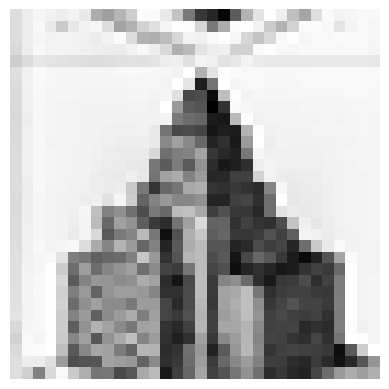

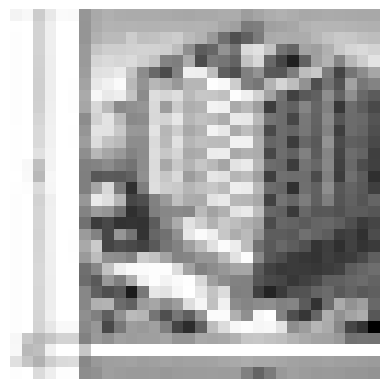

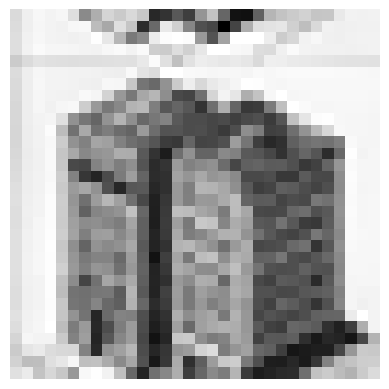

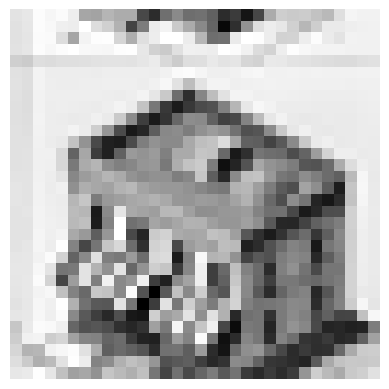

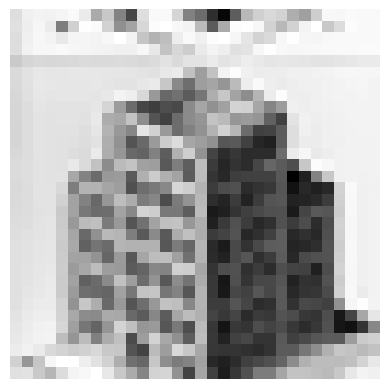

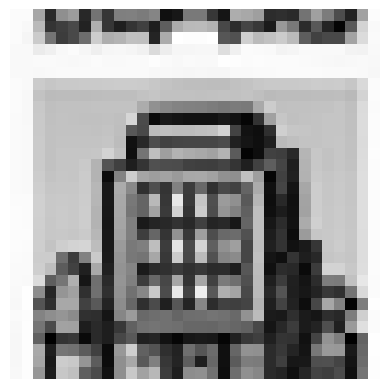

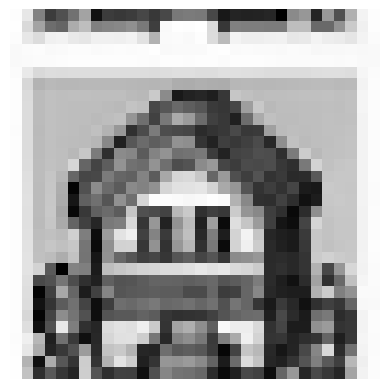

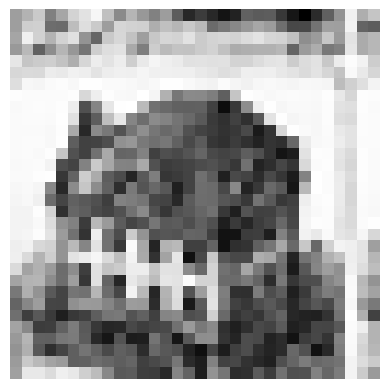

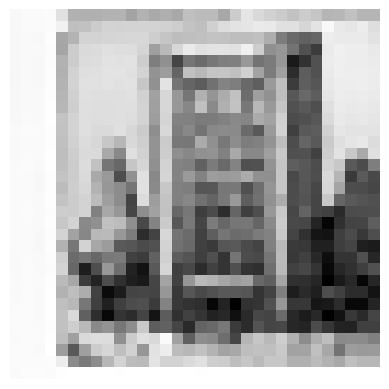

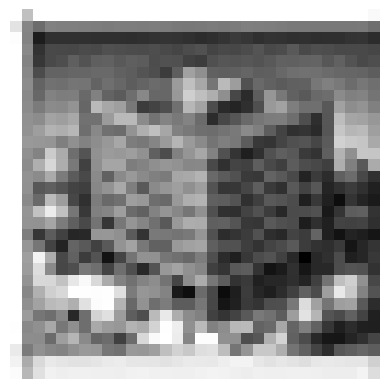

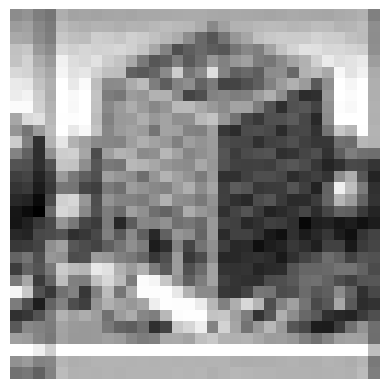

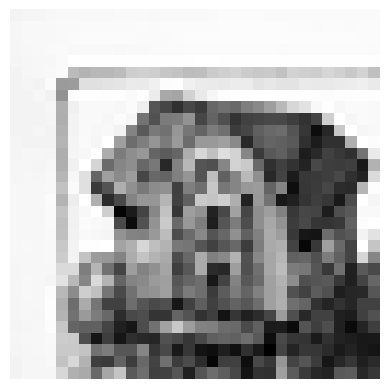

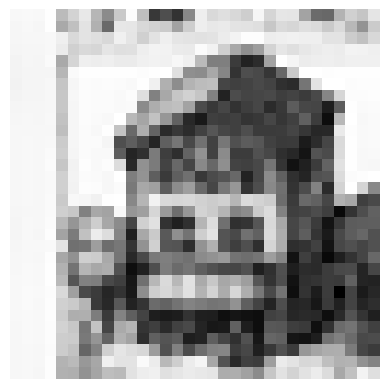

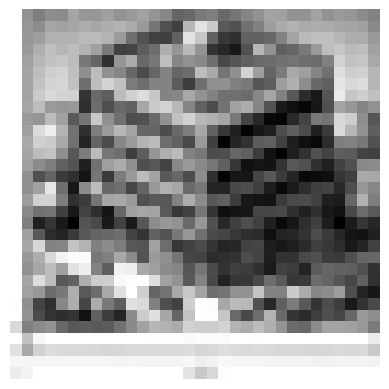

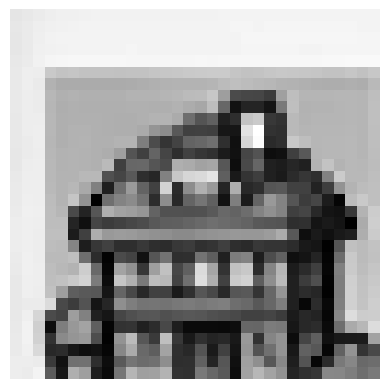

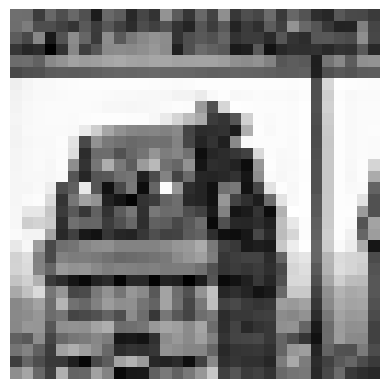

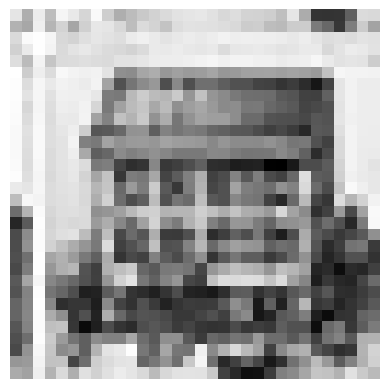

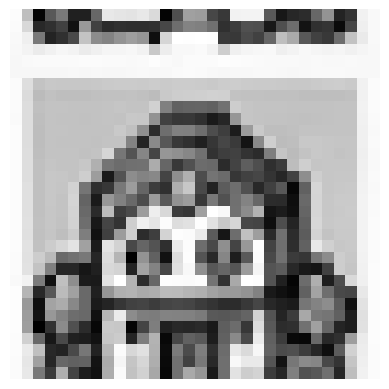

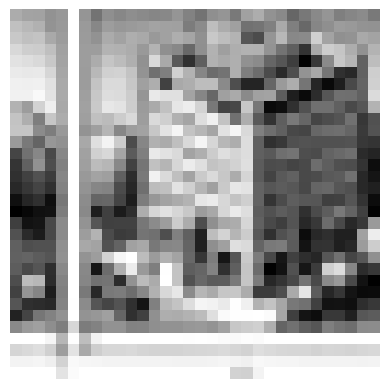

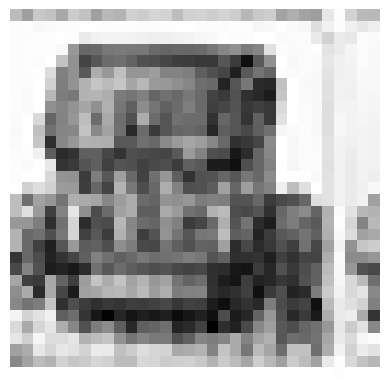

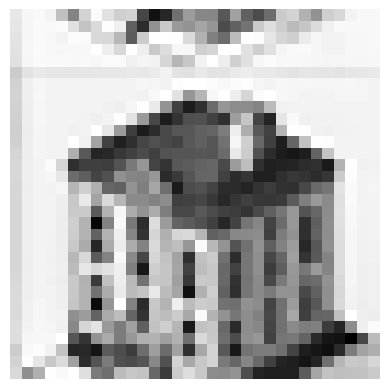

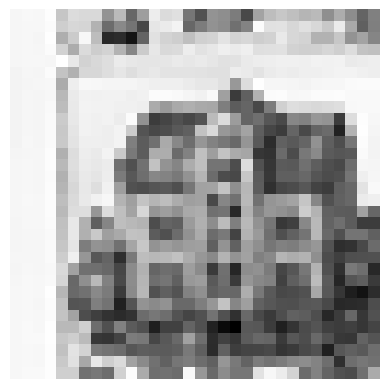

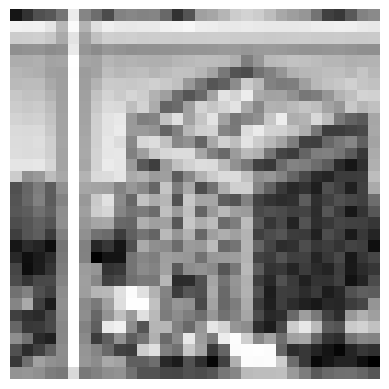

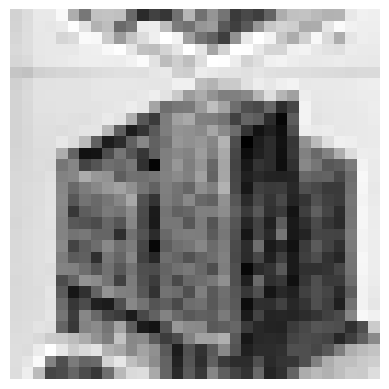

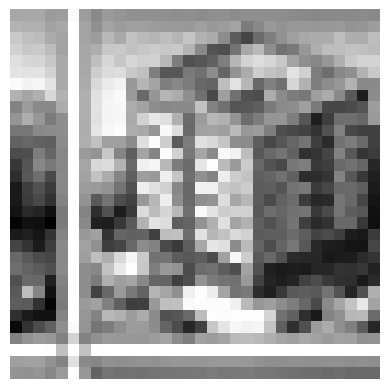

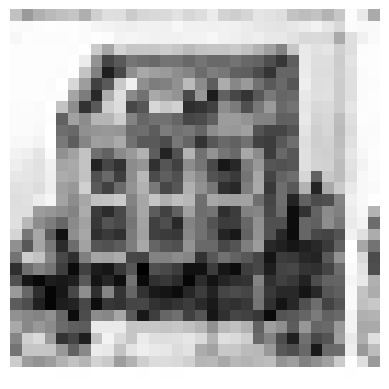

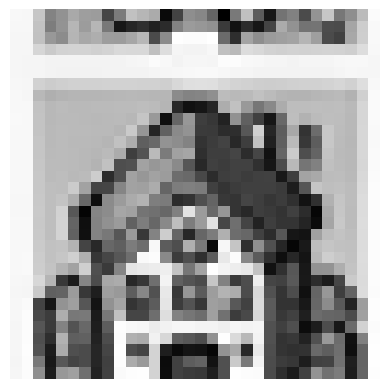

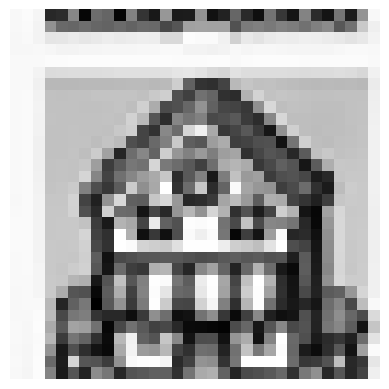

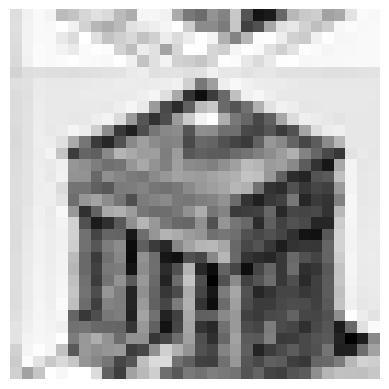

Label: cat, Len: 90


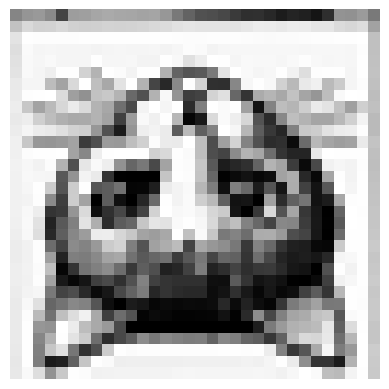

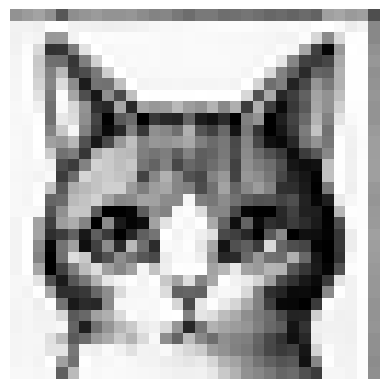

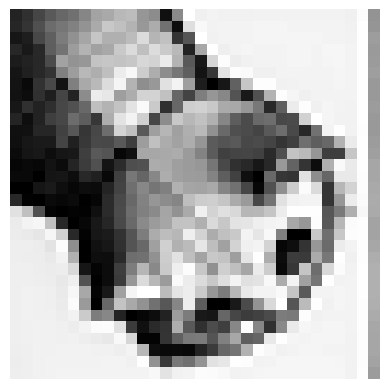

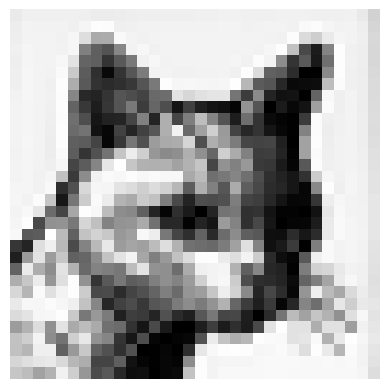

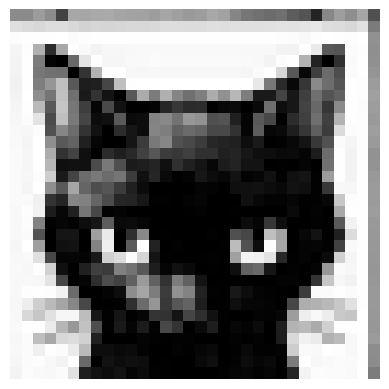

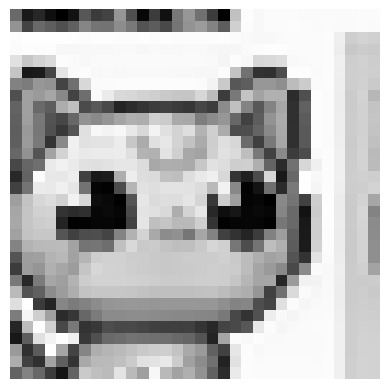

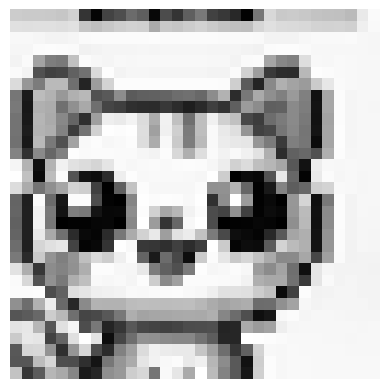

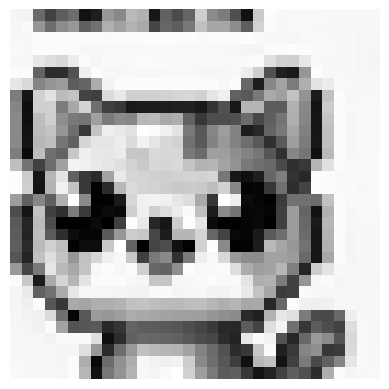

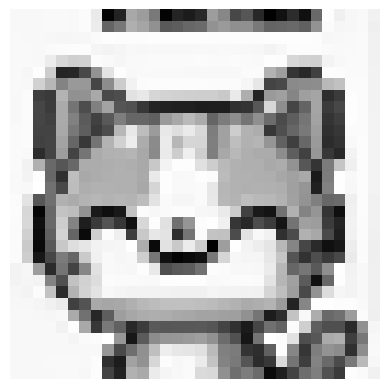

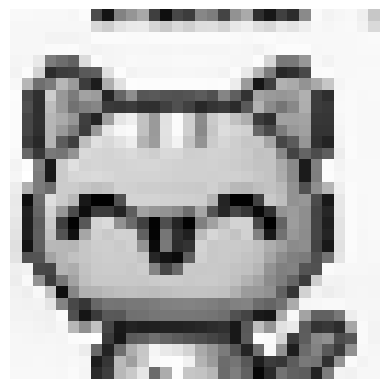

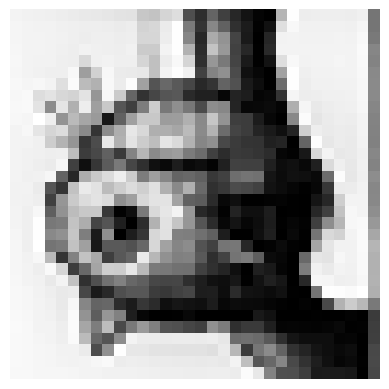

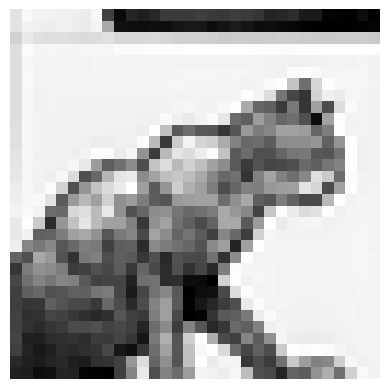

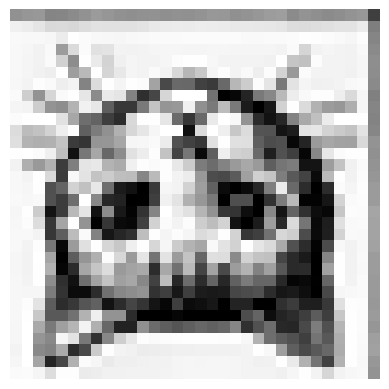

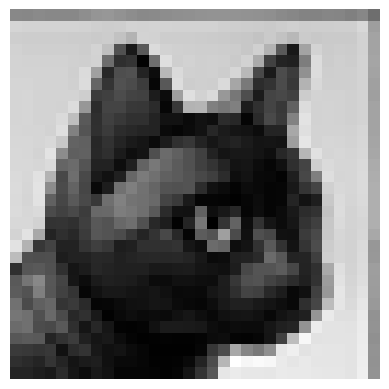

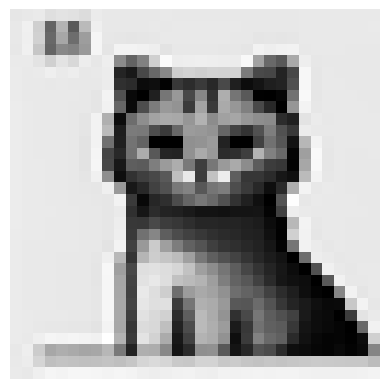

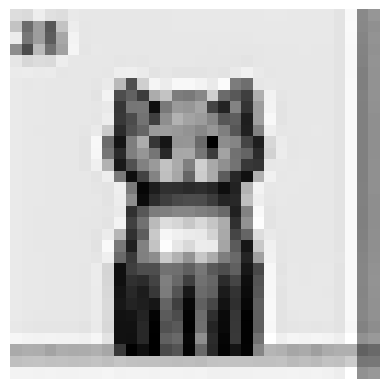

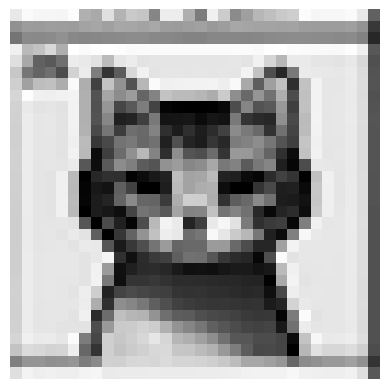

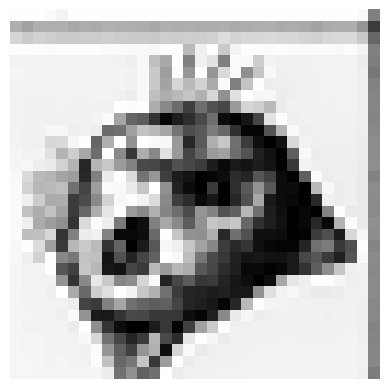

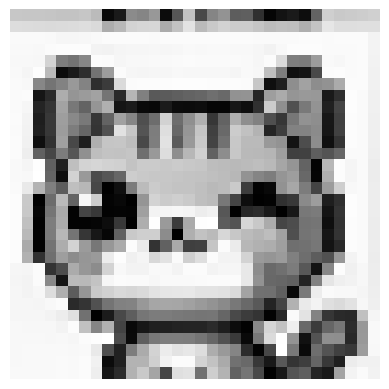

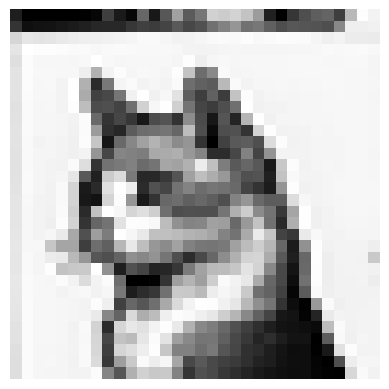

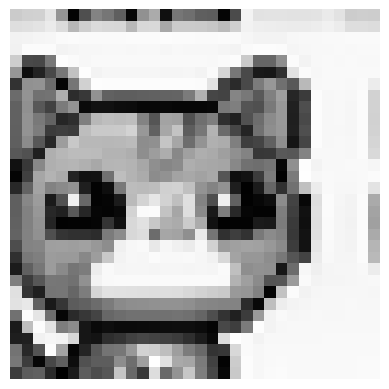

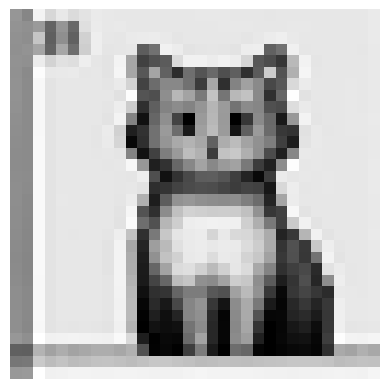

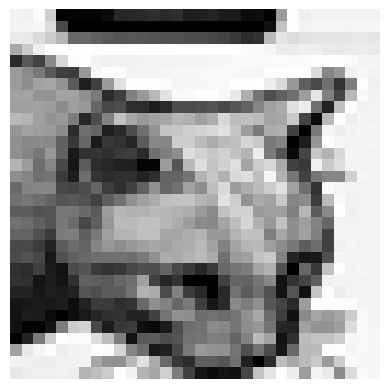

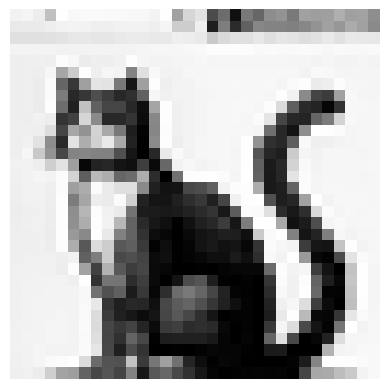

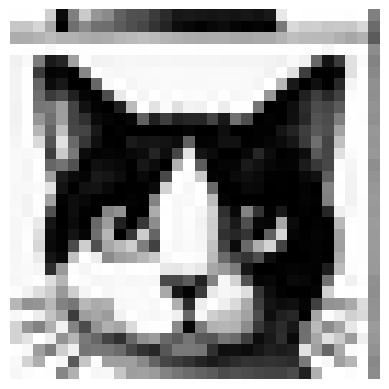

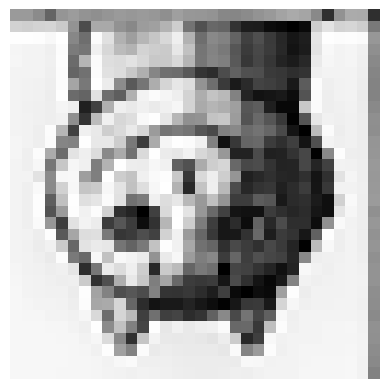

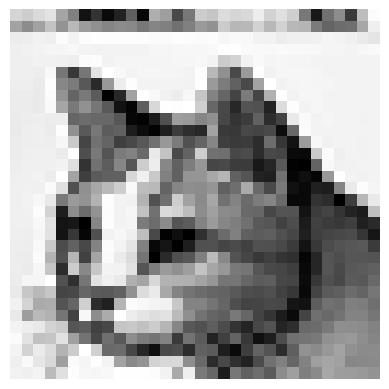

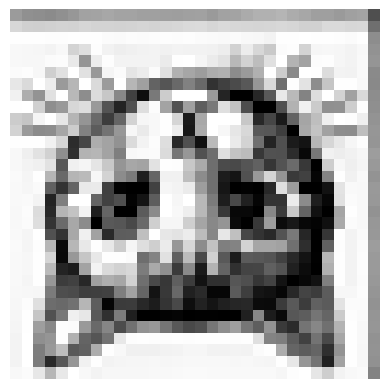

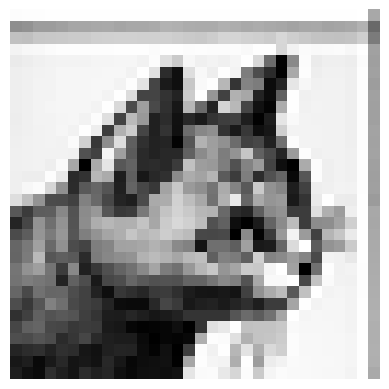

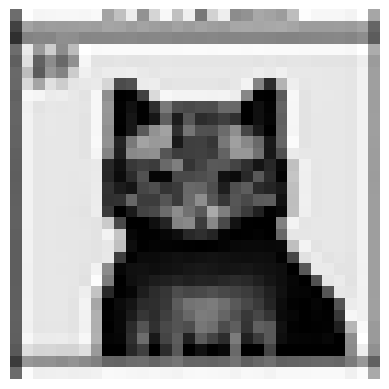

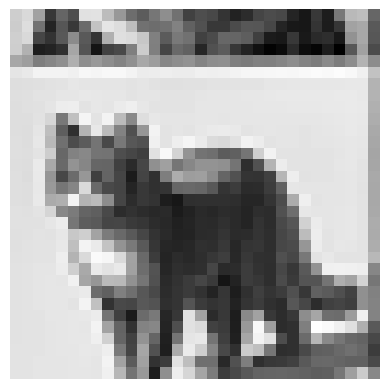

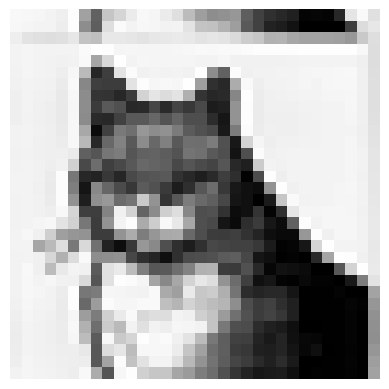

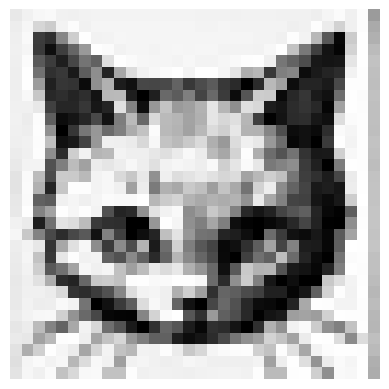

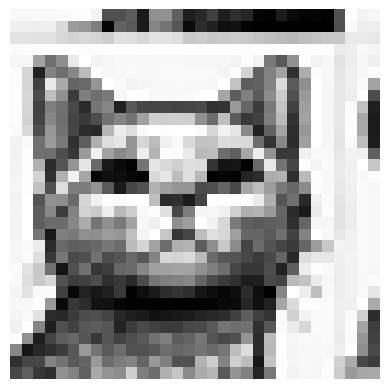

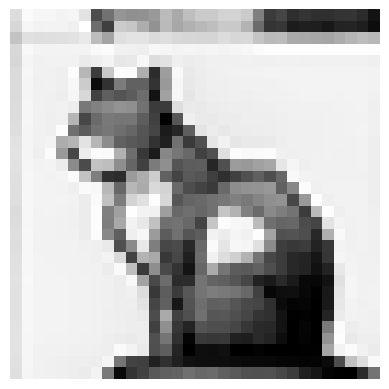

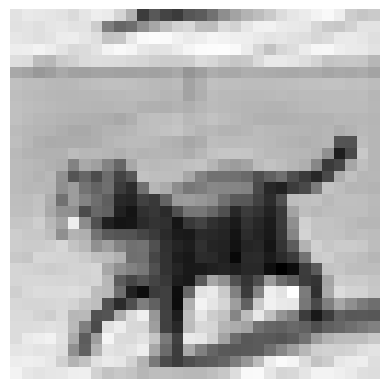

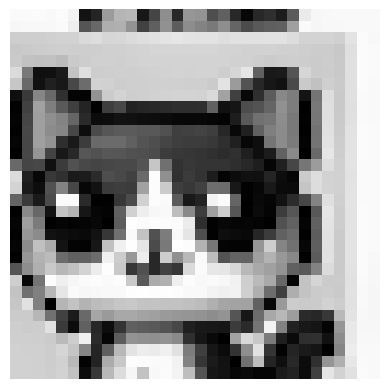

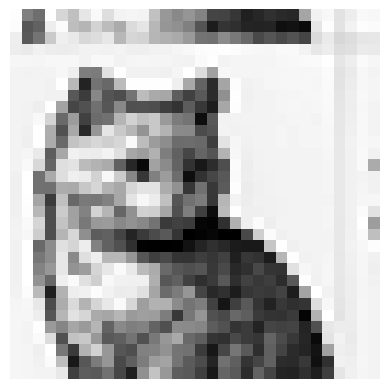

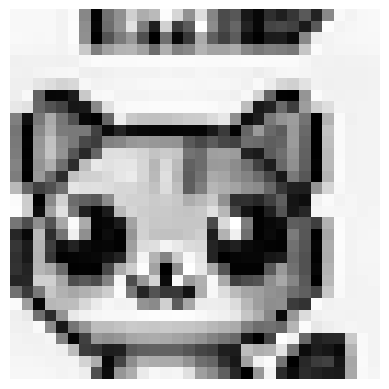

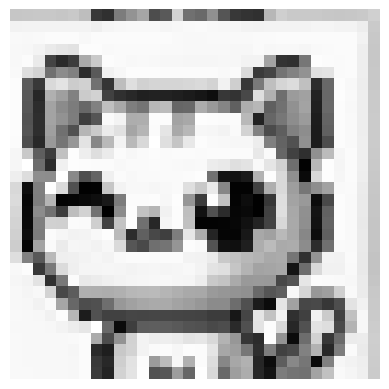

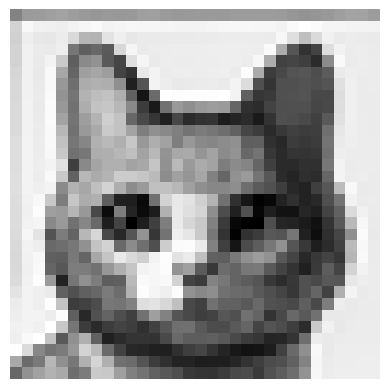

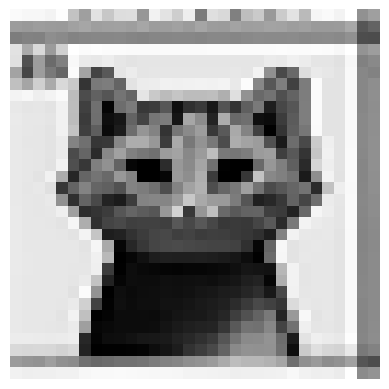

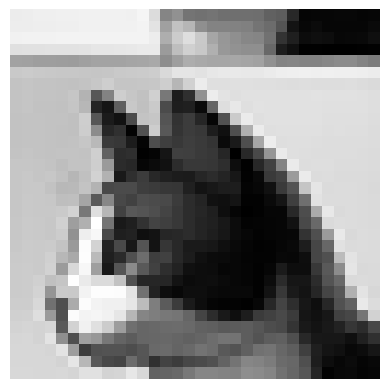

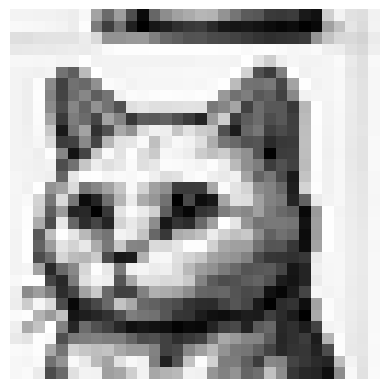

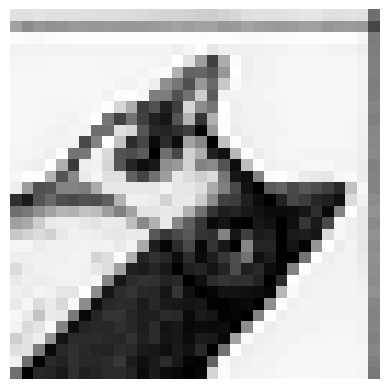

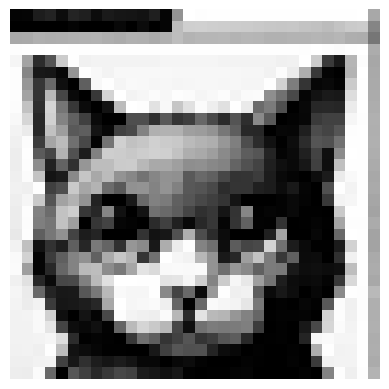

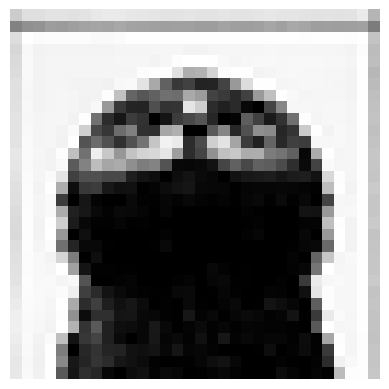

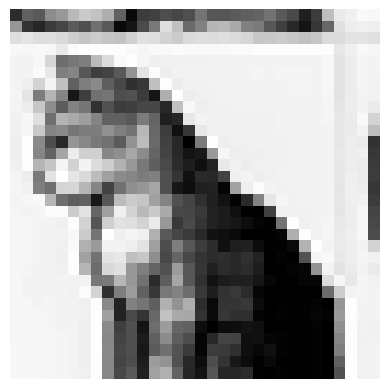

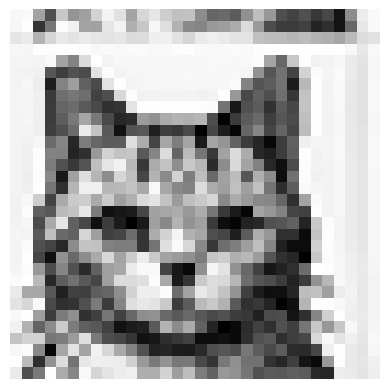

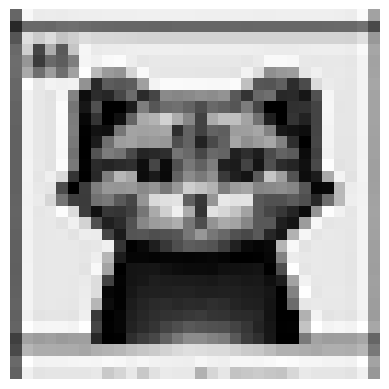

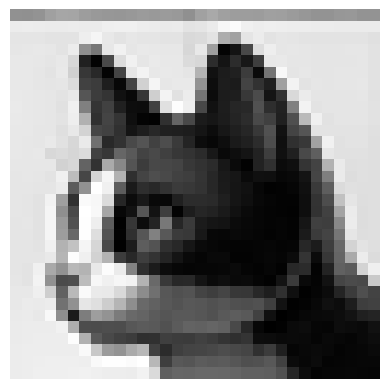

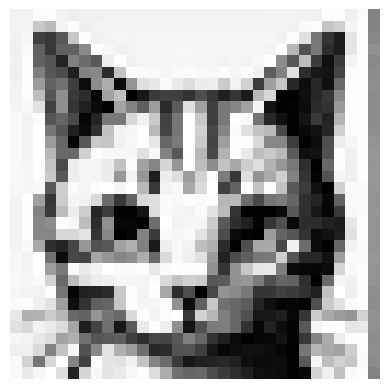

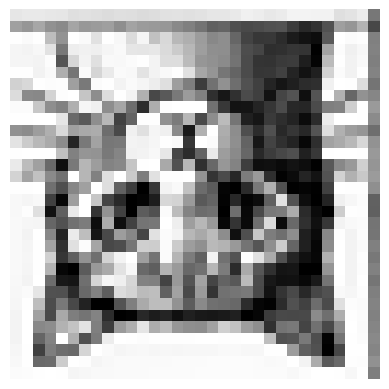

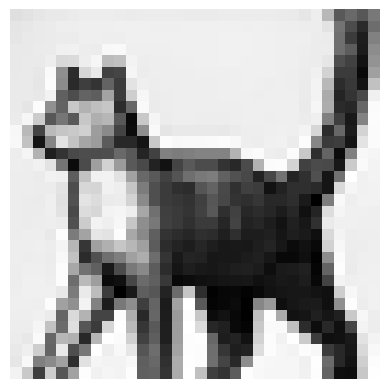

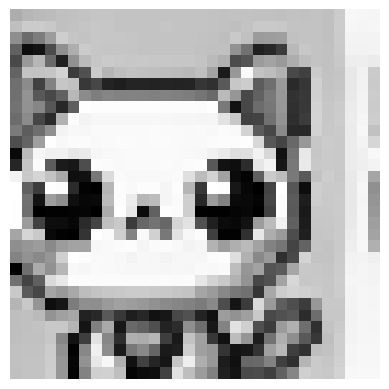

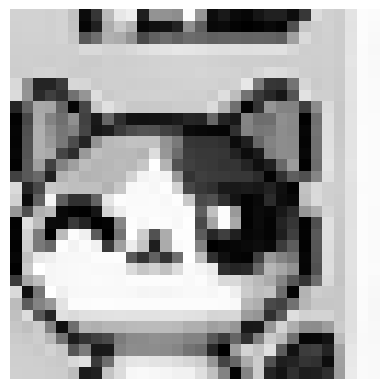

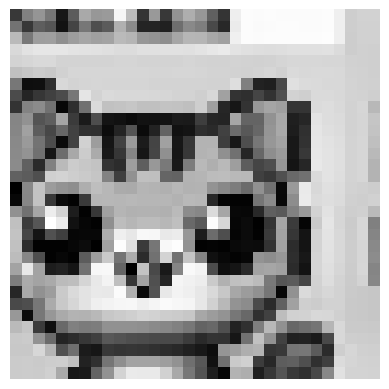

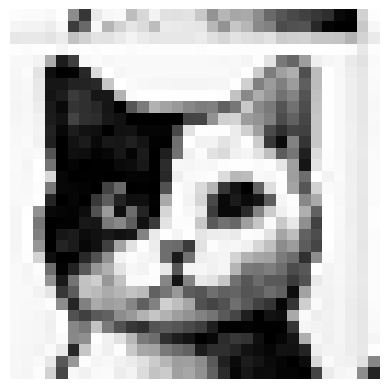

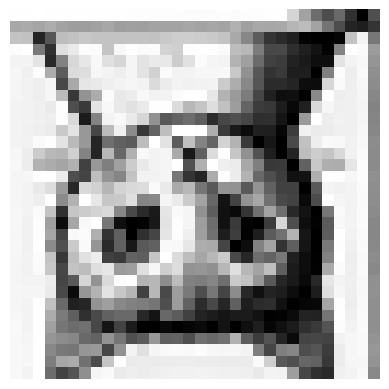

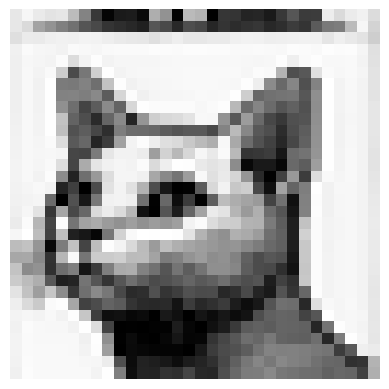

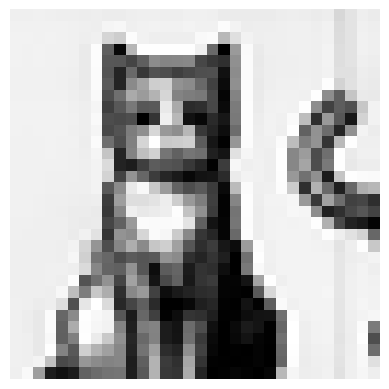

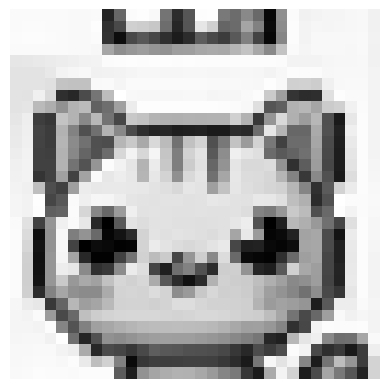

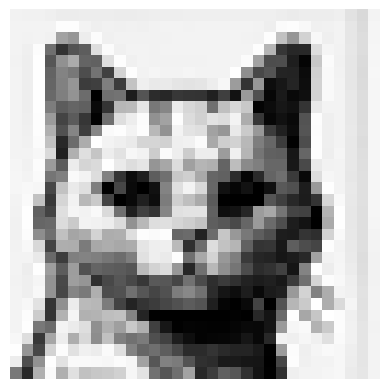

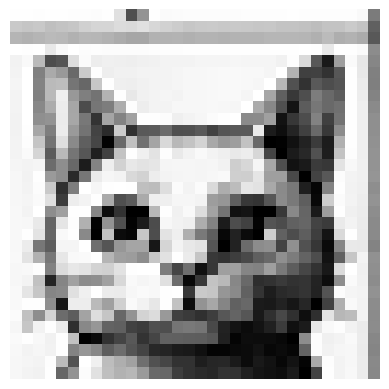

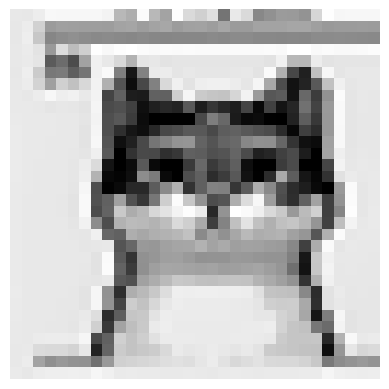

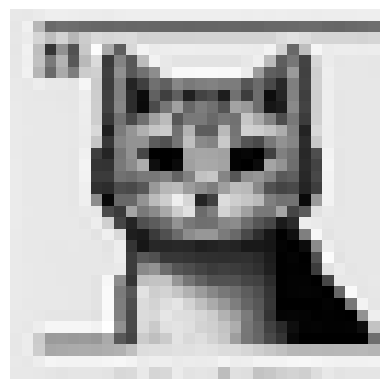

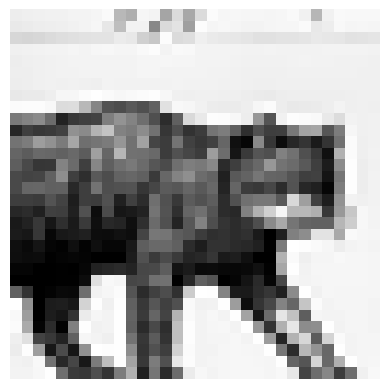

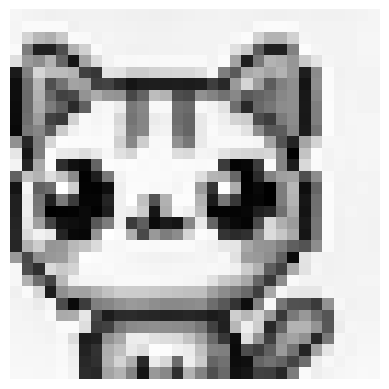

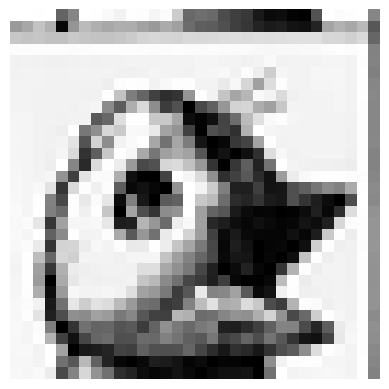

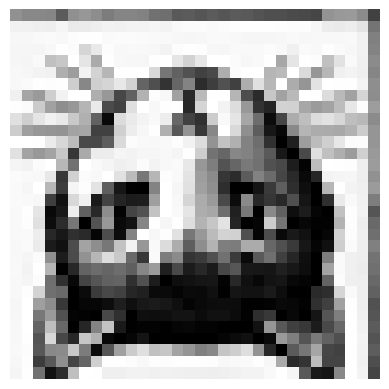

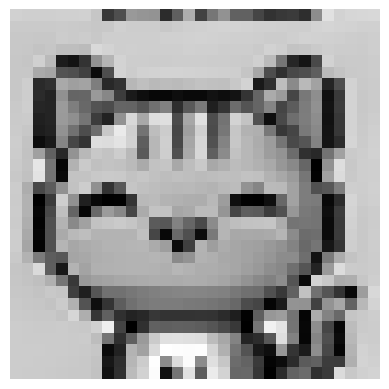

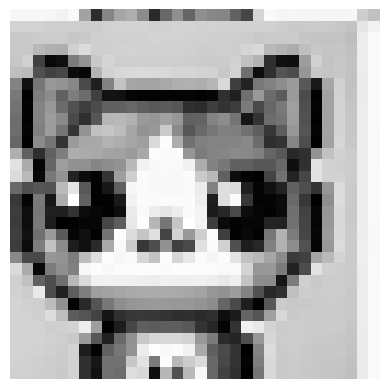

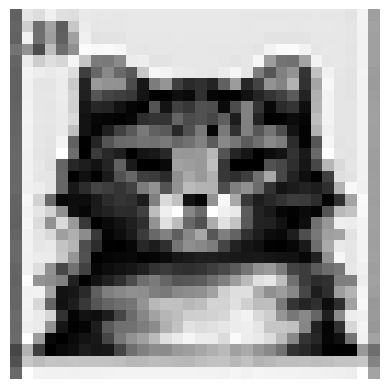

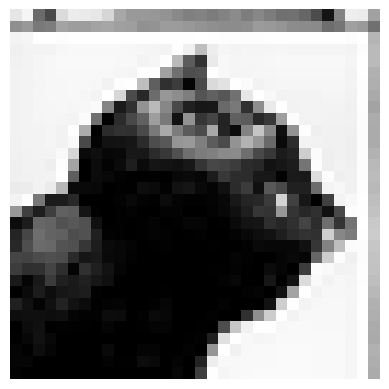

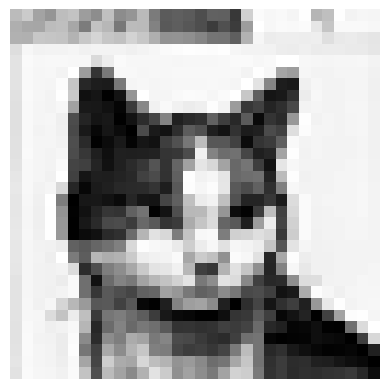

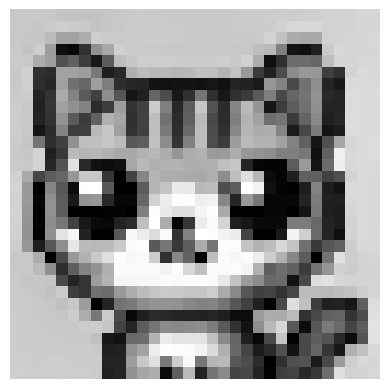

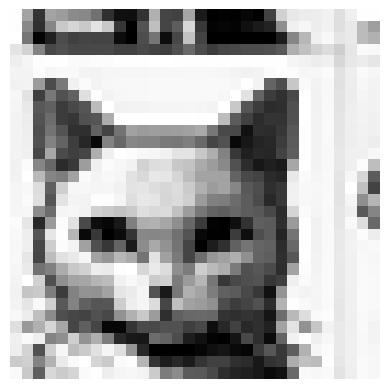

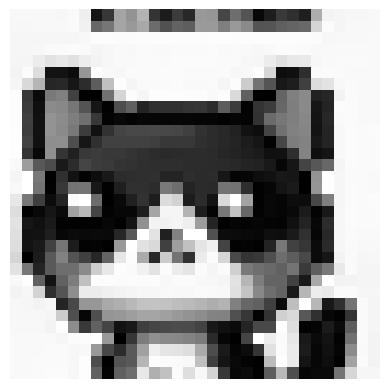

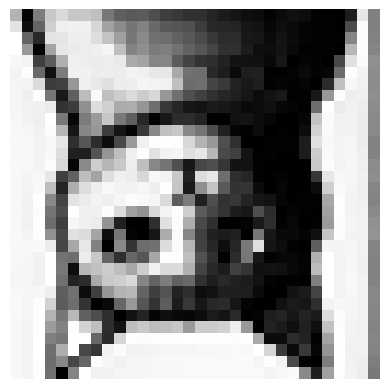

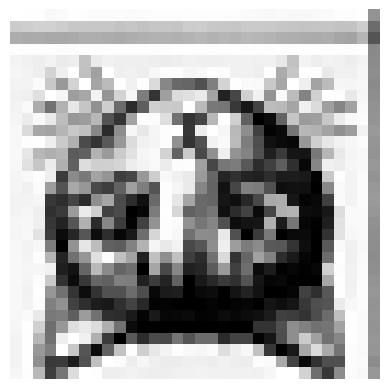

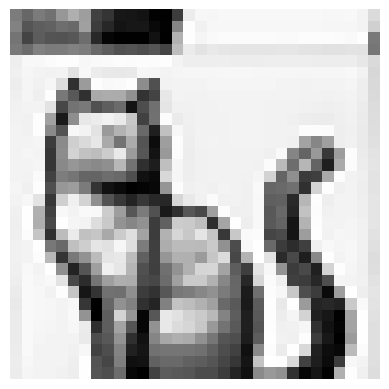

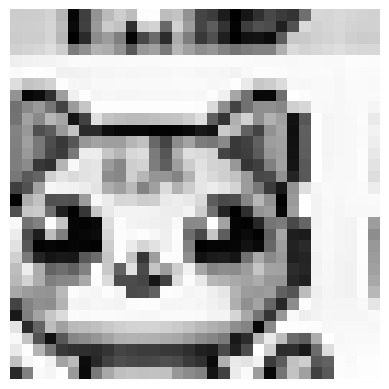

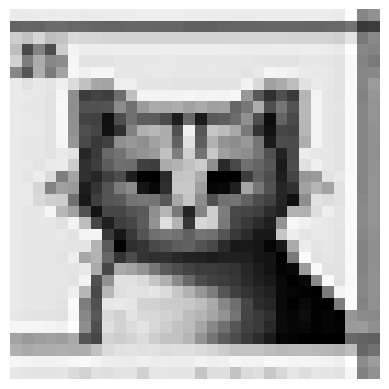

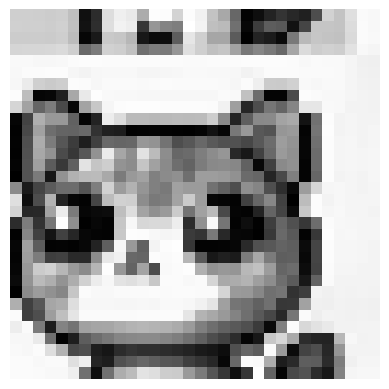

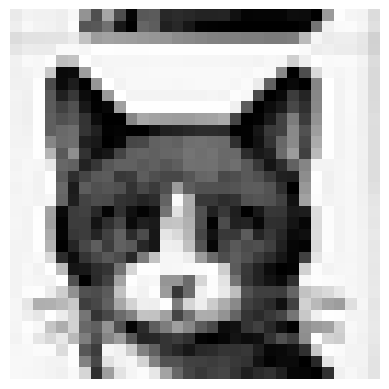

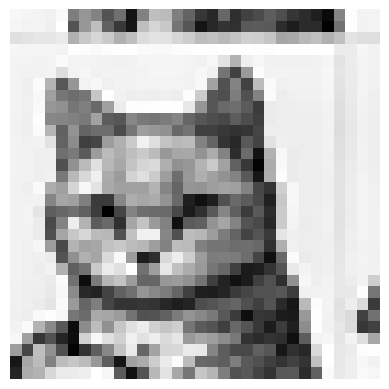

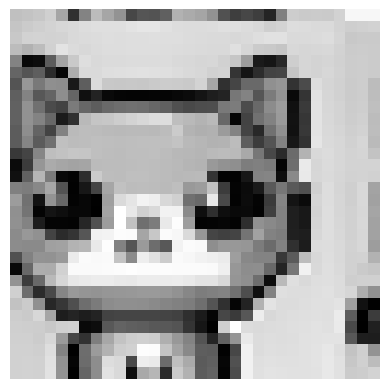

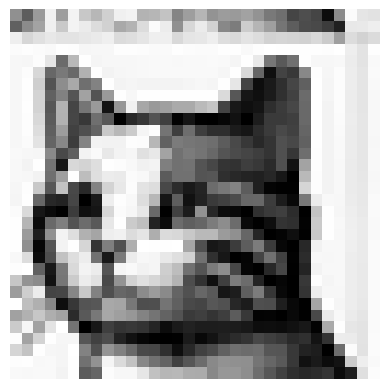

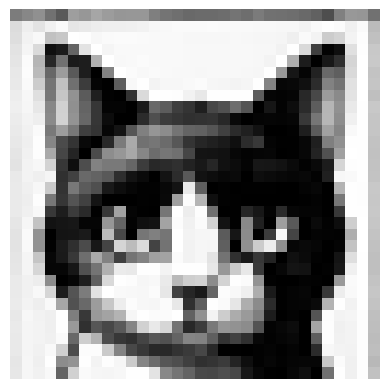

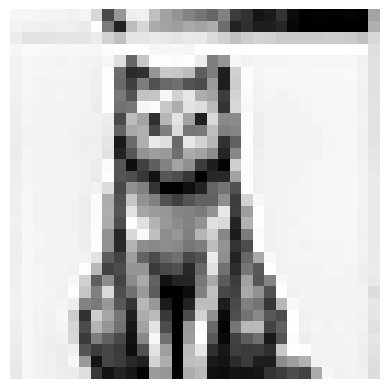

Label: airplane, Len: 95


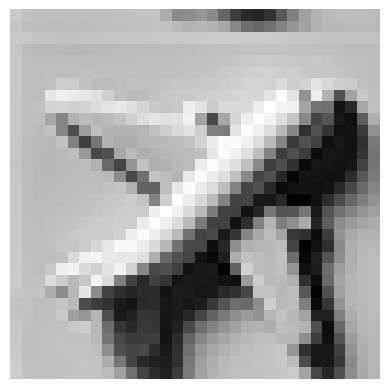

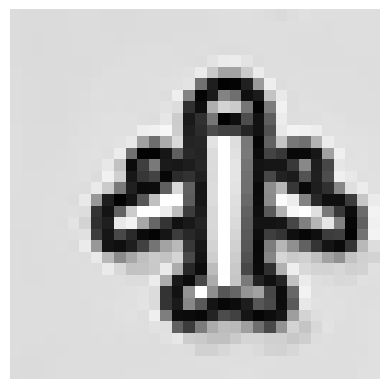

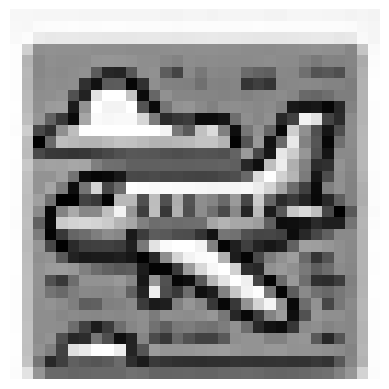

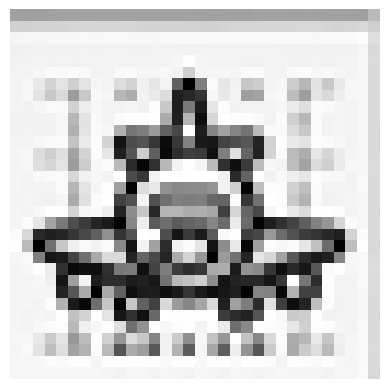

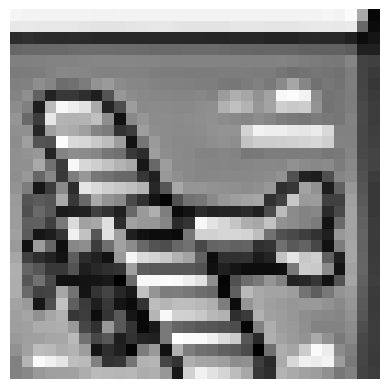

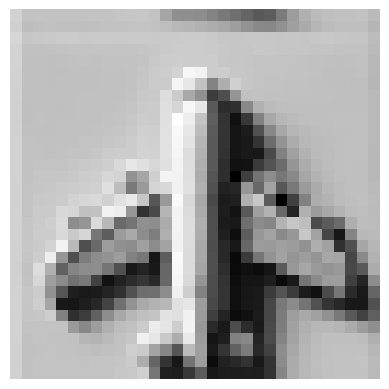

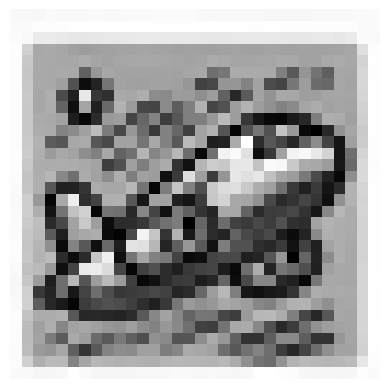

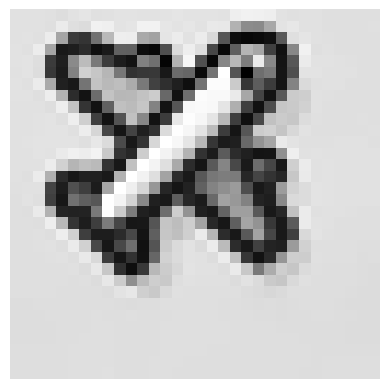

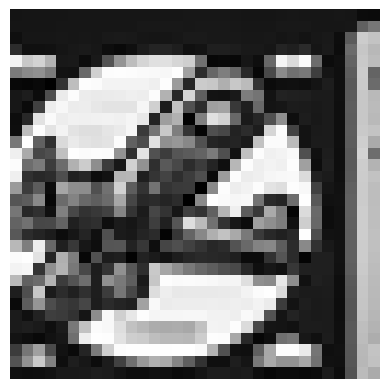

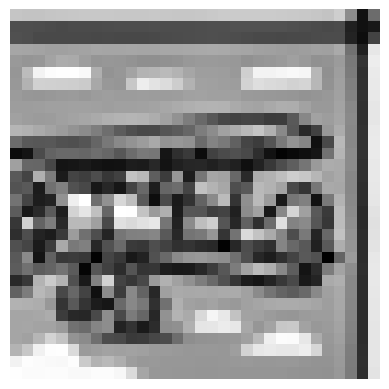

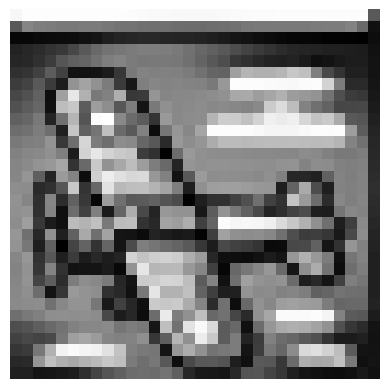

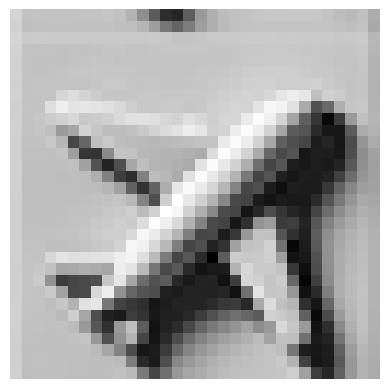

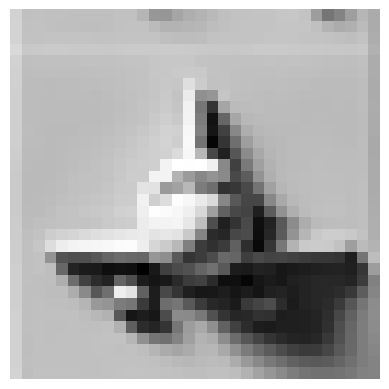

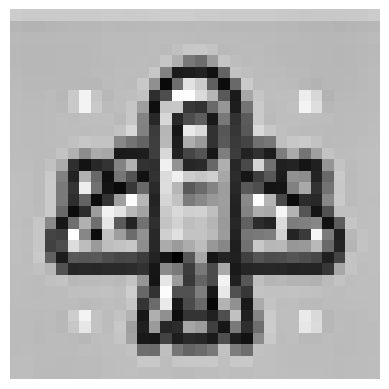

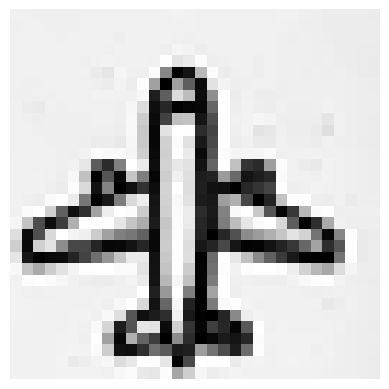

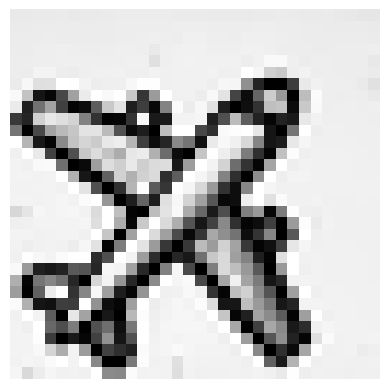

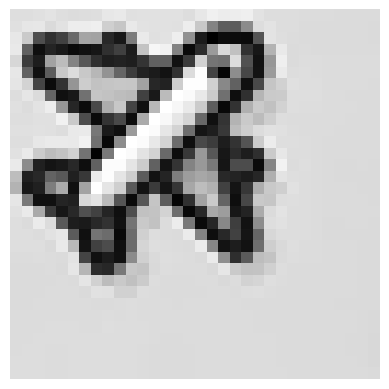

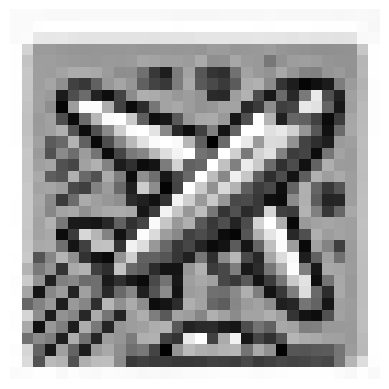

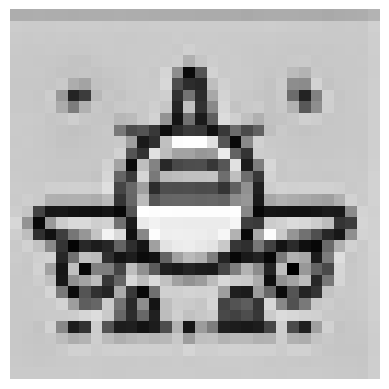

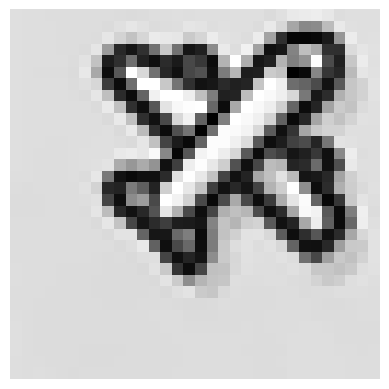

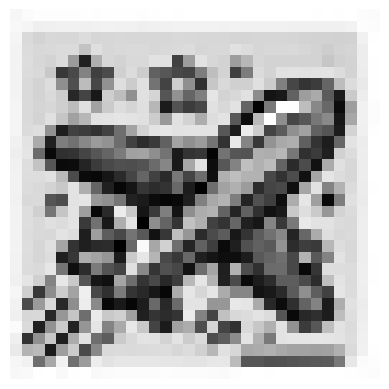

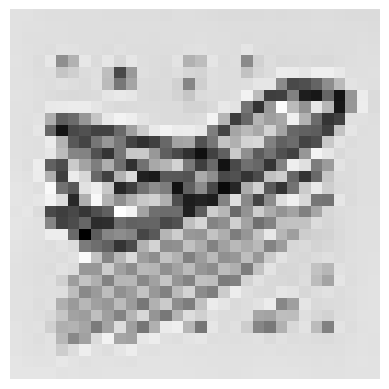

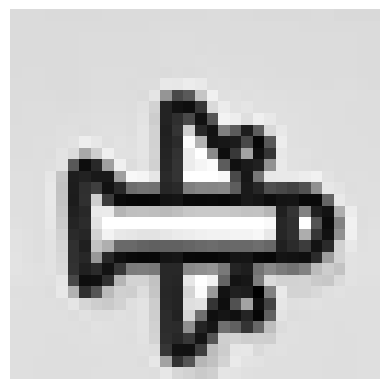

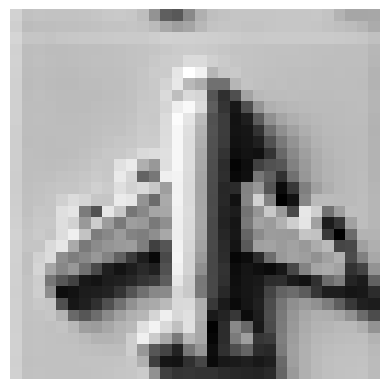

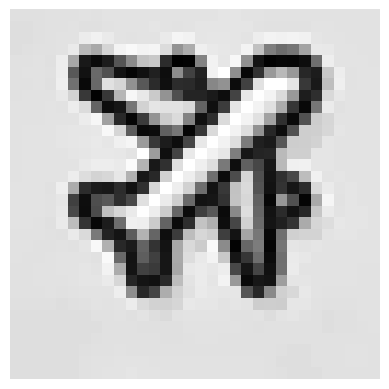

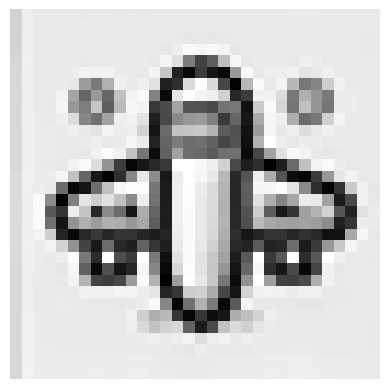

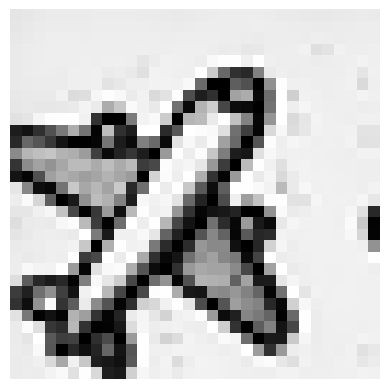

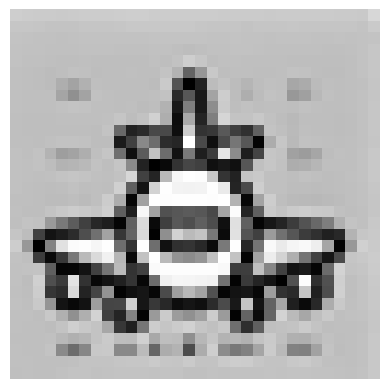

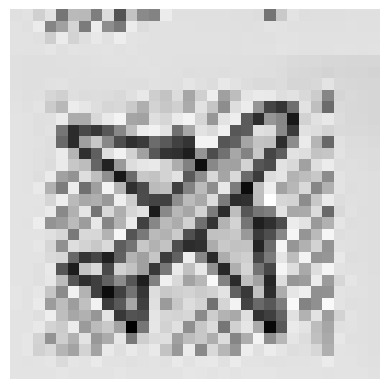

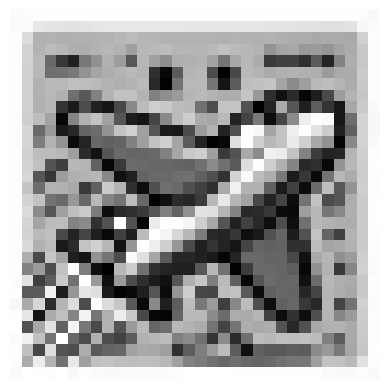

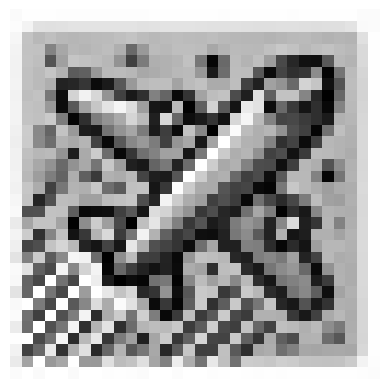

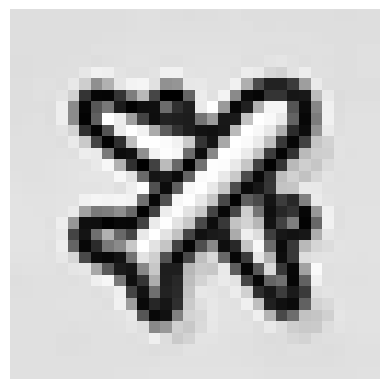

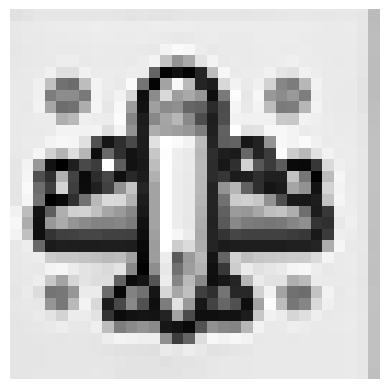

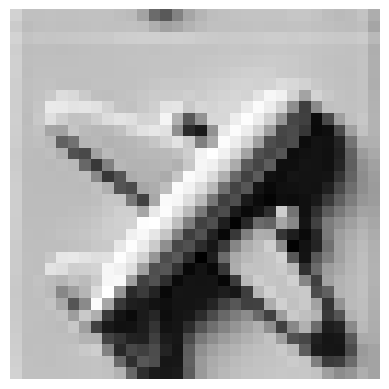

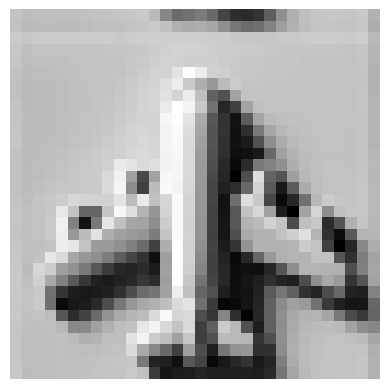

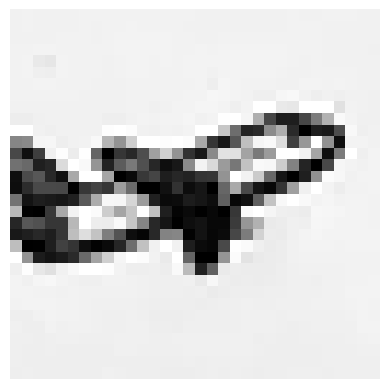

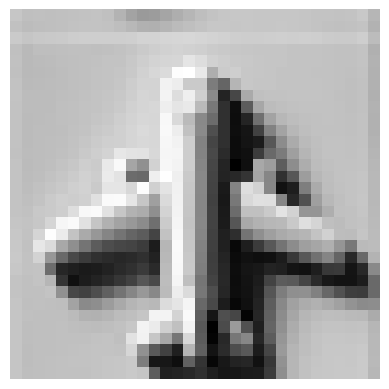

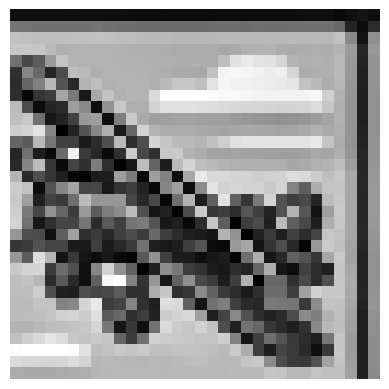

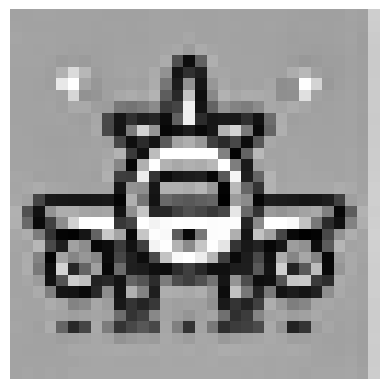

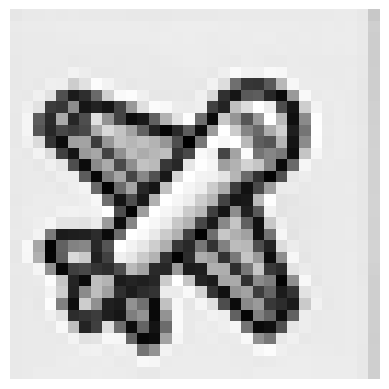

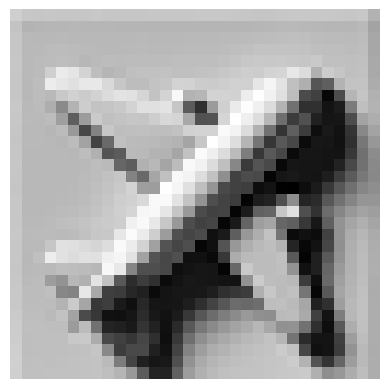

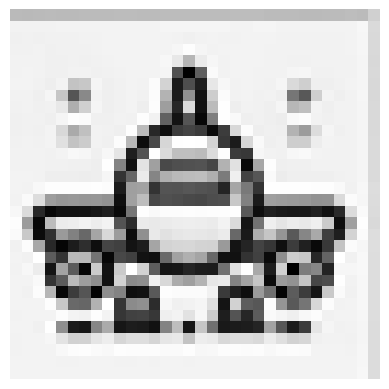

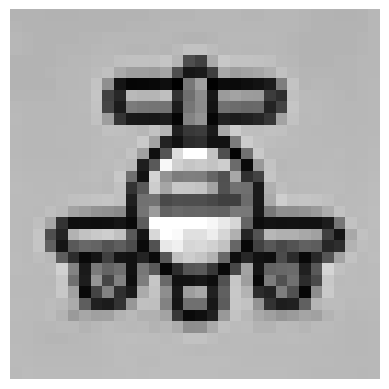

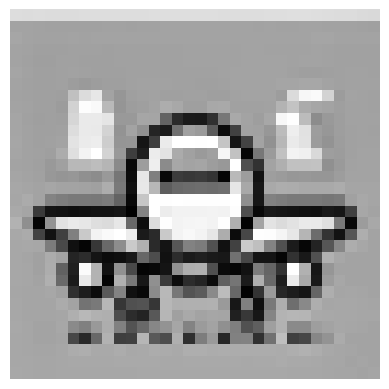

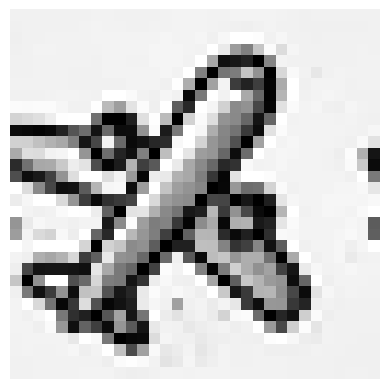

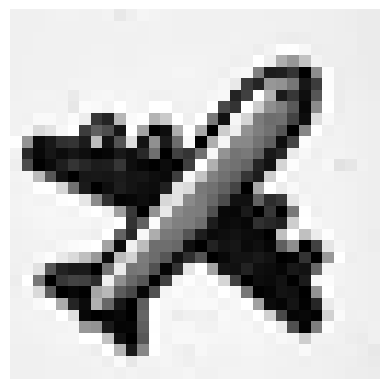

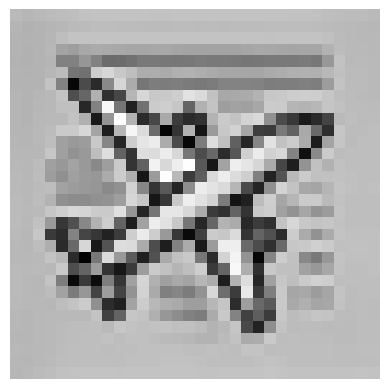

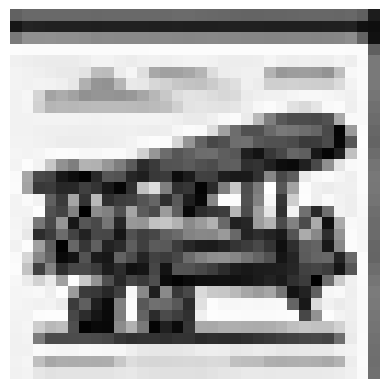

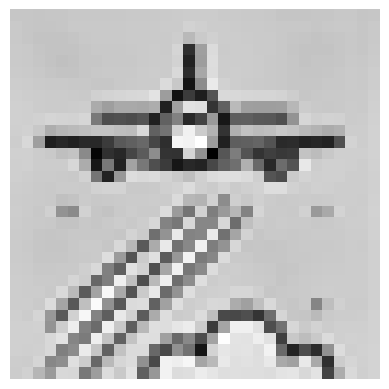

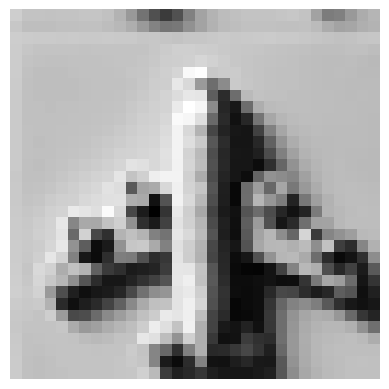

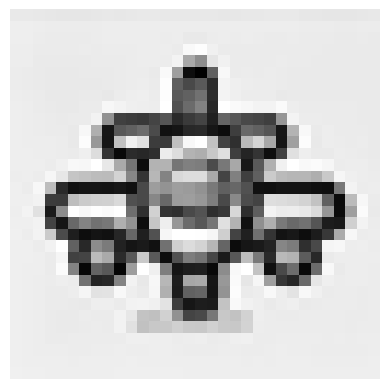

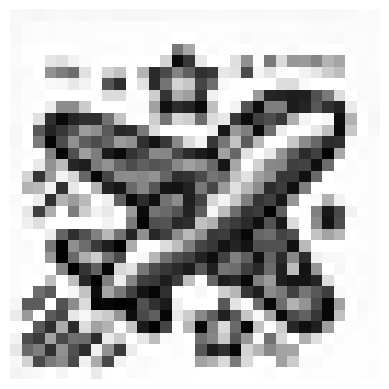

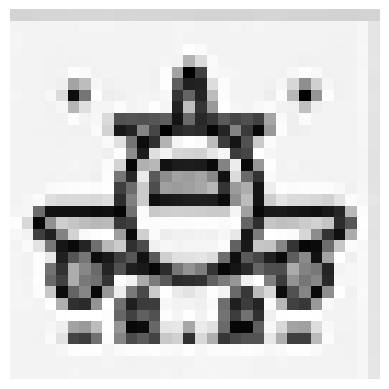

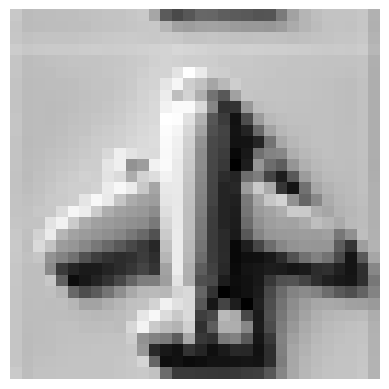

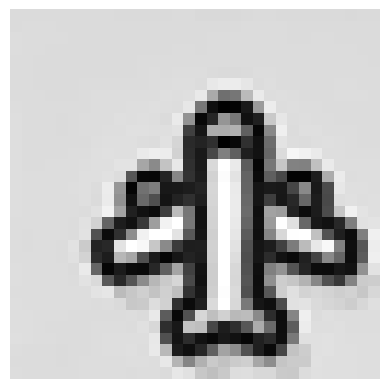

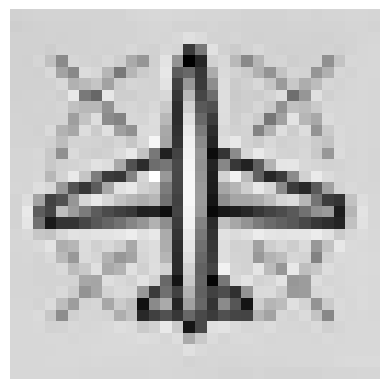

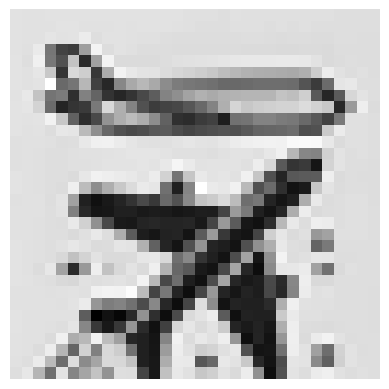

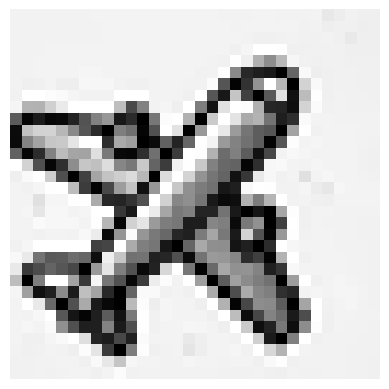

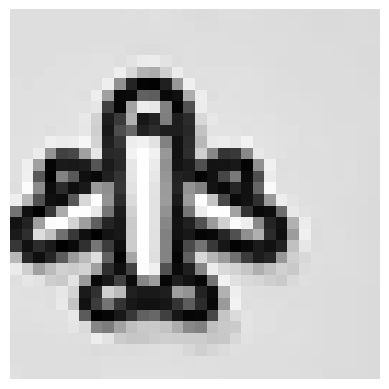

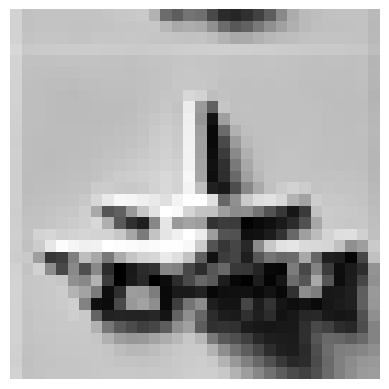

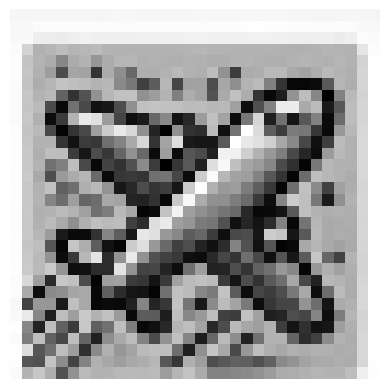

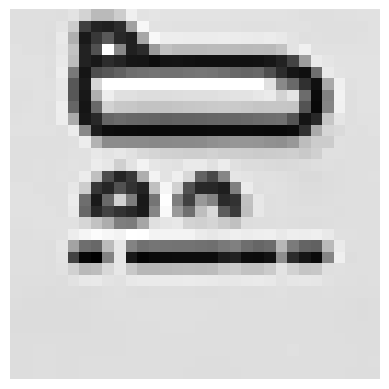

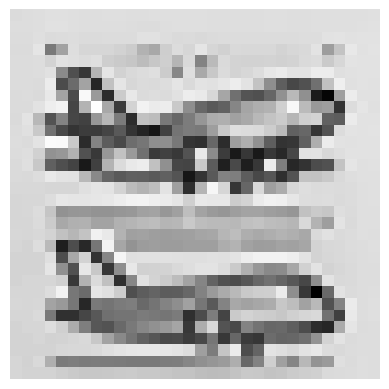

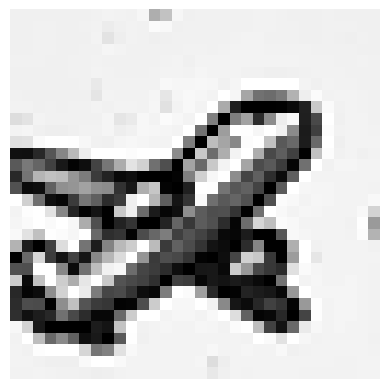

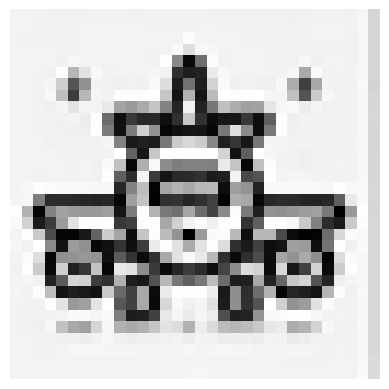

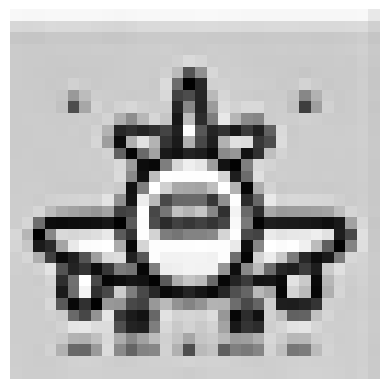

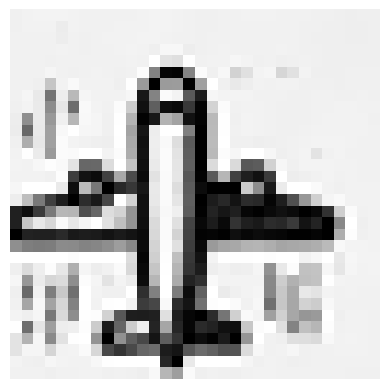

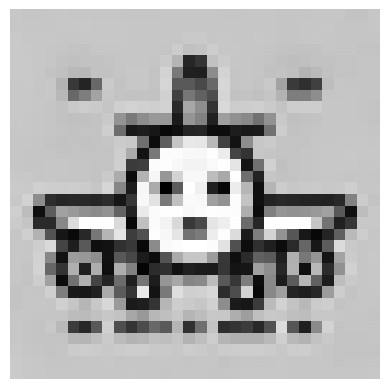

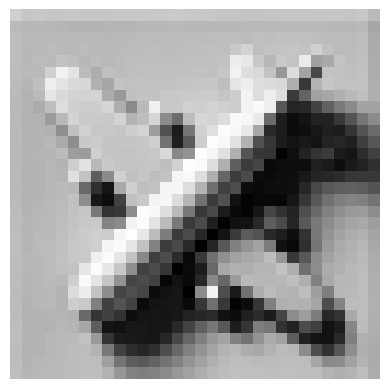

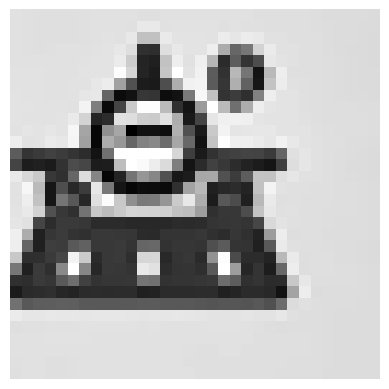

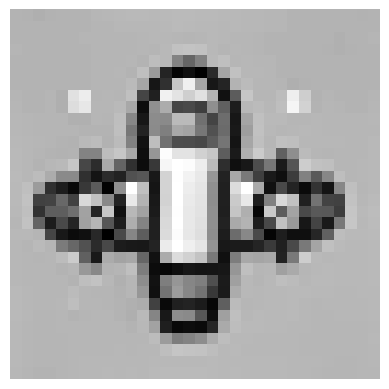

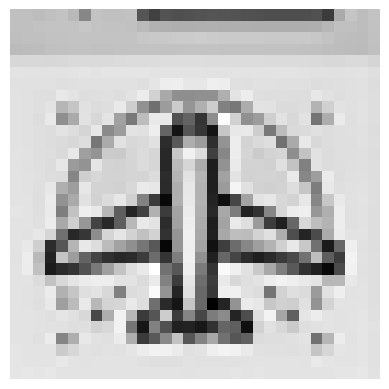

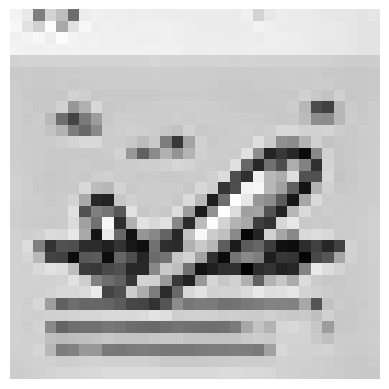

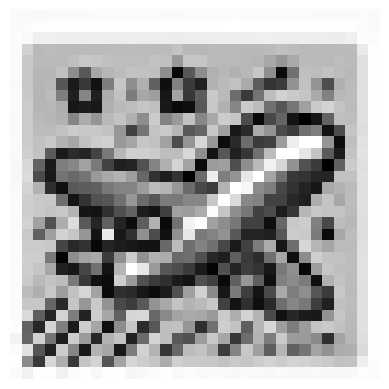

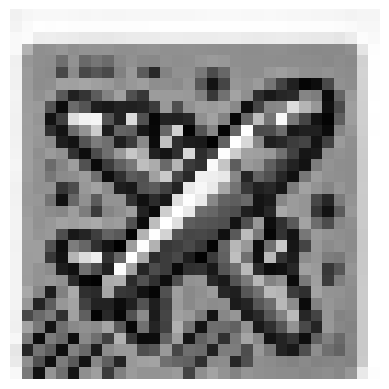

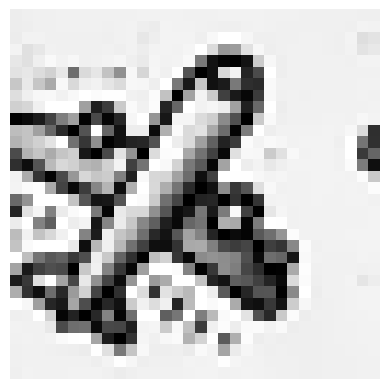

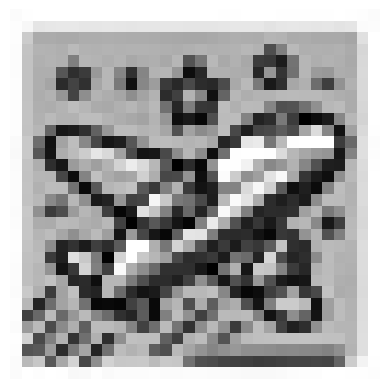

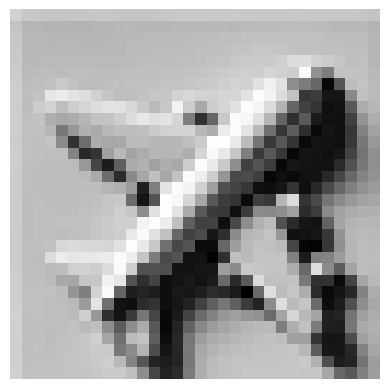

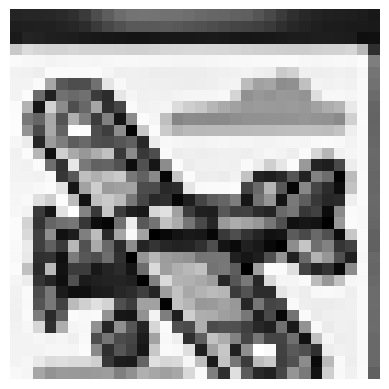

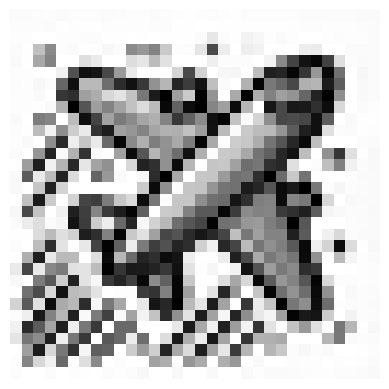

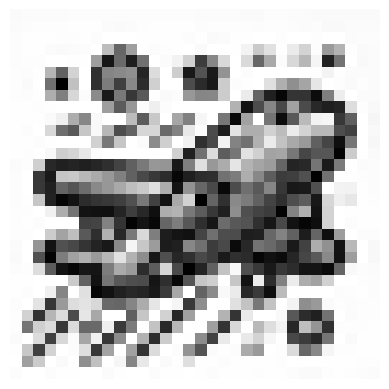

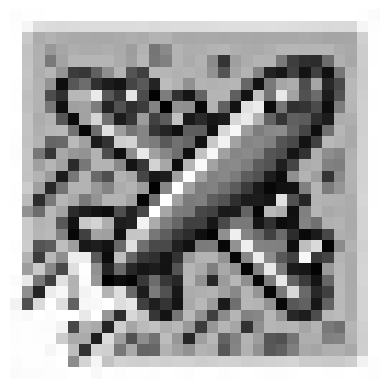

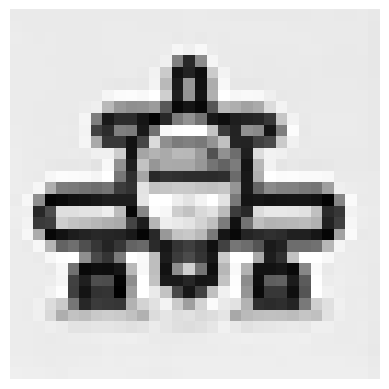

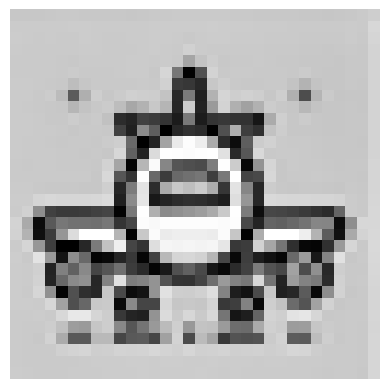

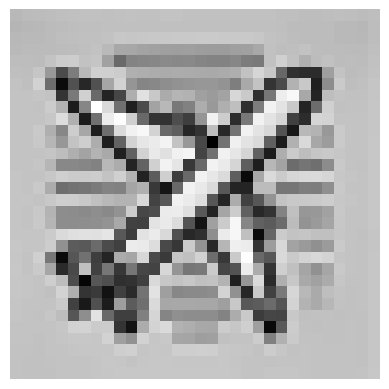

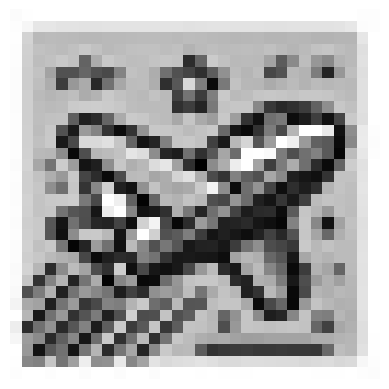

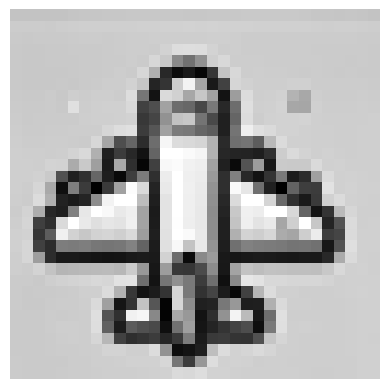

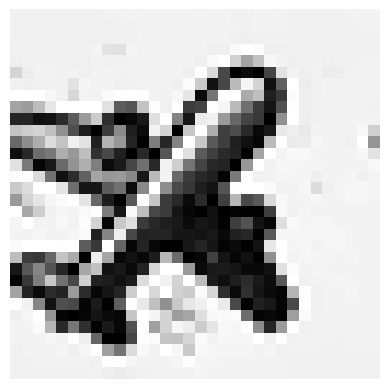

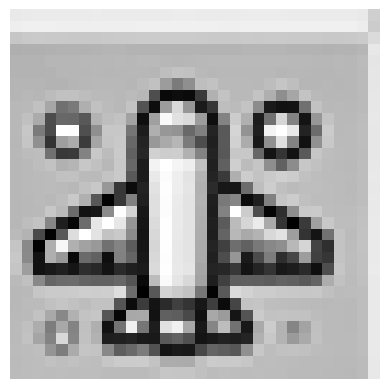

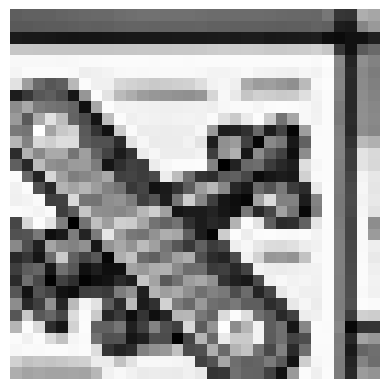

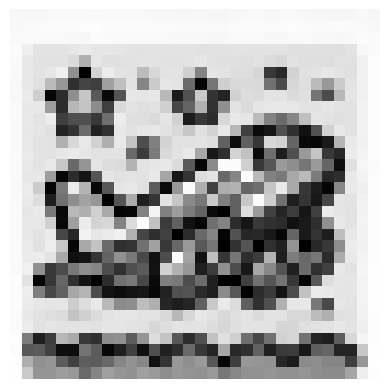

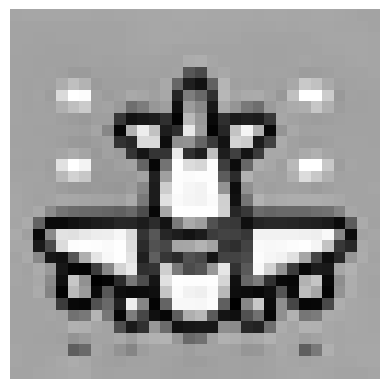

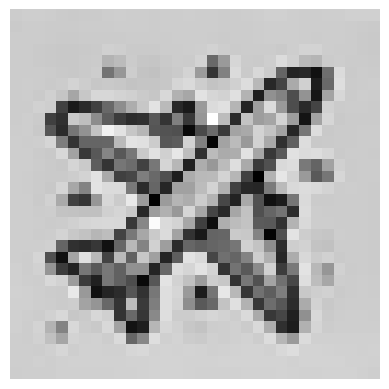

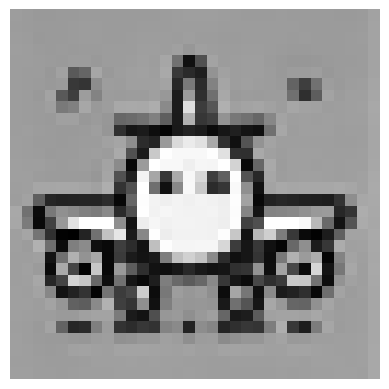

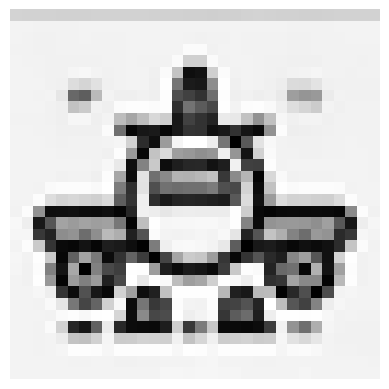

Label: emotion_face, Len: 88


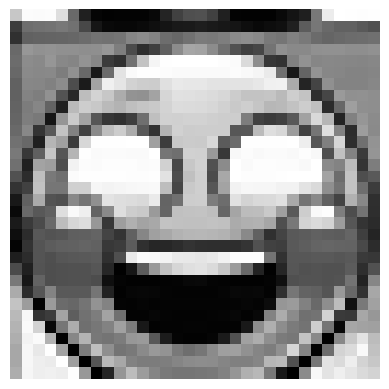

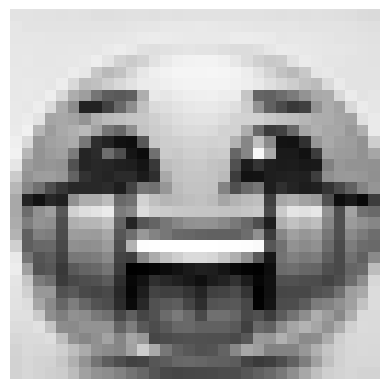

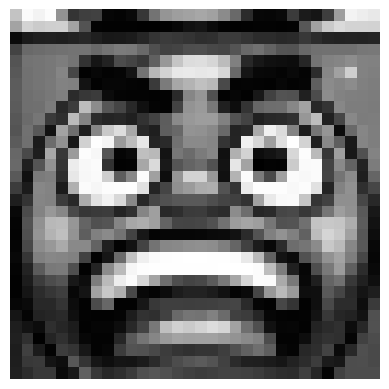

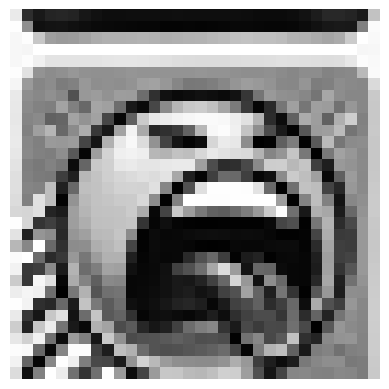

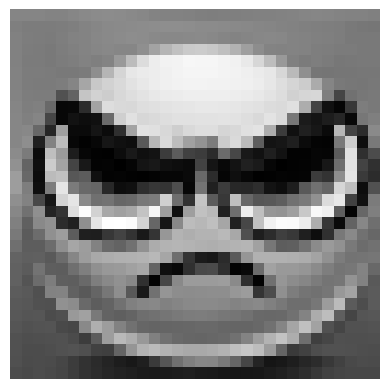

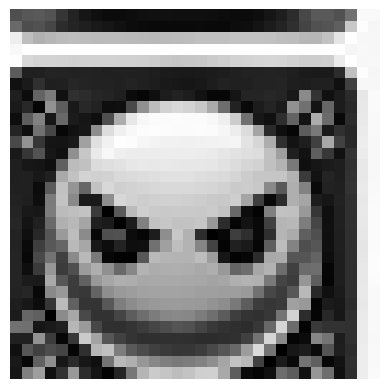

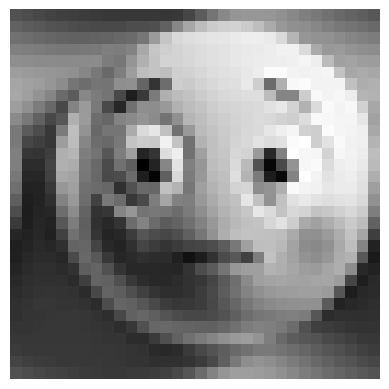

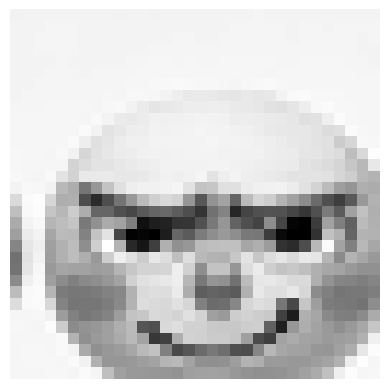

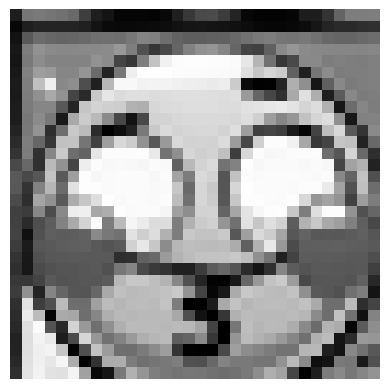

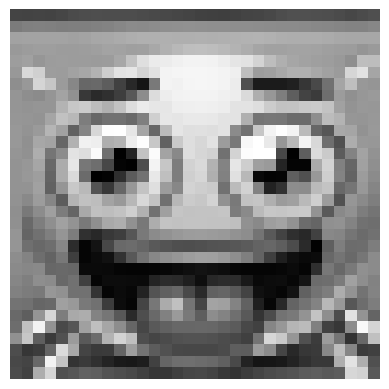

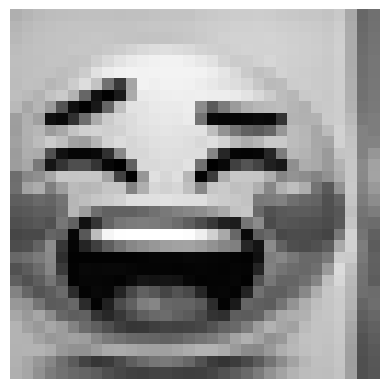

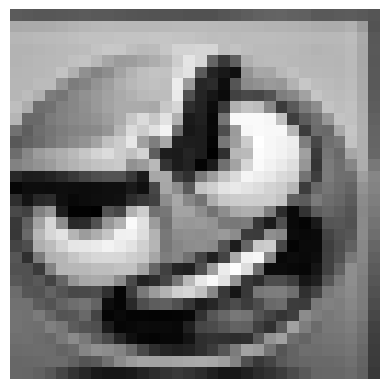

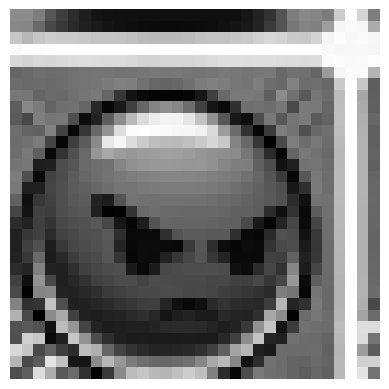

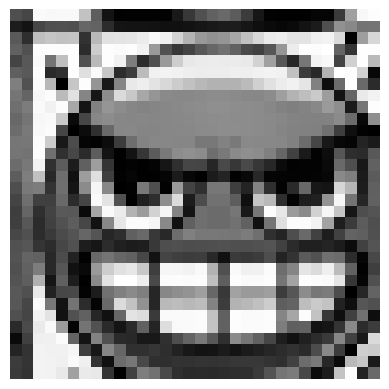

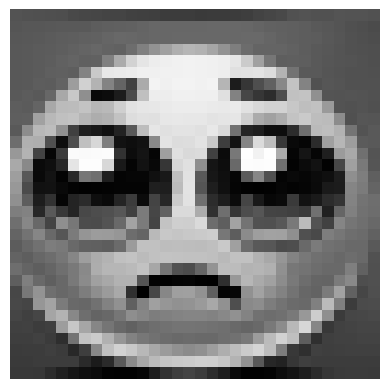

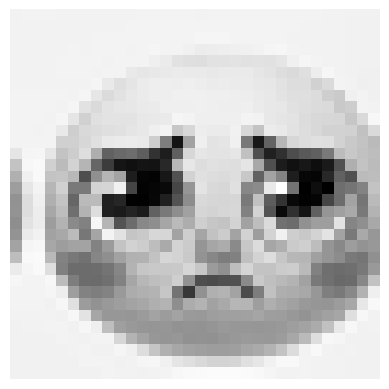

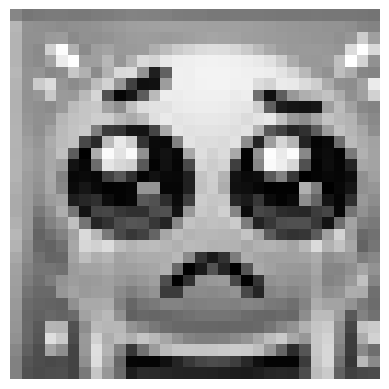

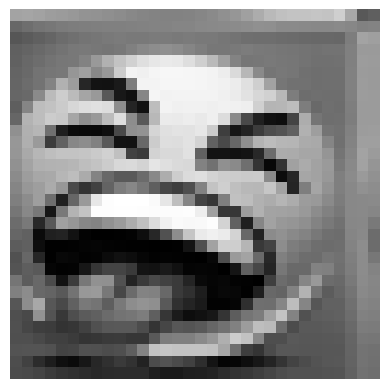

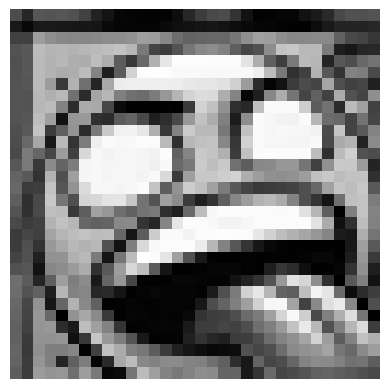

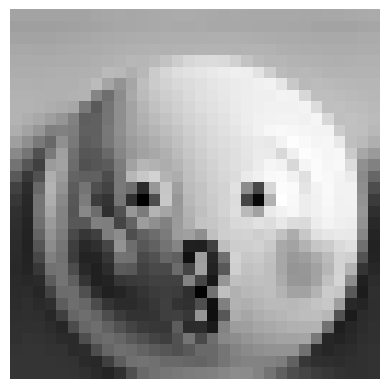

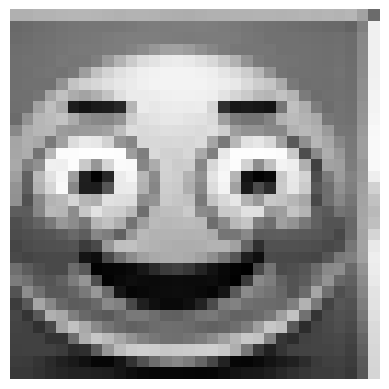

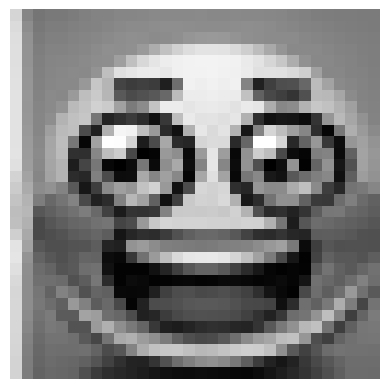

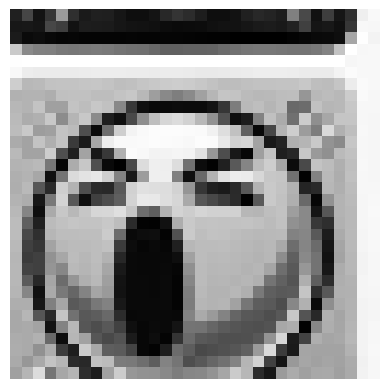

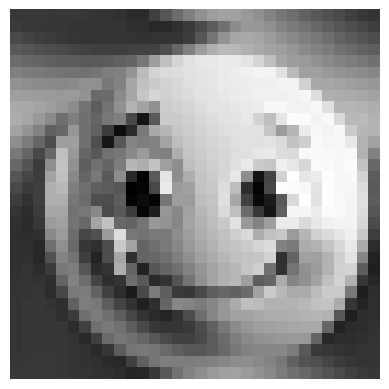

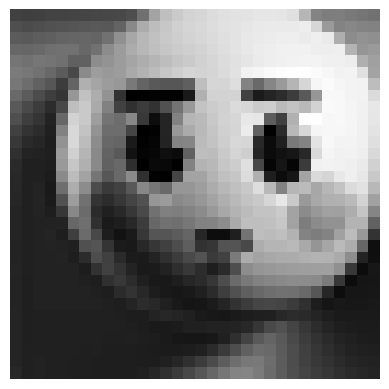

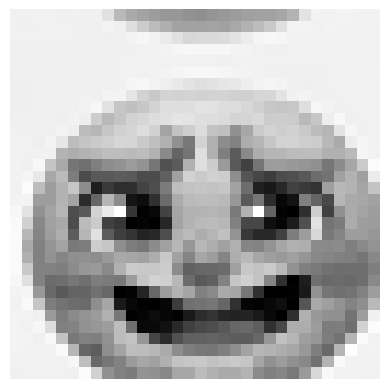

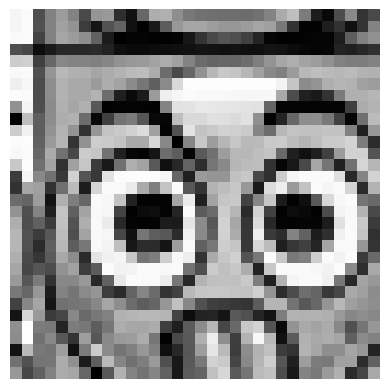

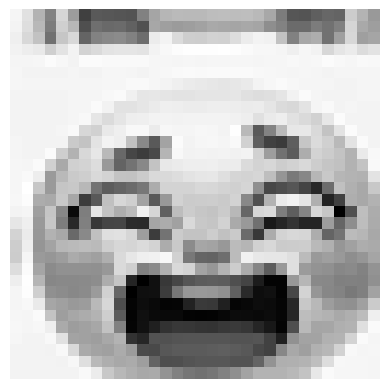

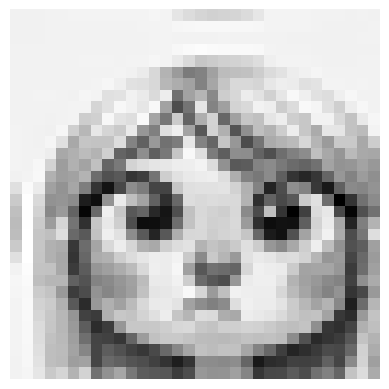

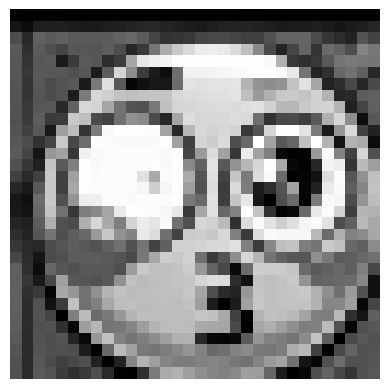

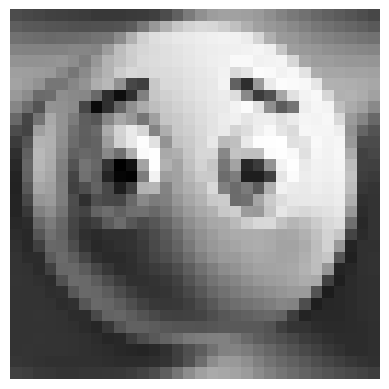

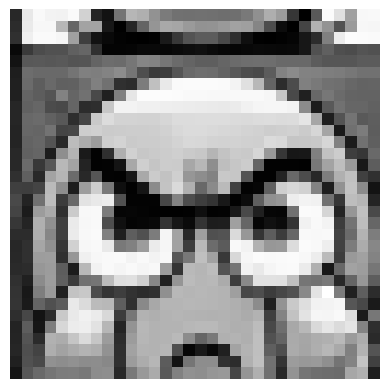

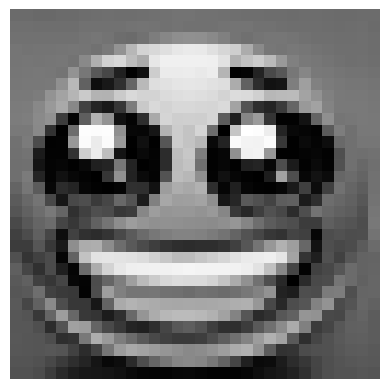

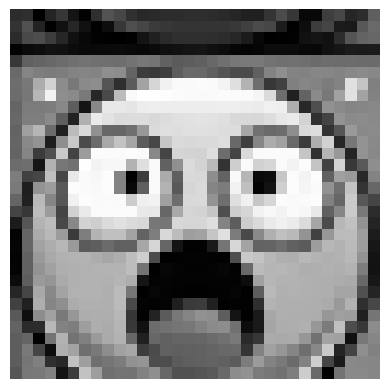

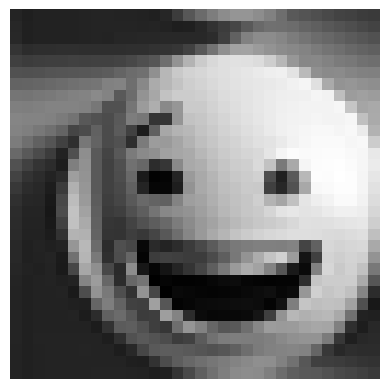

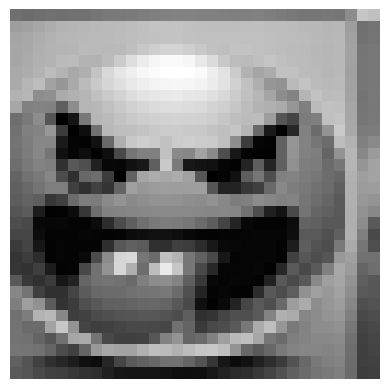

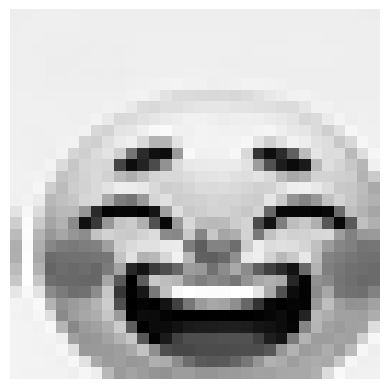

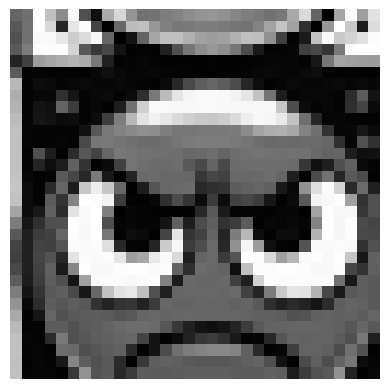

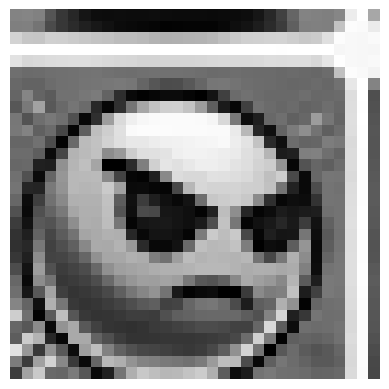

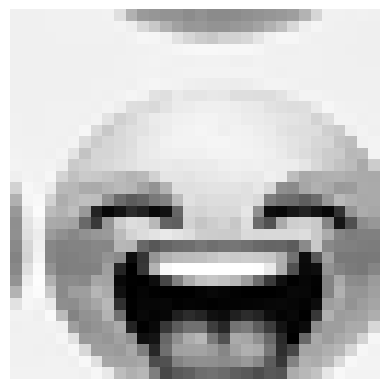

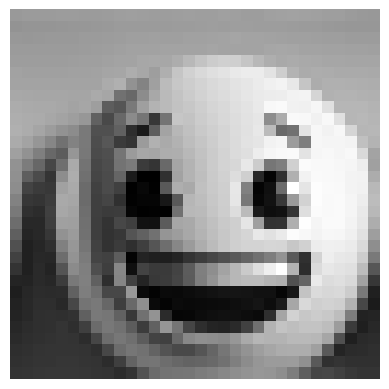

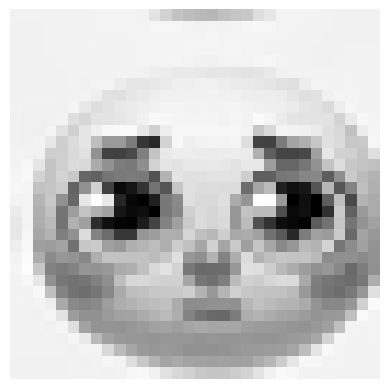

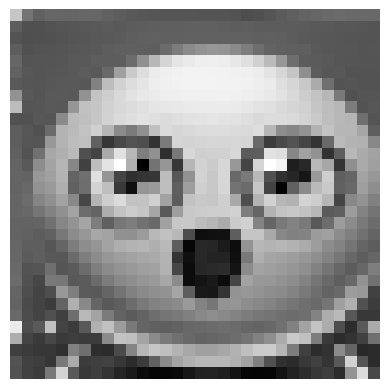

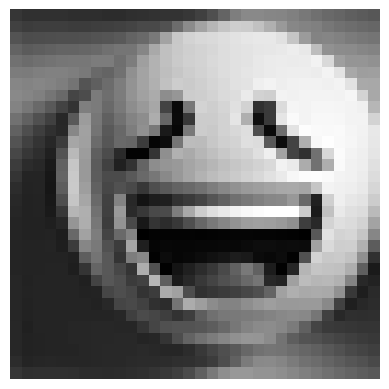

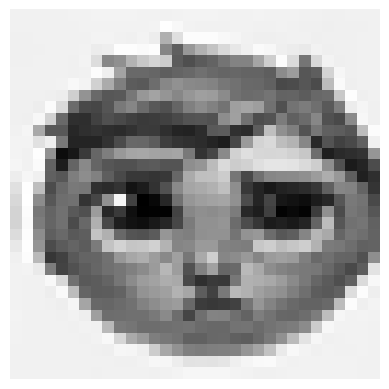

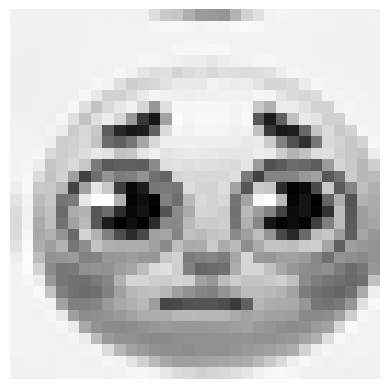

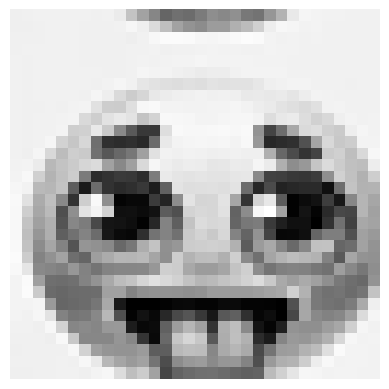

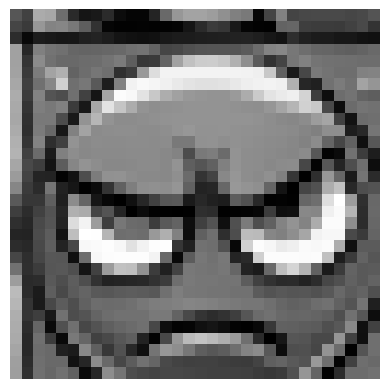

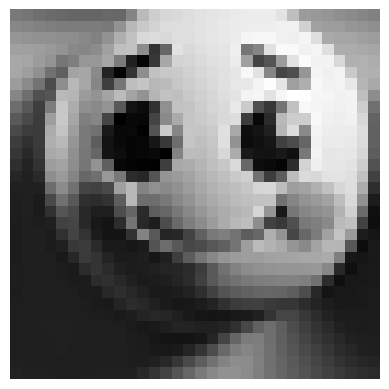

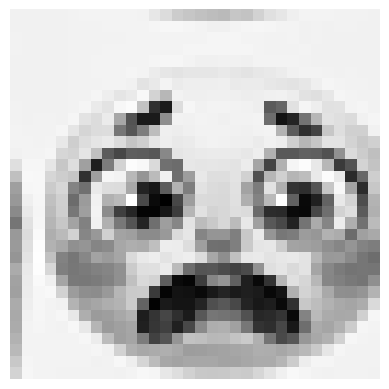

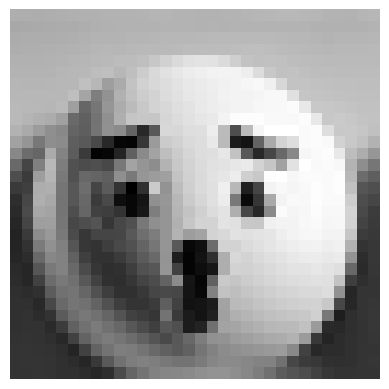

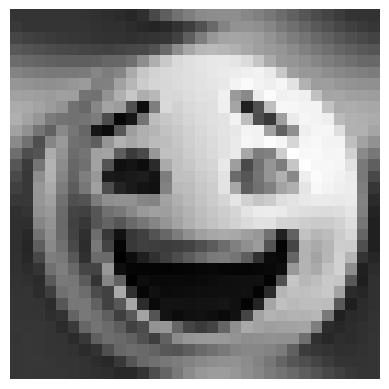

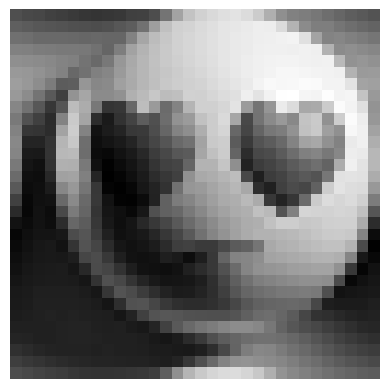

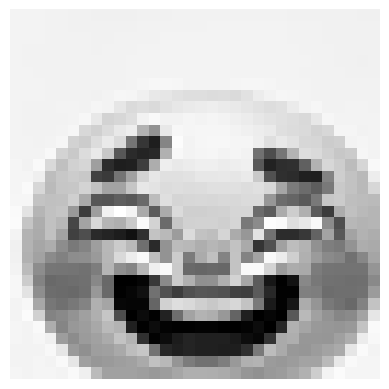

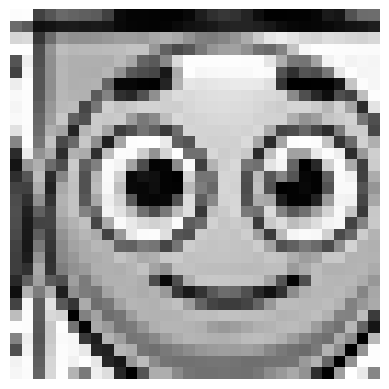

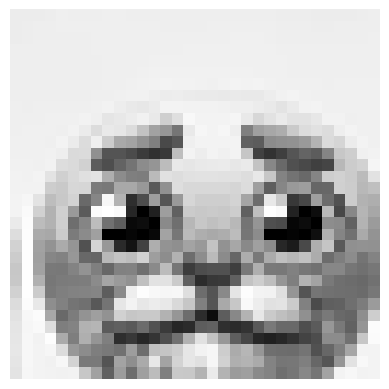

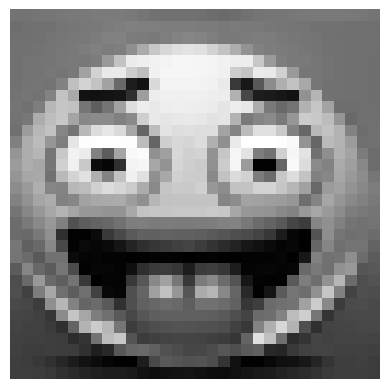

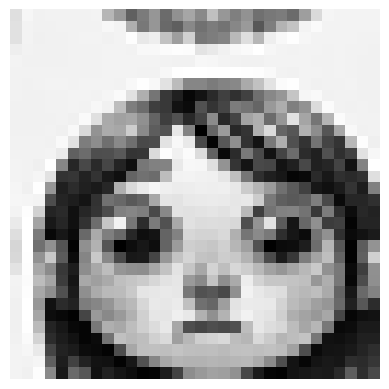

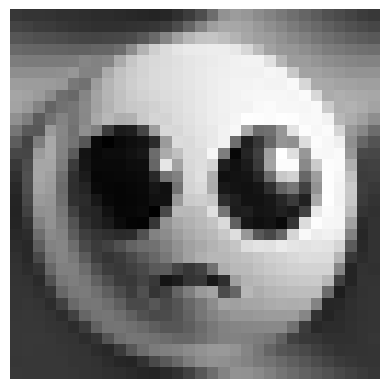

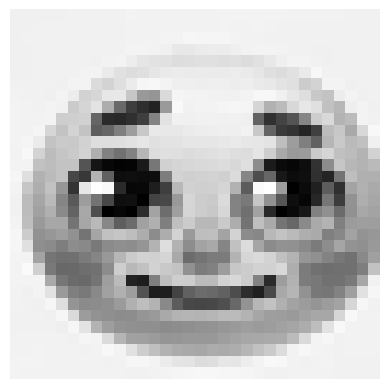

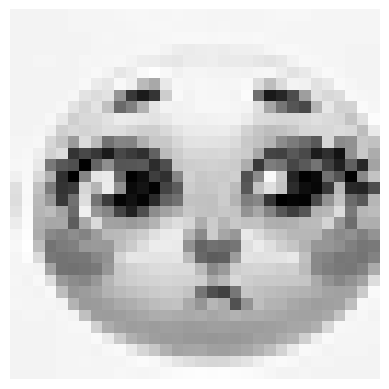

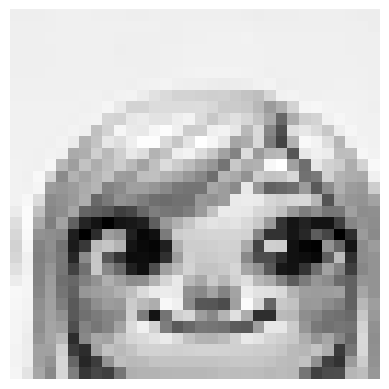

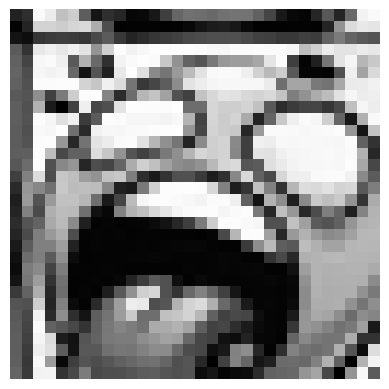

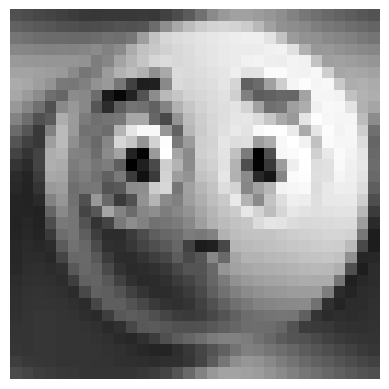

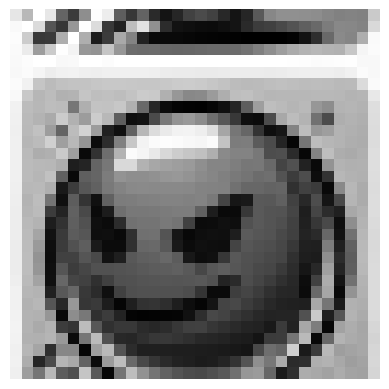

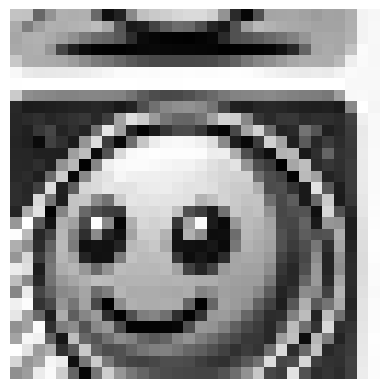

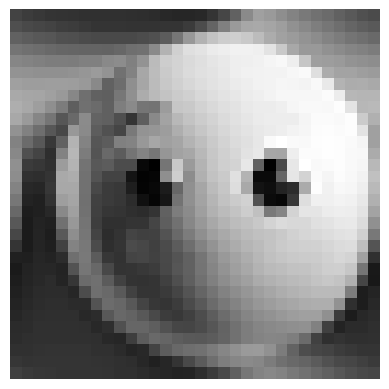

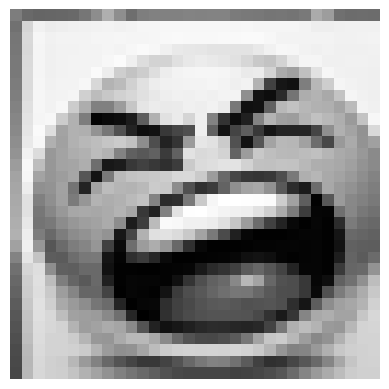

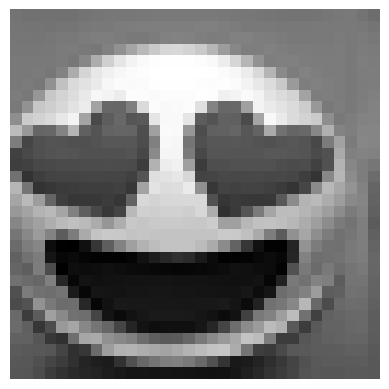

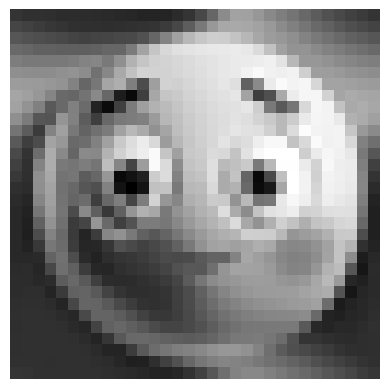

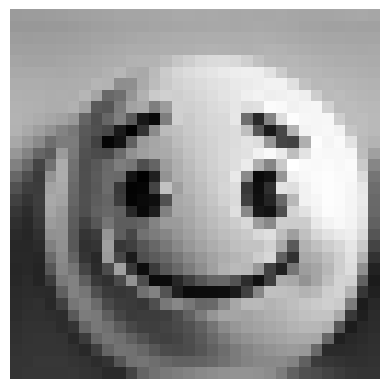

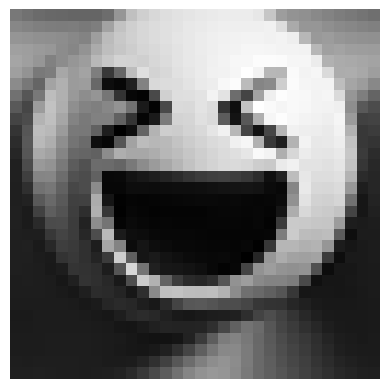

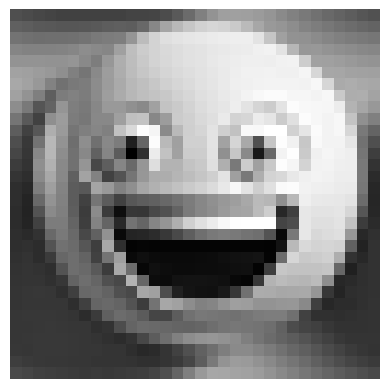

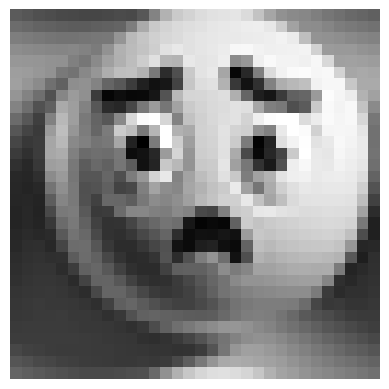

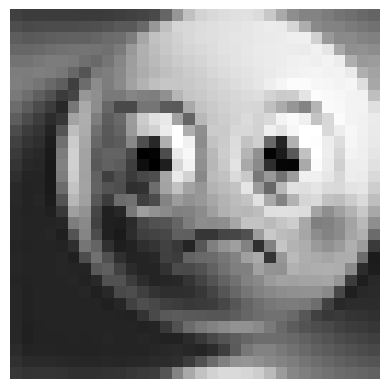

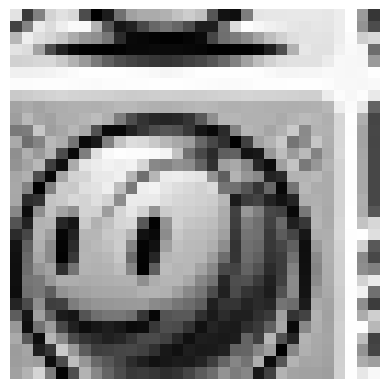

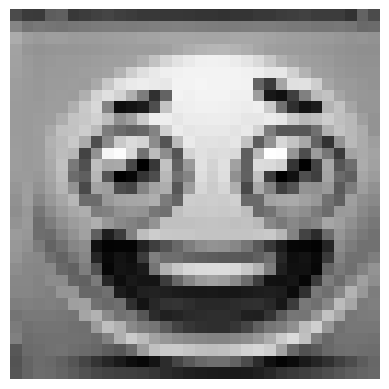

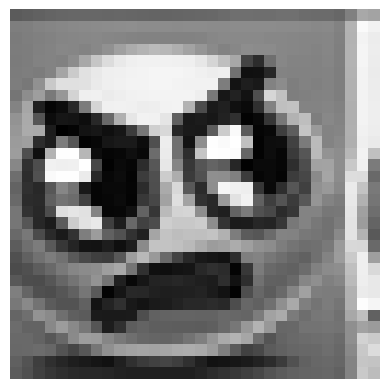

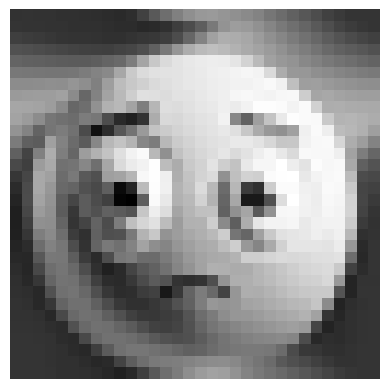

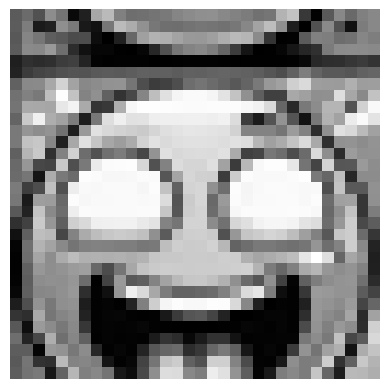

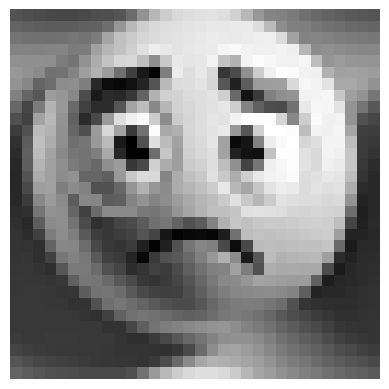

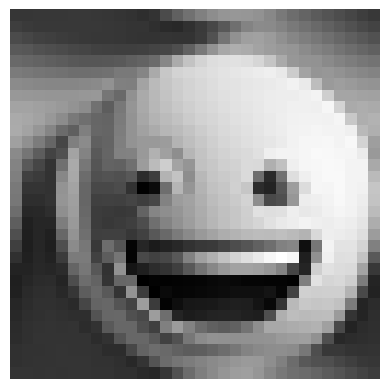

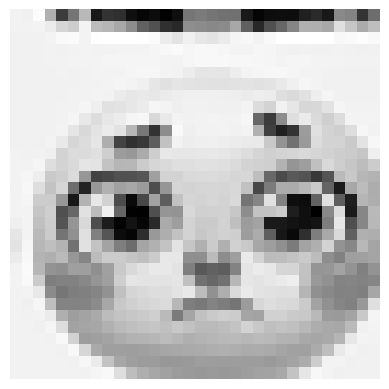

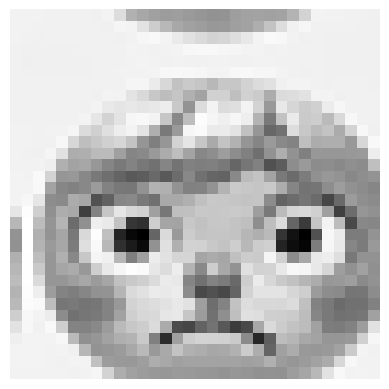

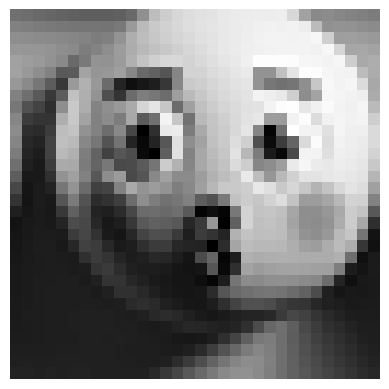

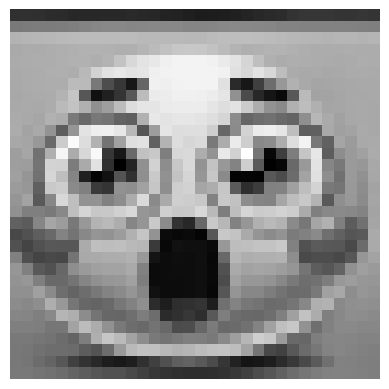

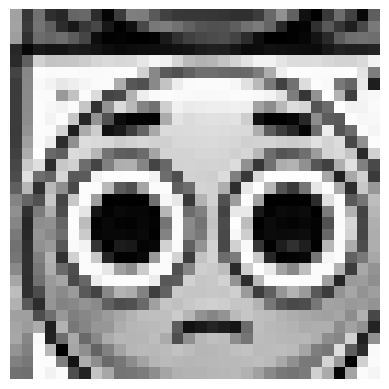

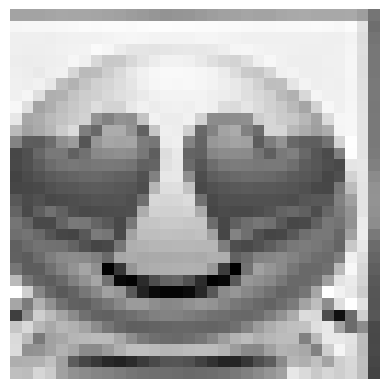

Label: rabbit, Len: 128


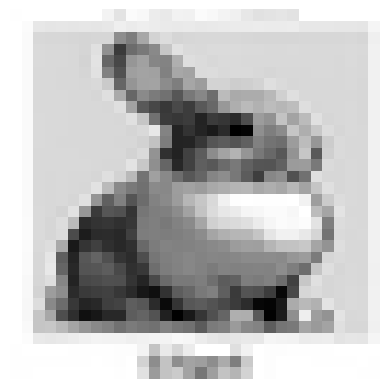

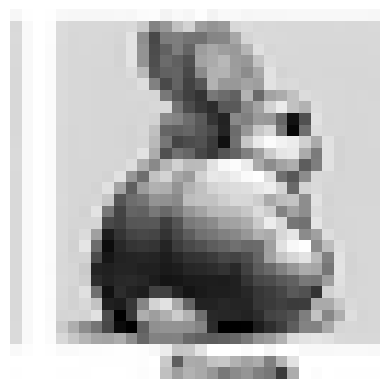

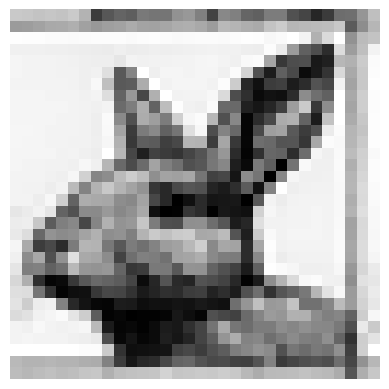

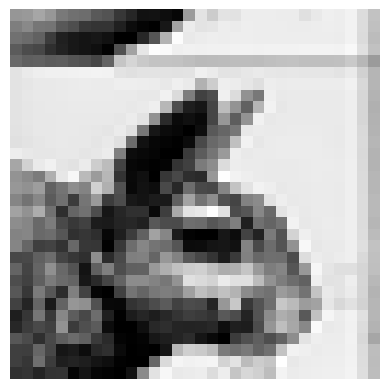

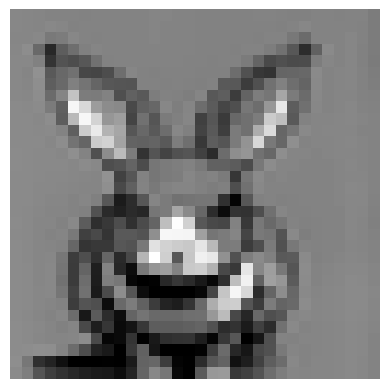

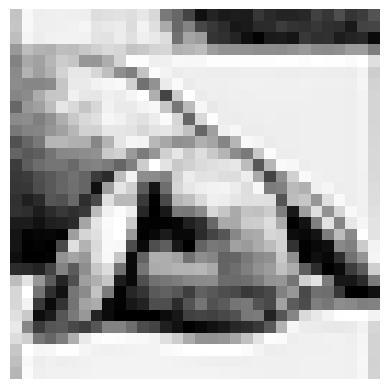

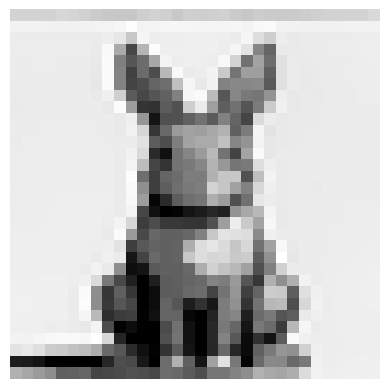

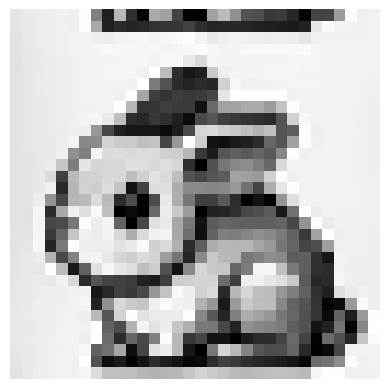

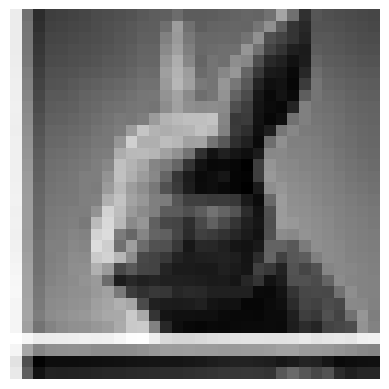

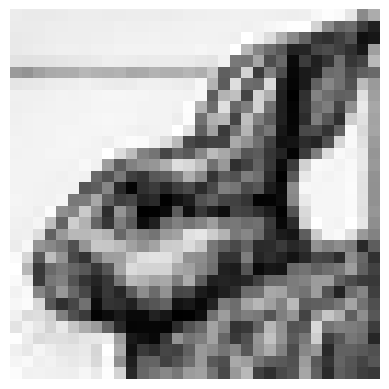

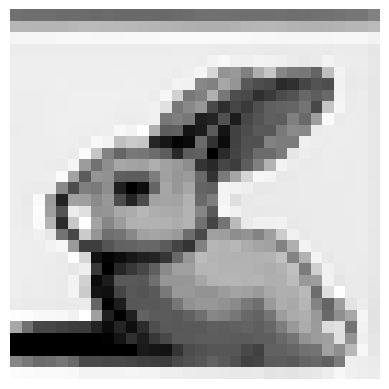

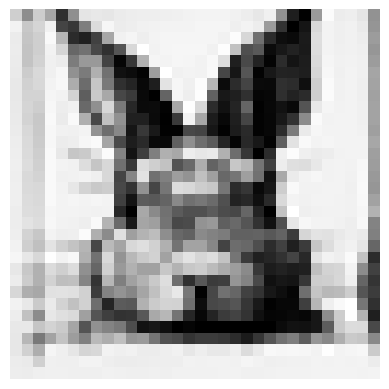

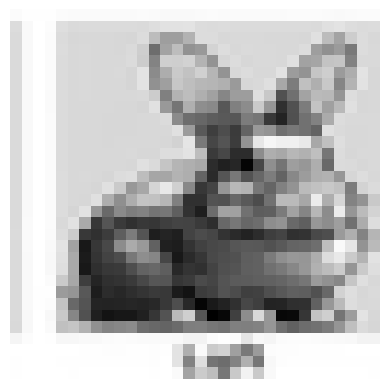

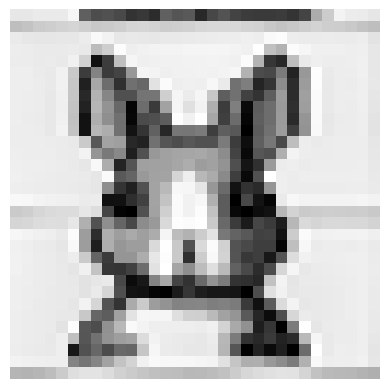

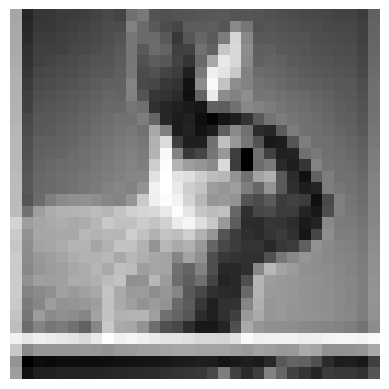

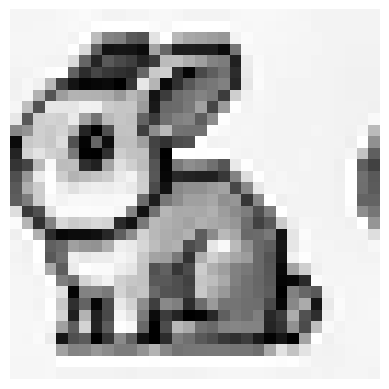

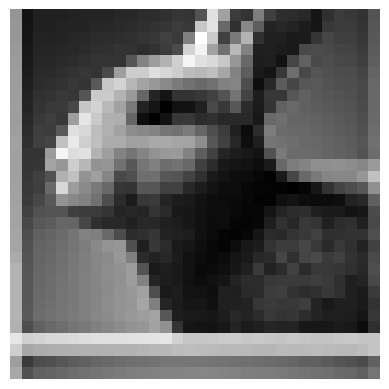

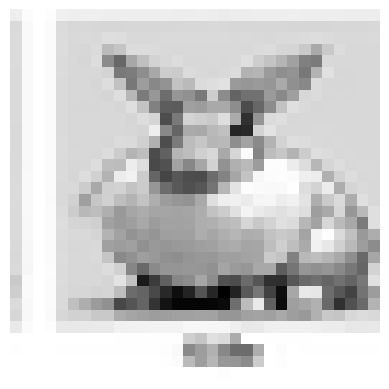

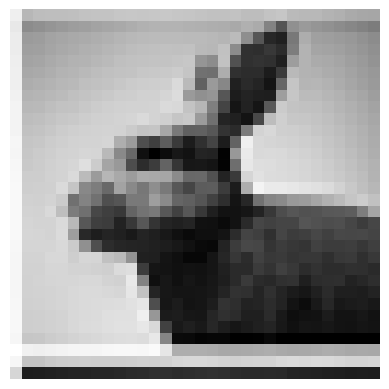

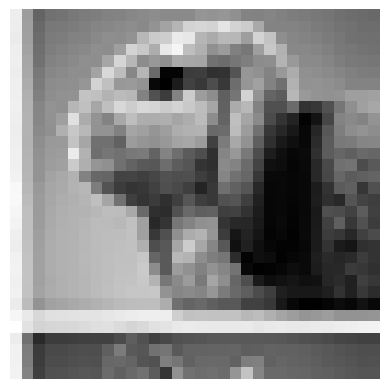

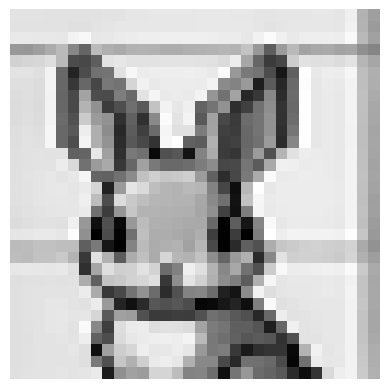

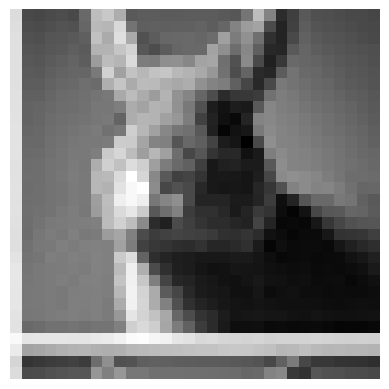

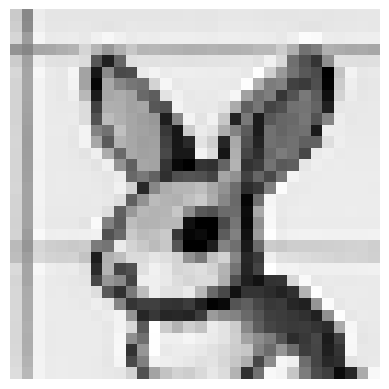

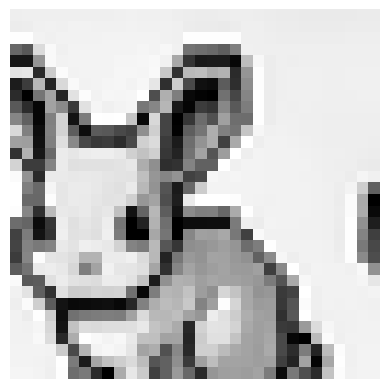

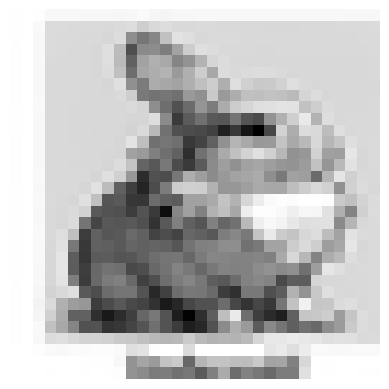

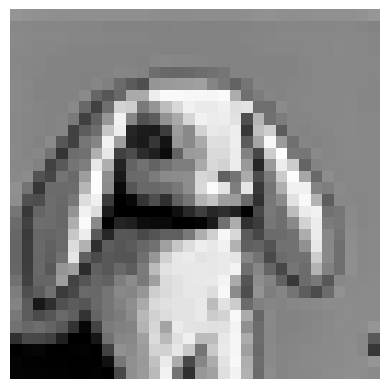

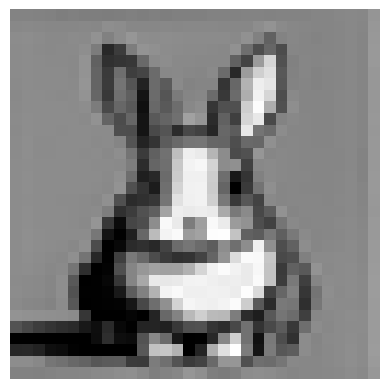

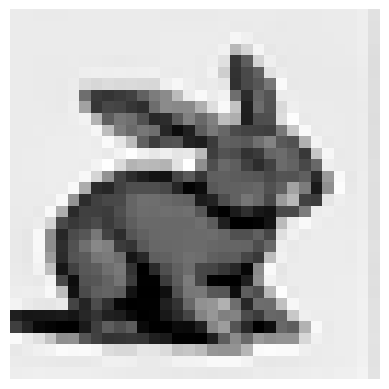

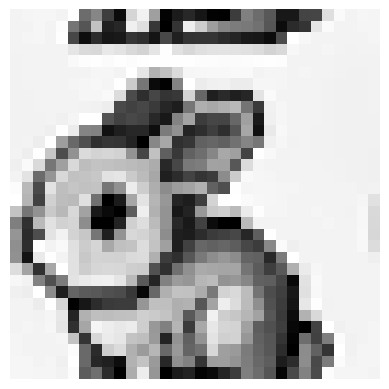

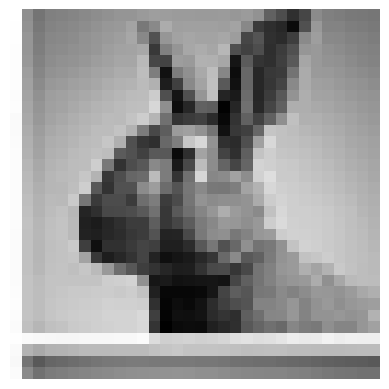

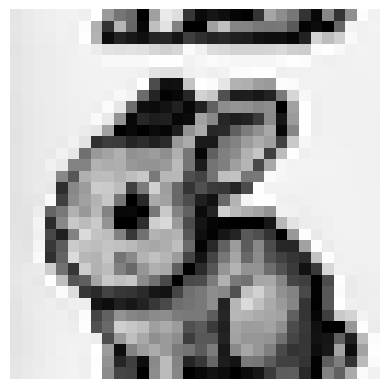

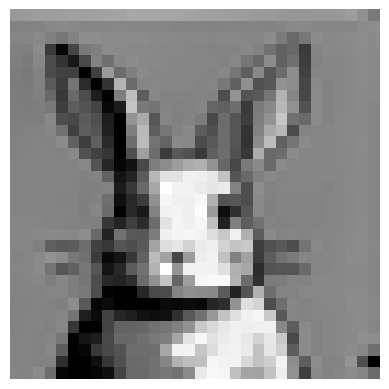

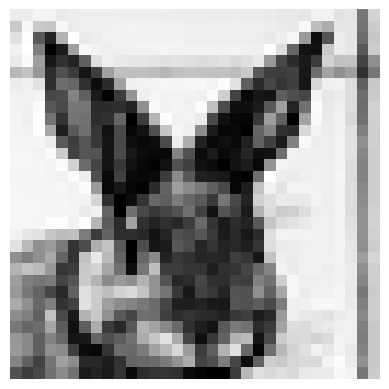

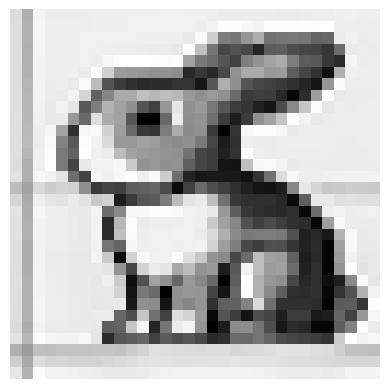

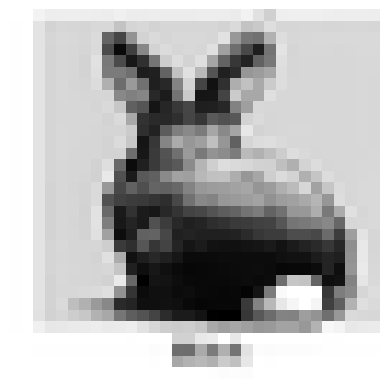

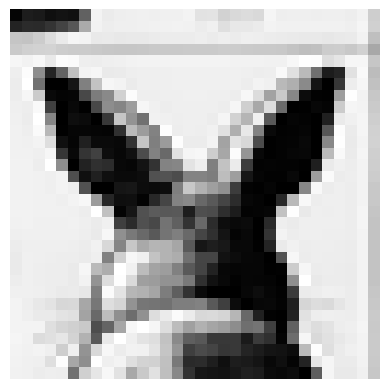

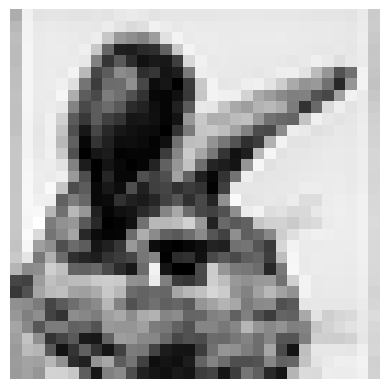

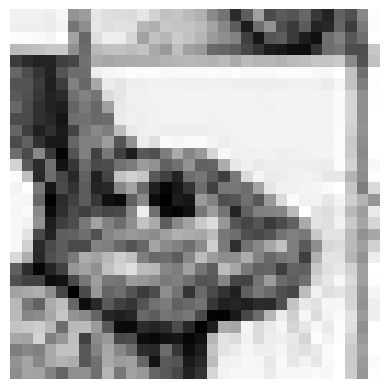

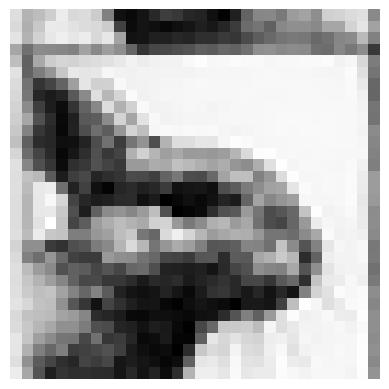

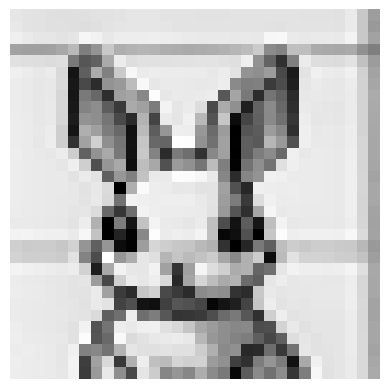

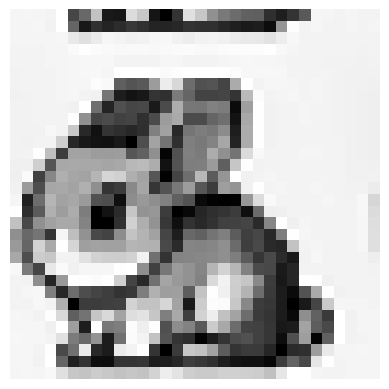

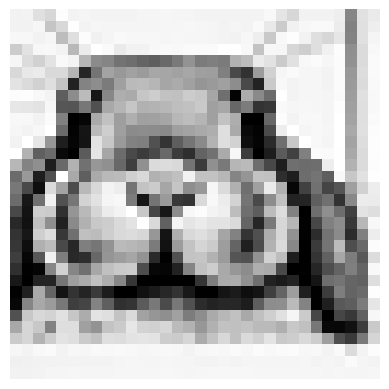

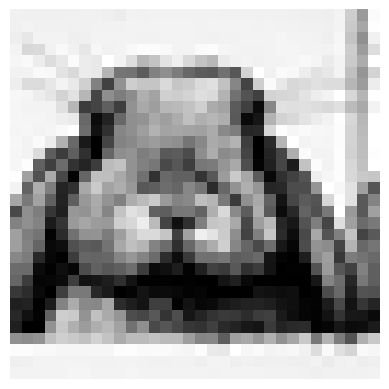

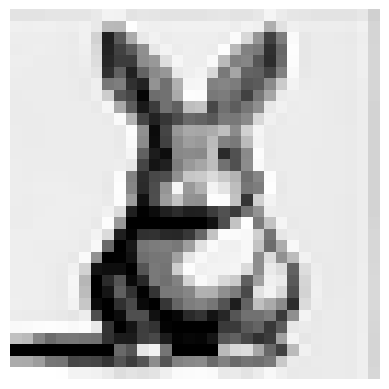

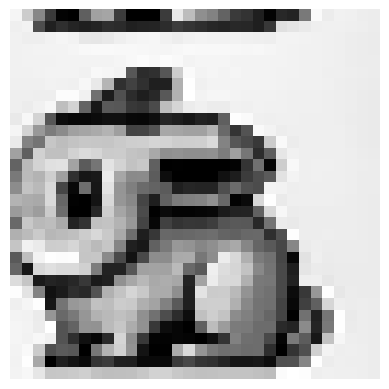

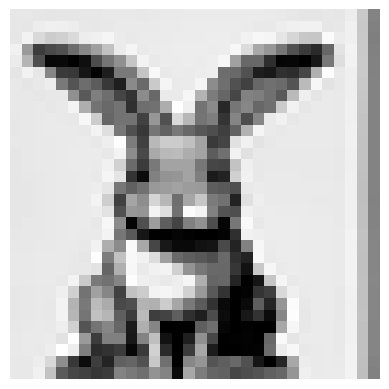

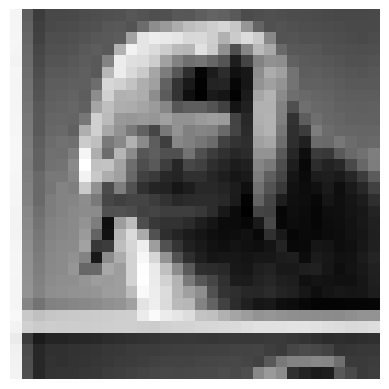

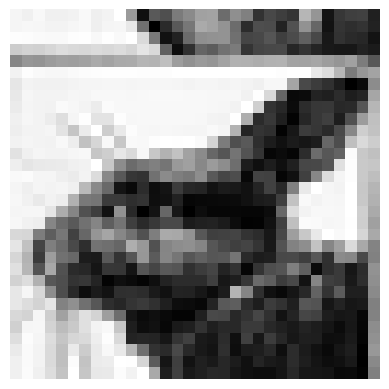

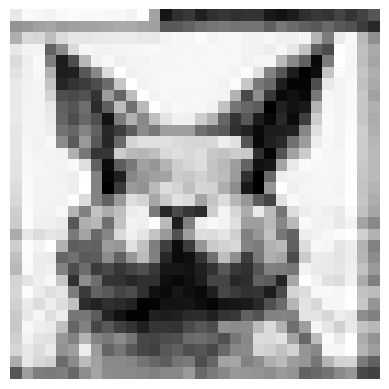

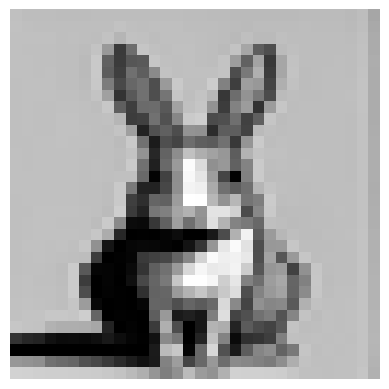

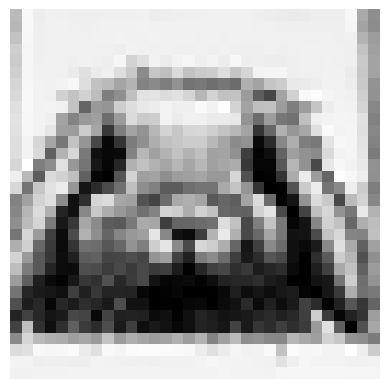

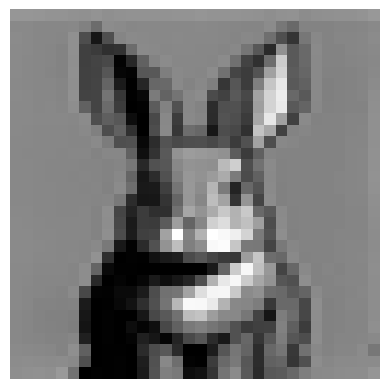

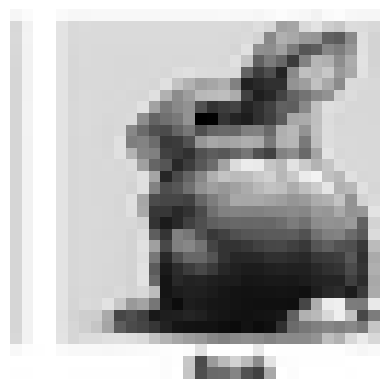

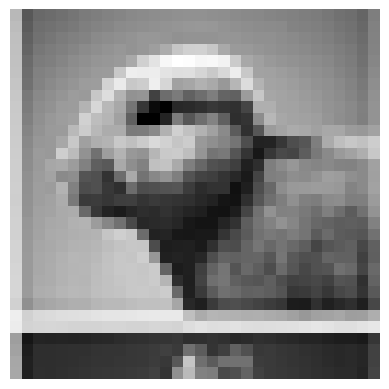

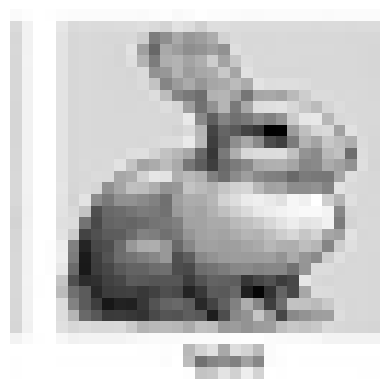

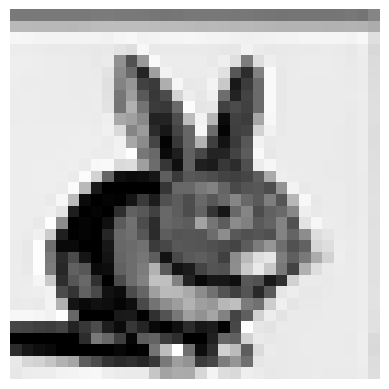

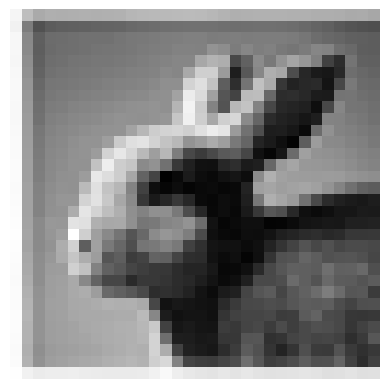

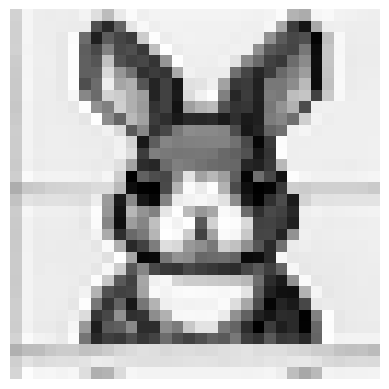

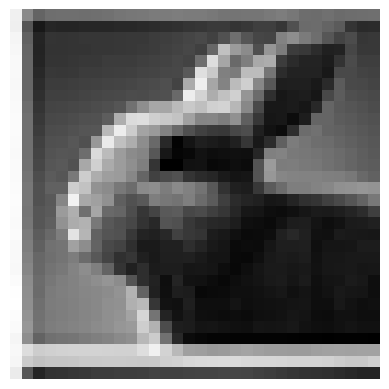

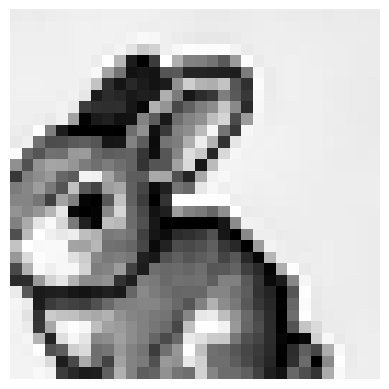

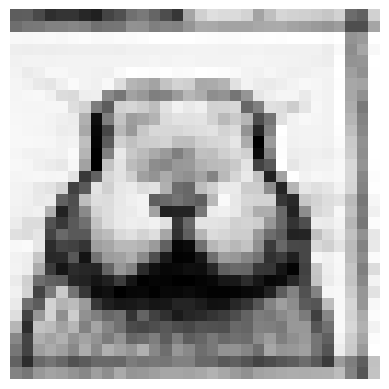

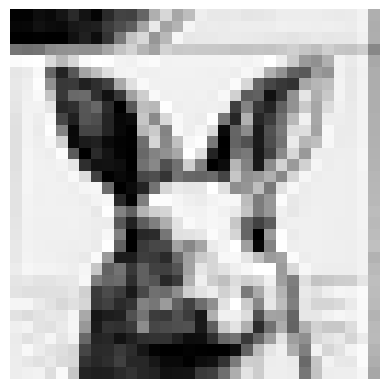

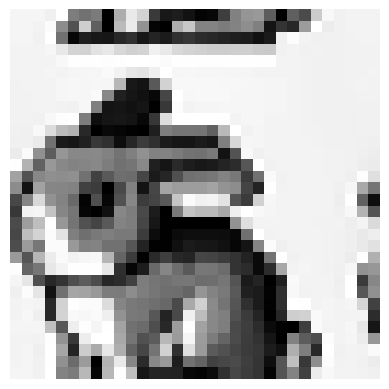

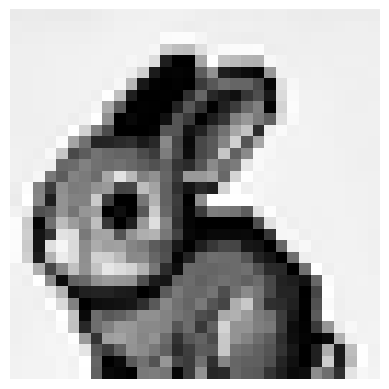

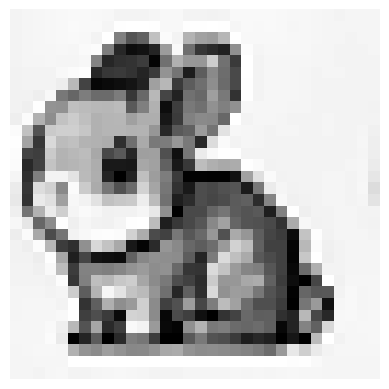

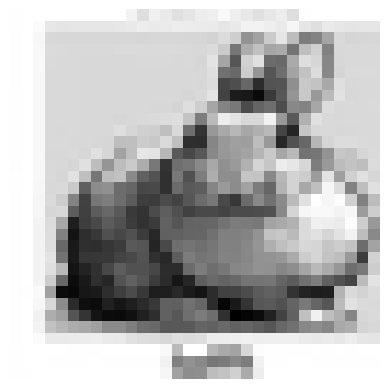

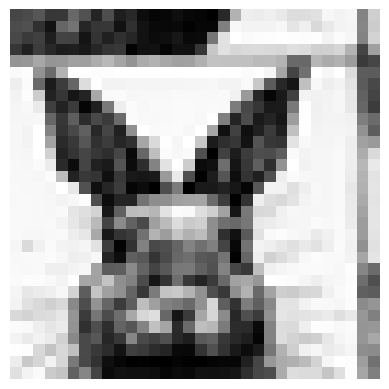

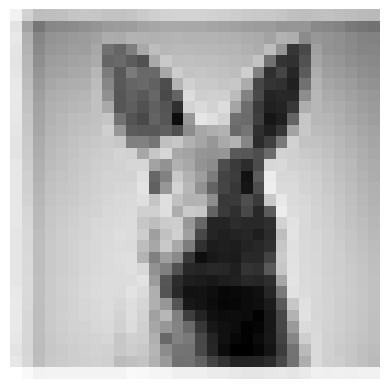

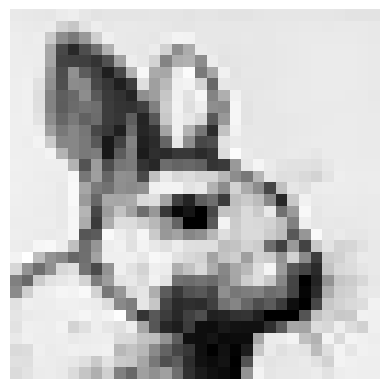

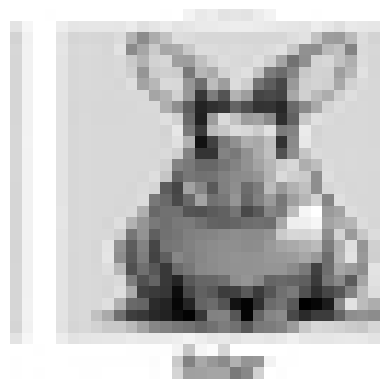

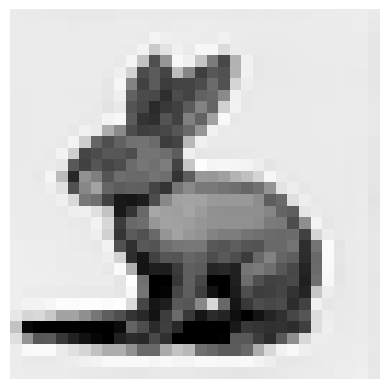

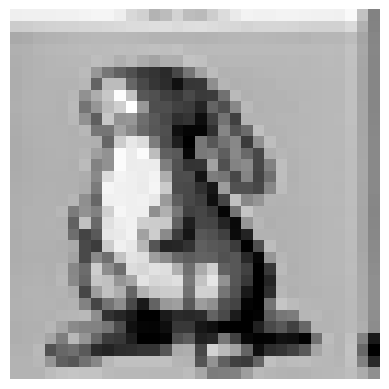

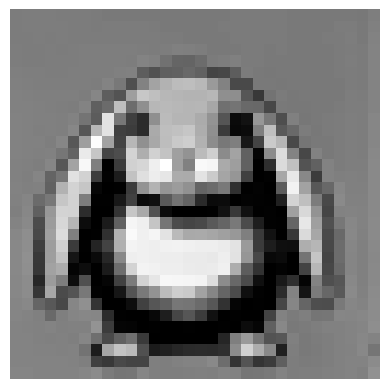

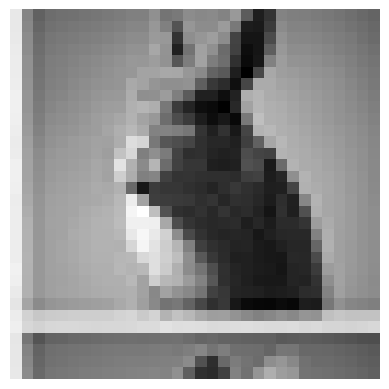

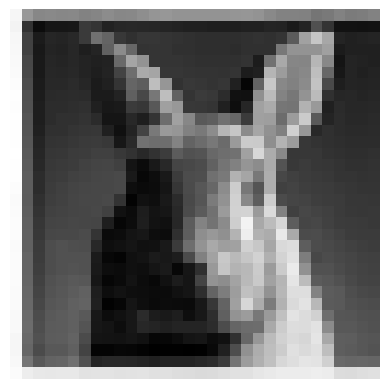

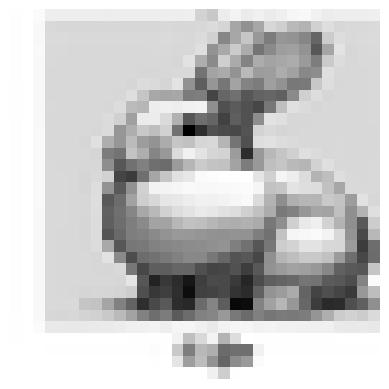

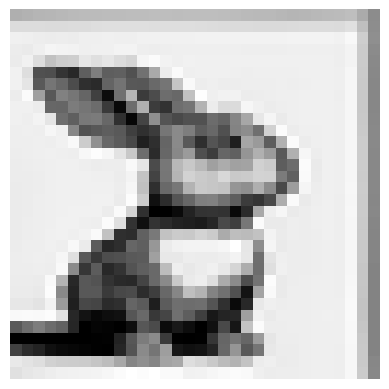

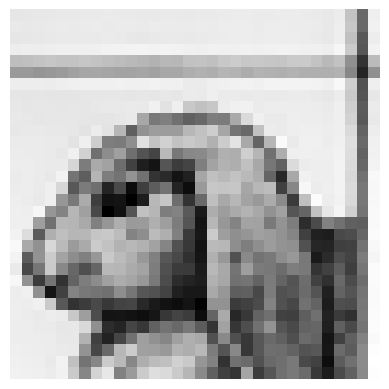

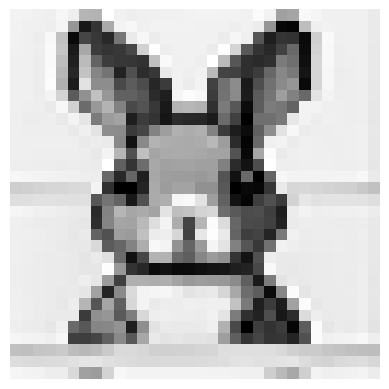

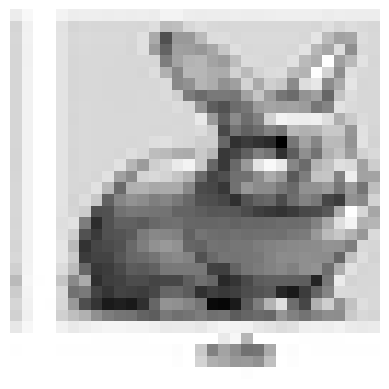

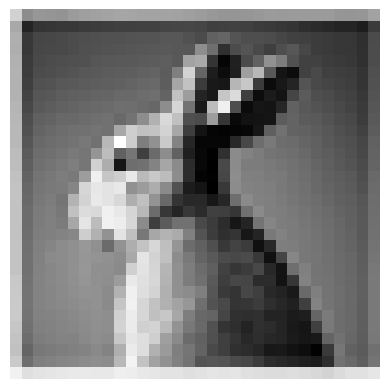

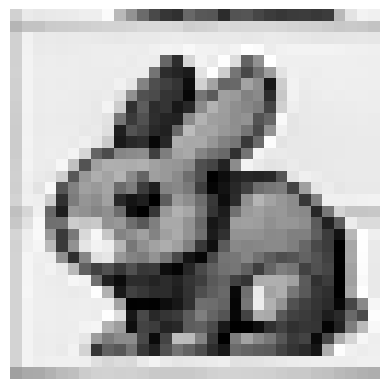

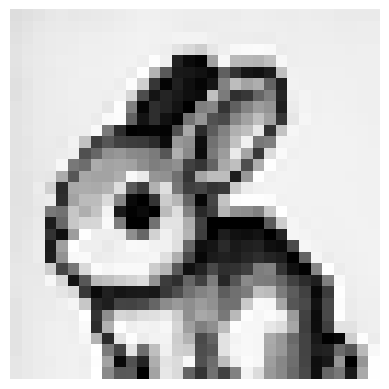

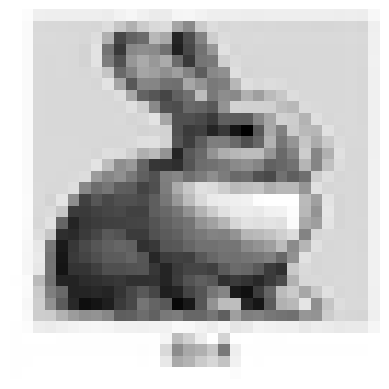

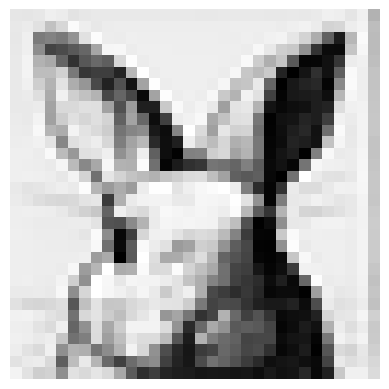

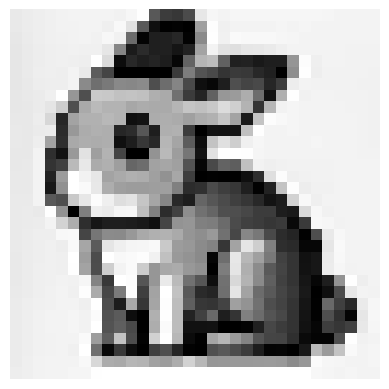

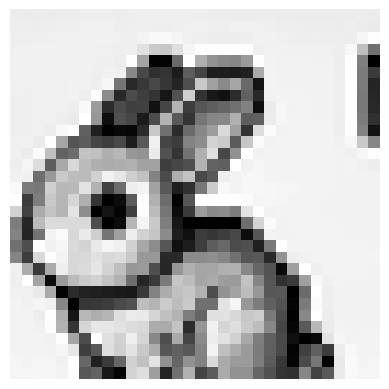

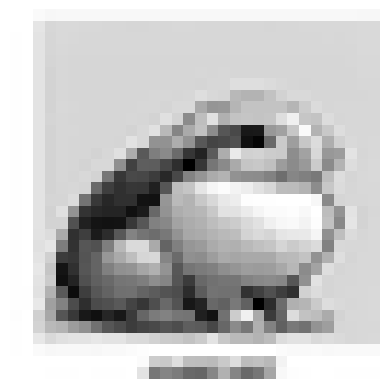

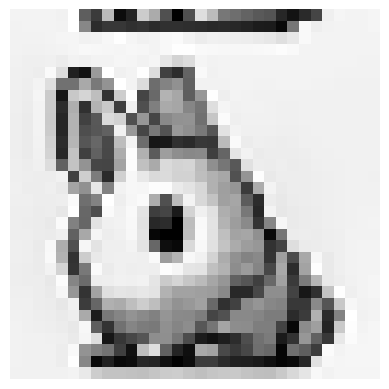

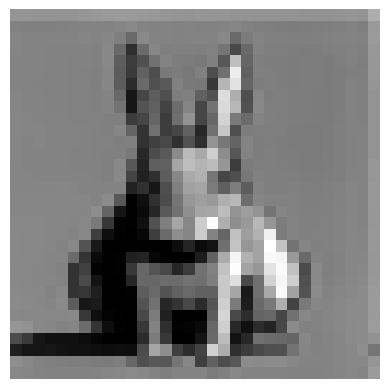

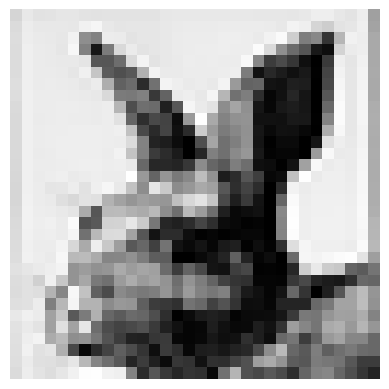

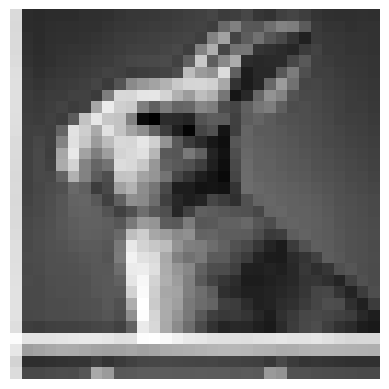

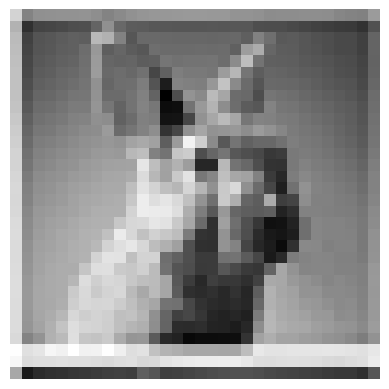

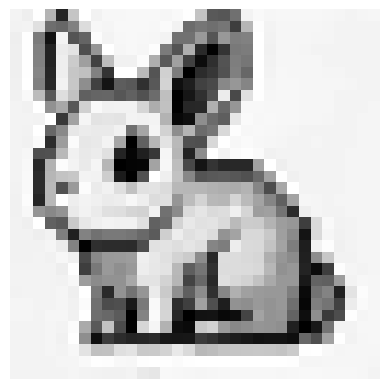

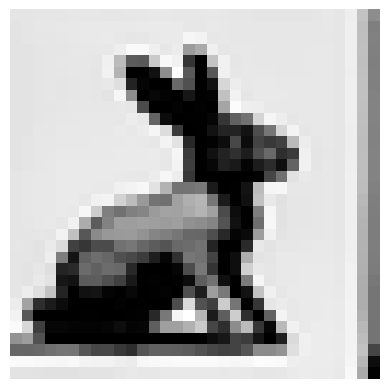

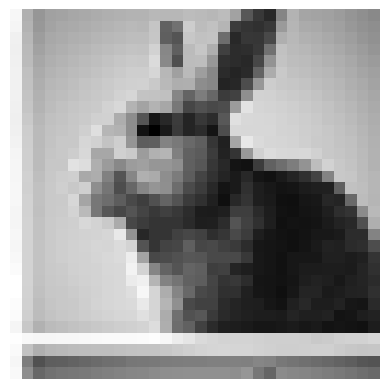

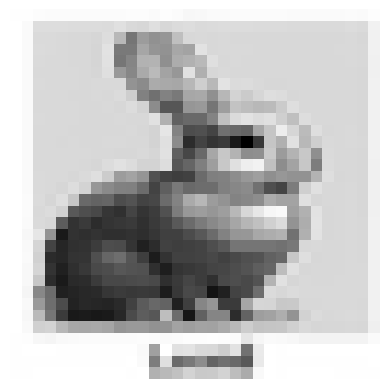

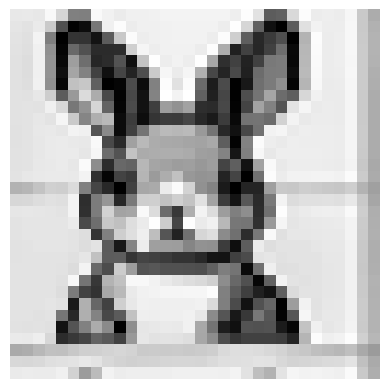

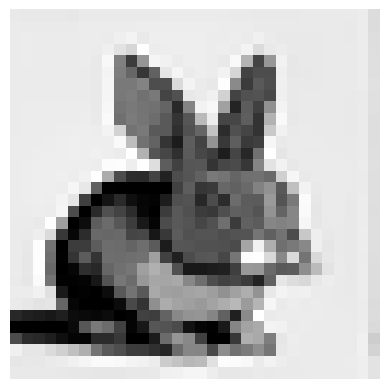

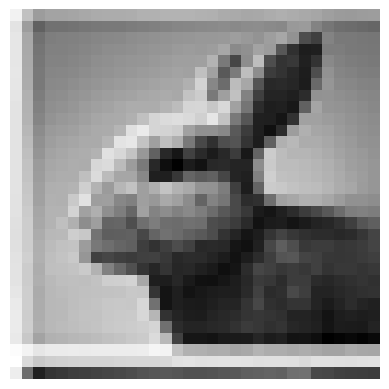

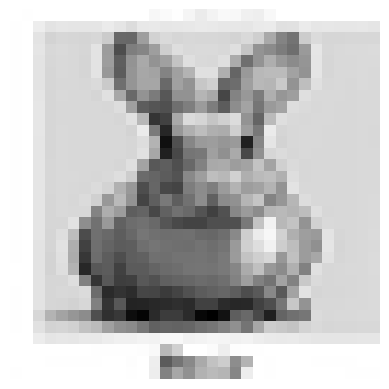

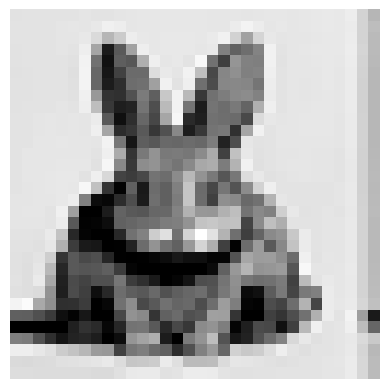

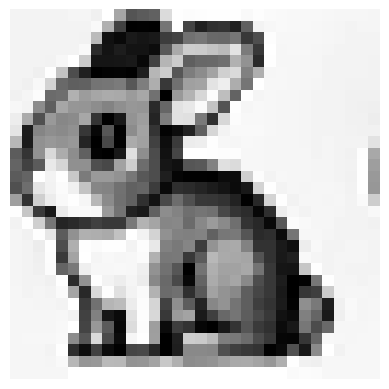

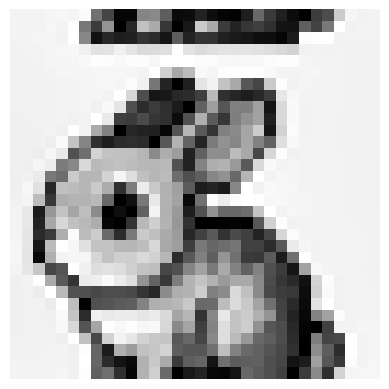

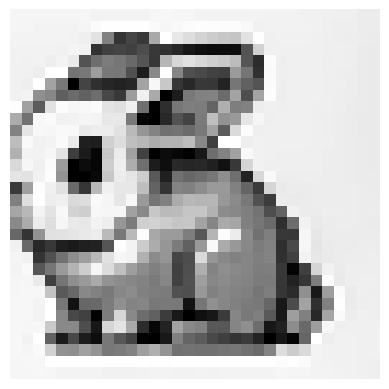

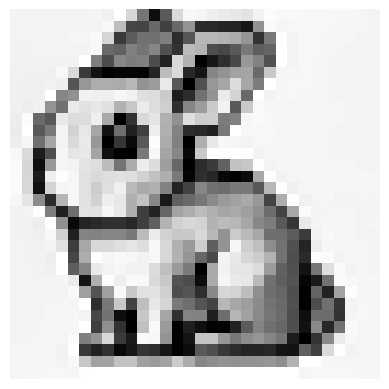

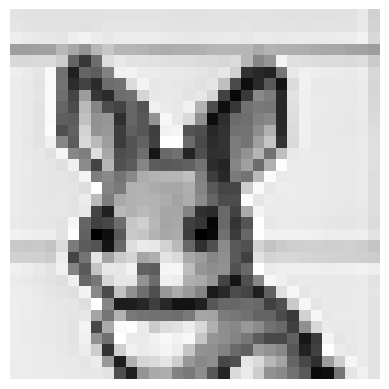

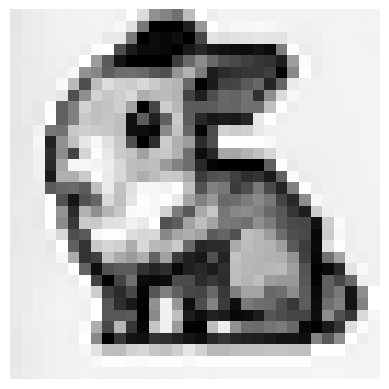

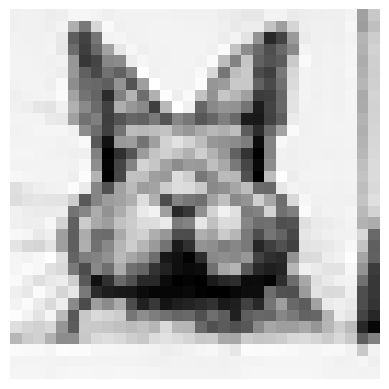

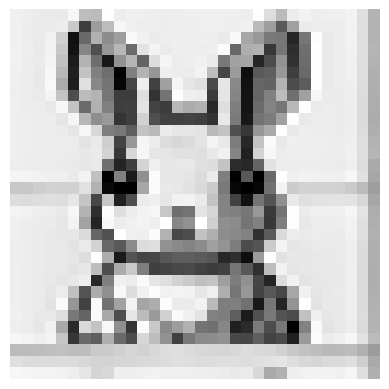

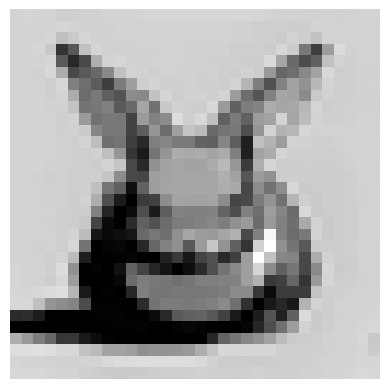

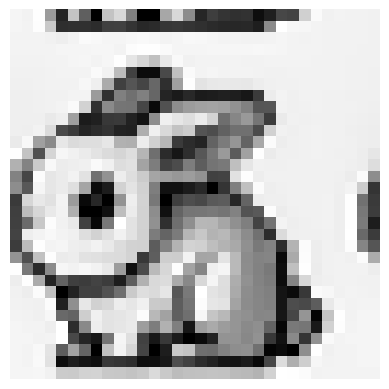

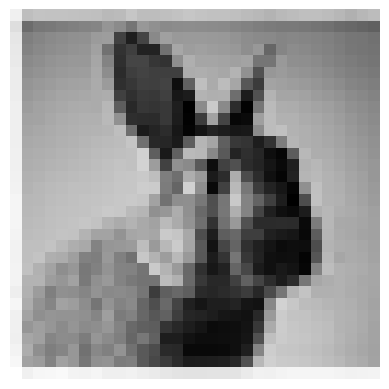

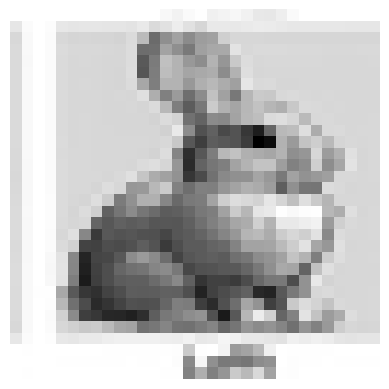

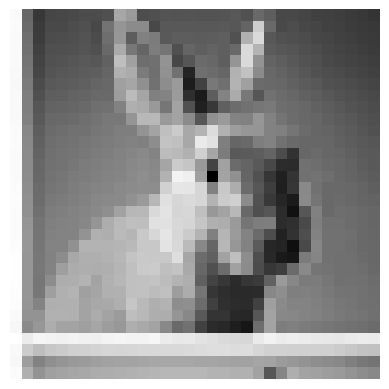

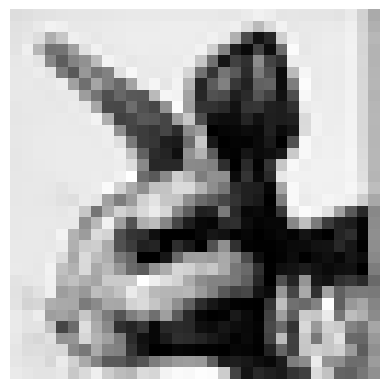

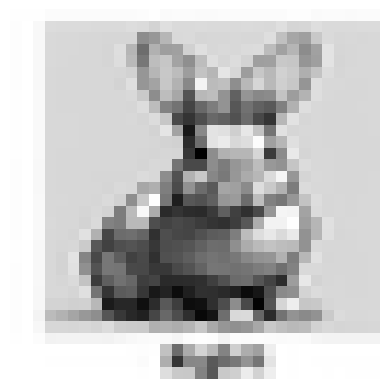

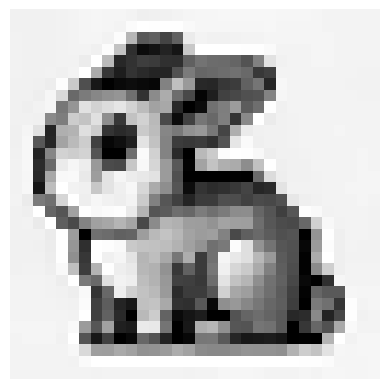

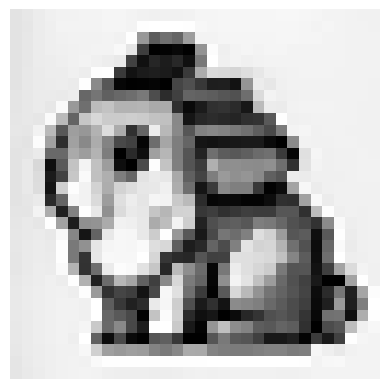

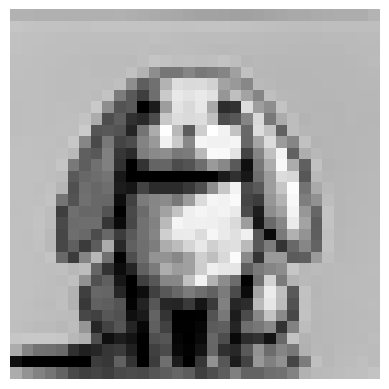

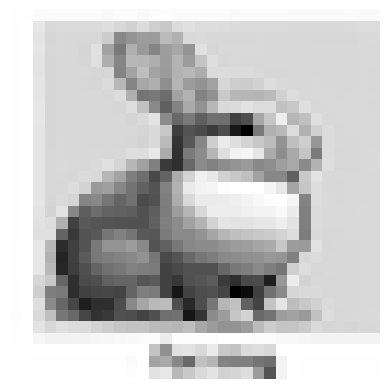

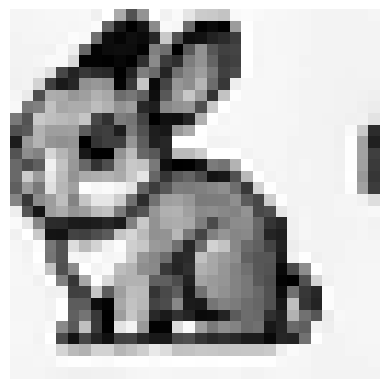

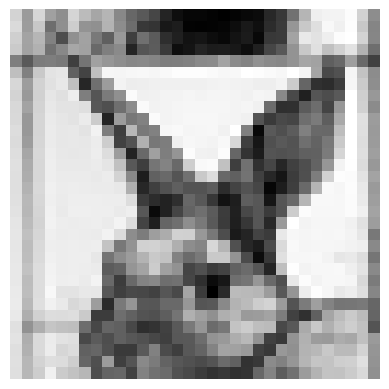

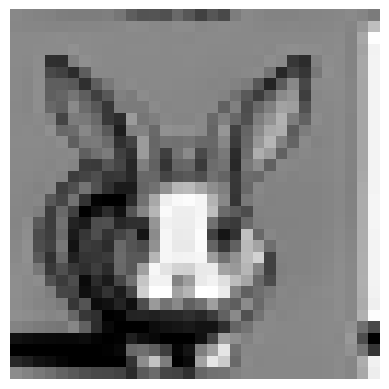

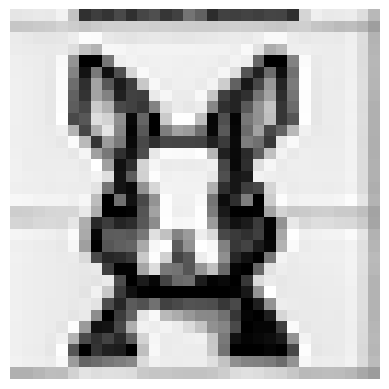

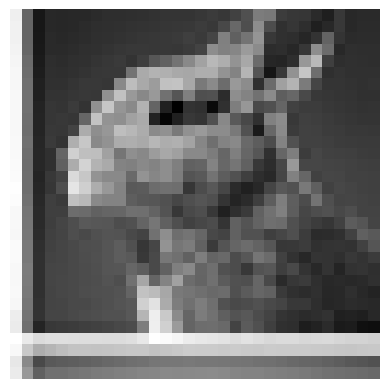

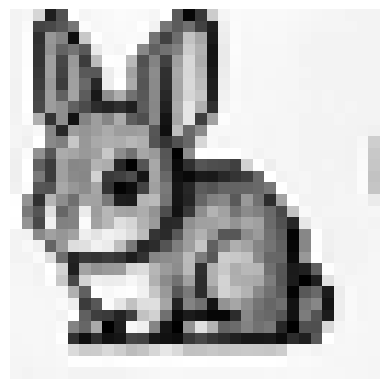

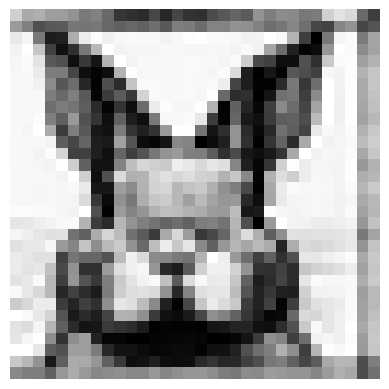

Label: bird, Len: 119


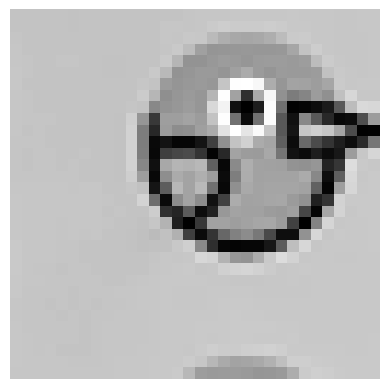

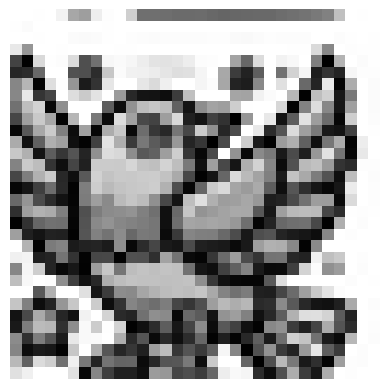

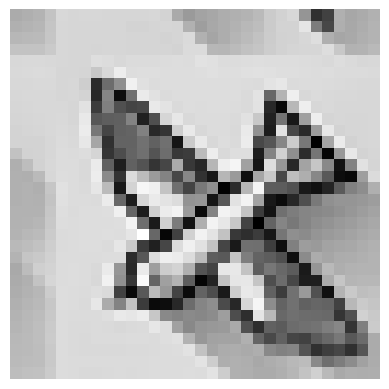

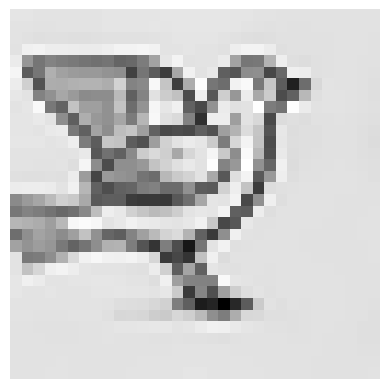

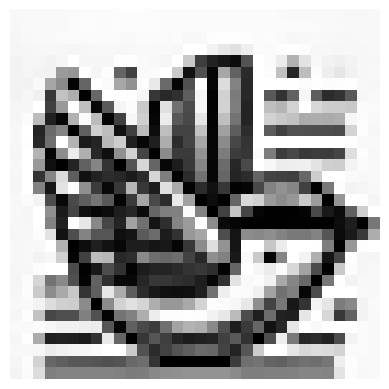

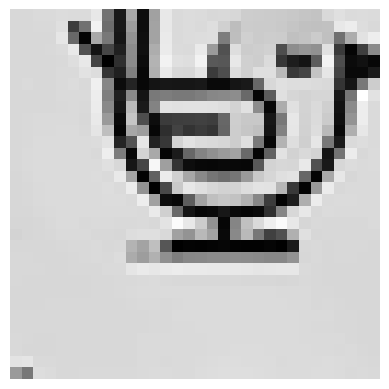

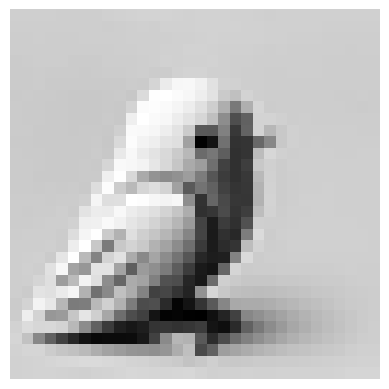

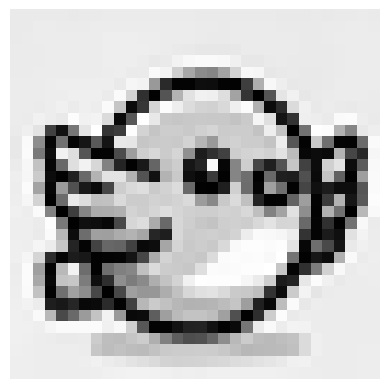

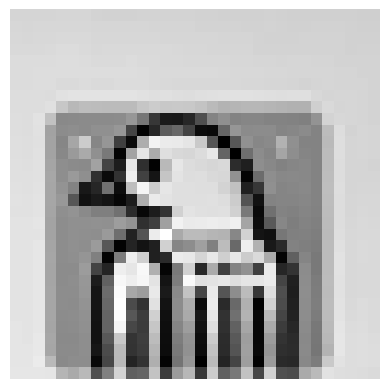

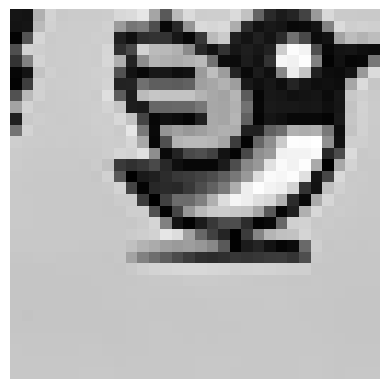

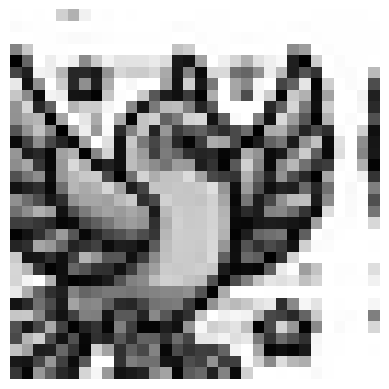

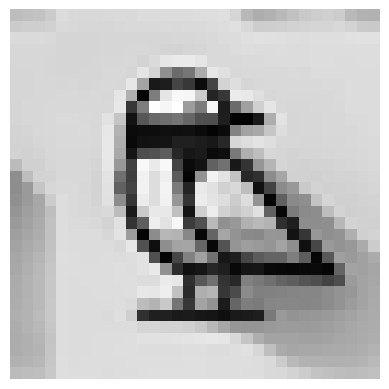

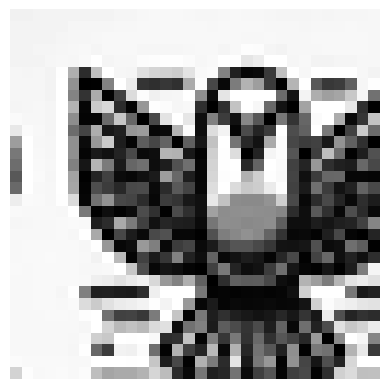

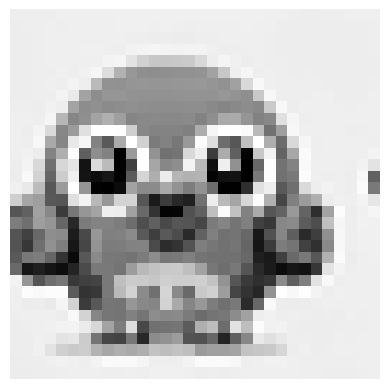

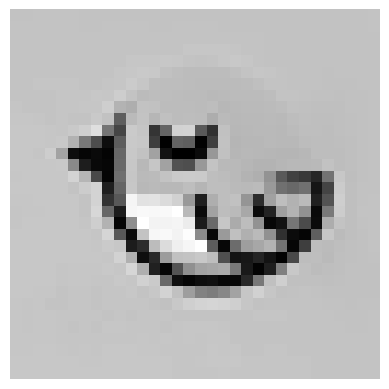

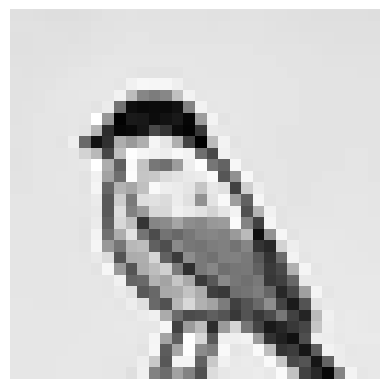

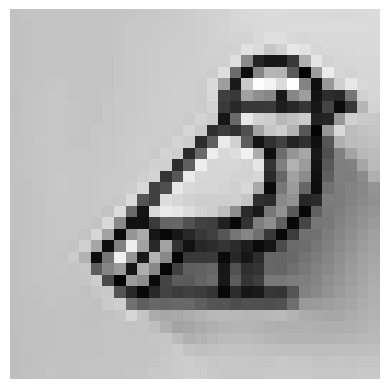

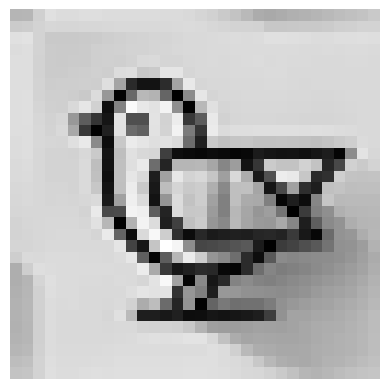

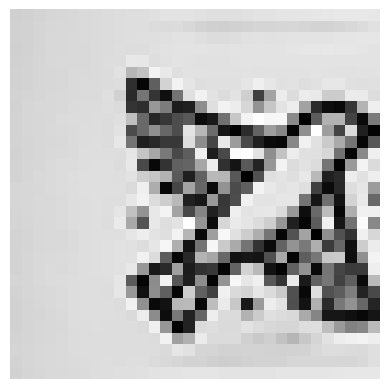

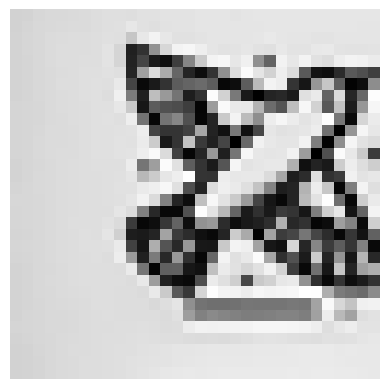

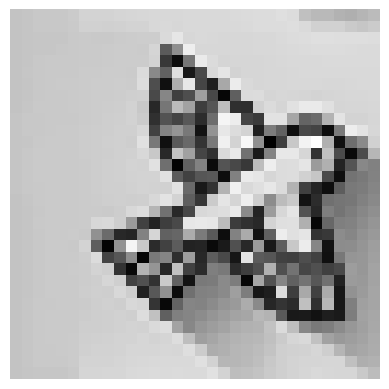

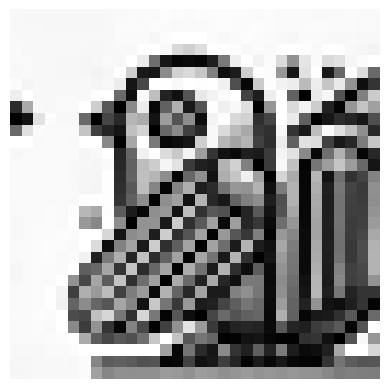

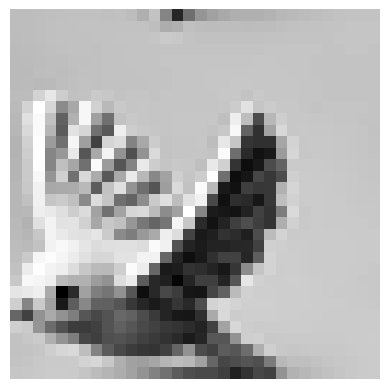

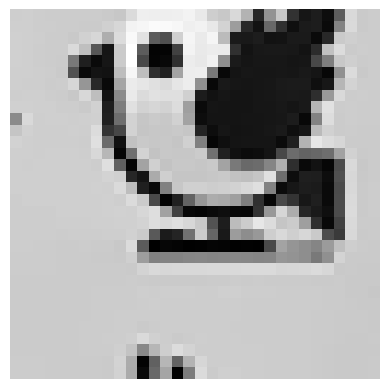

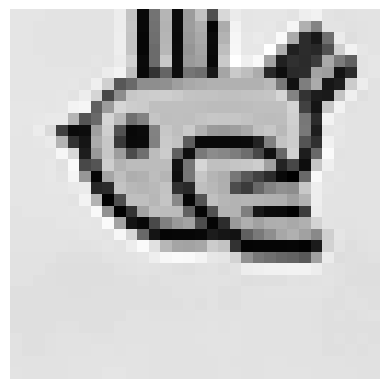

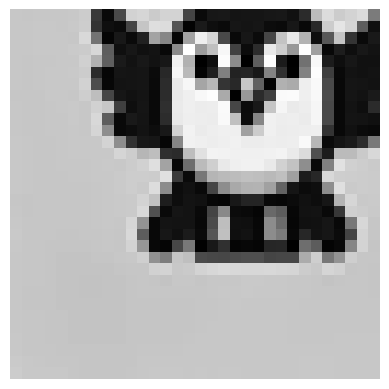

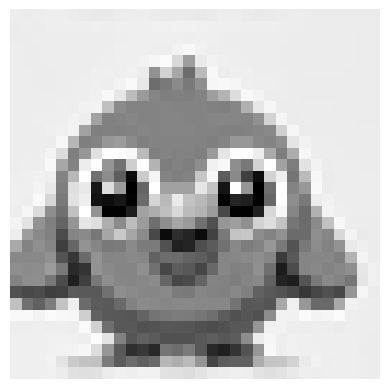

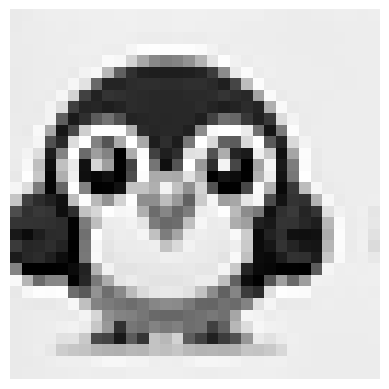

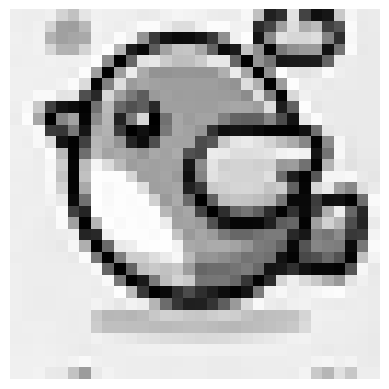

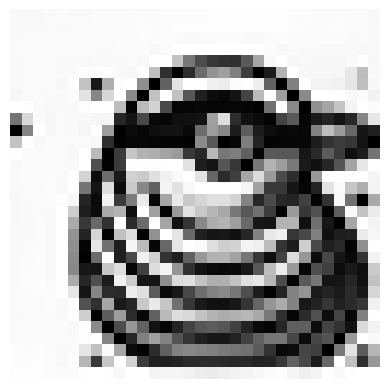

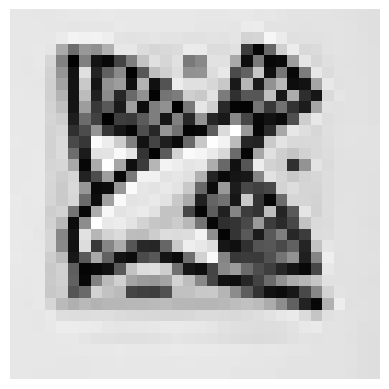

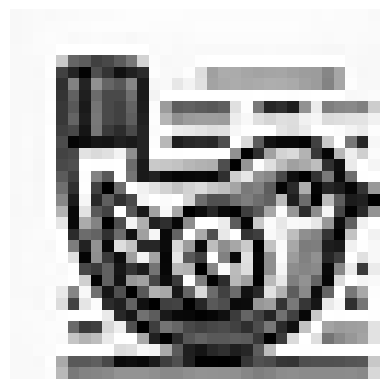

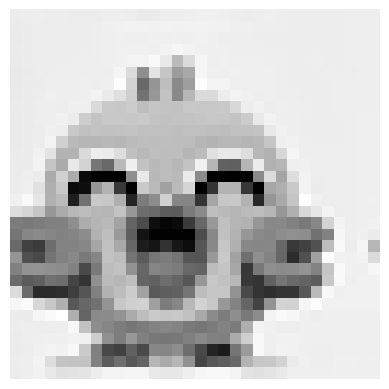

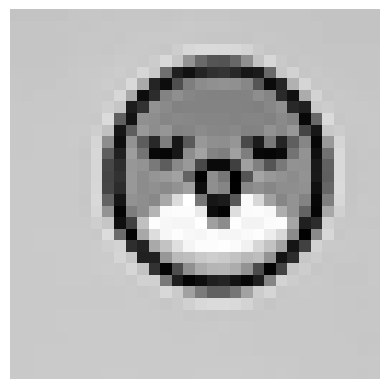

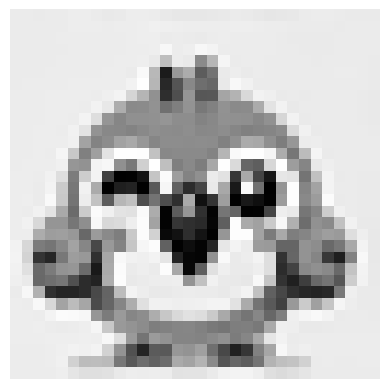

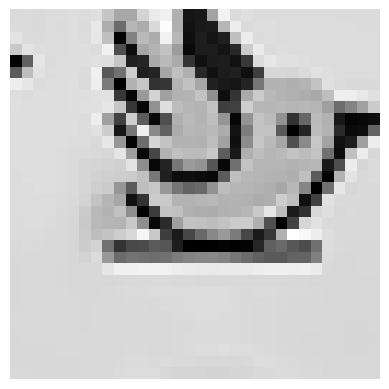

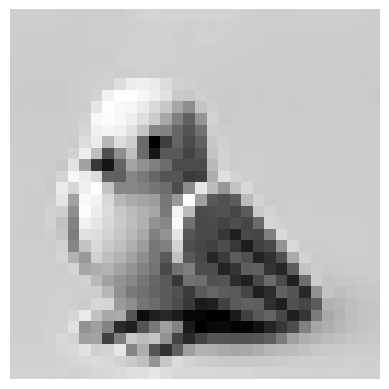

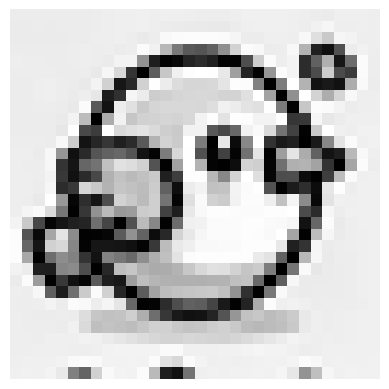

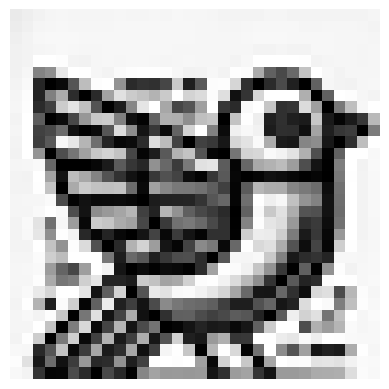

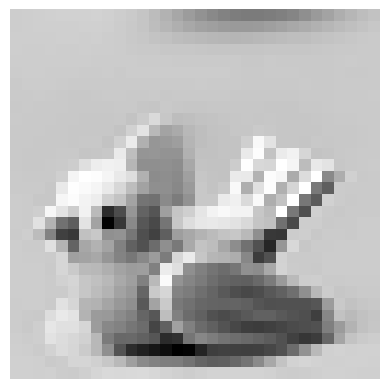

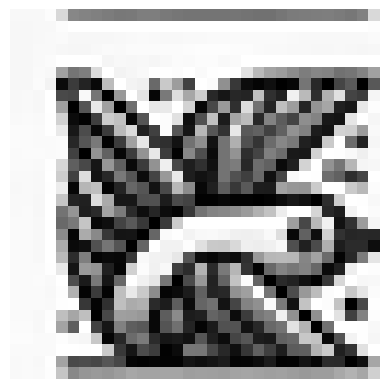

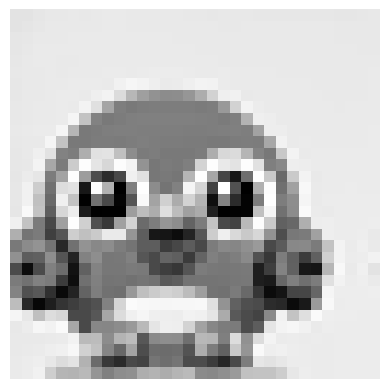

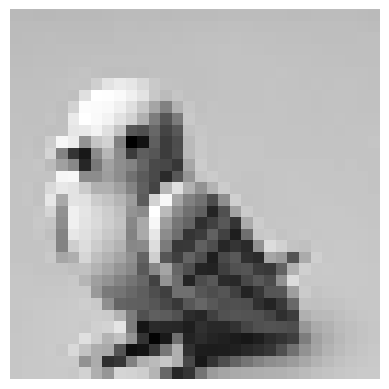

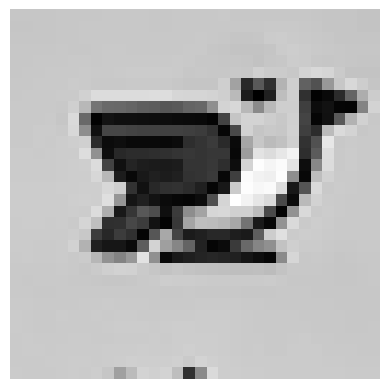

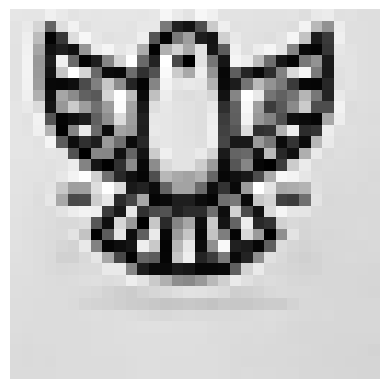

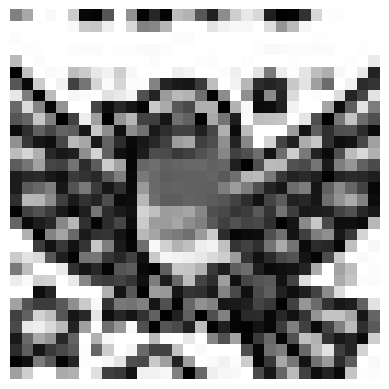

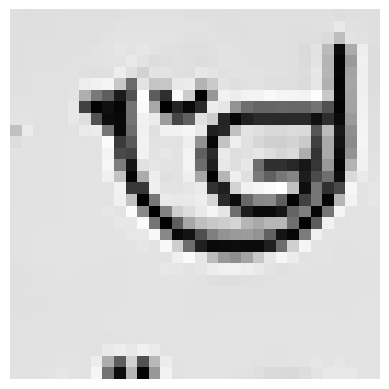

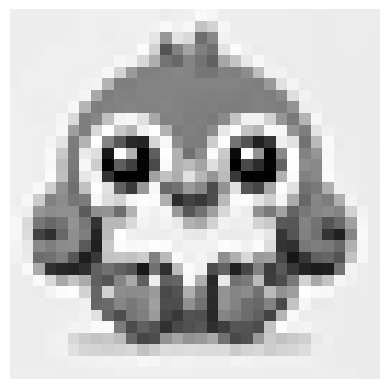

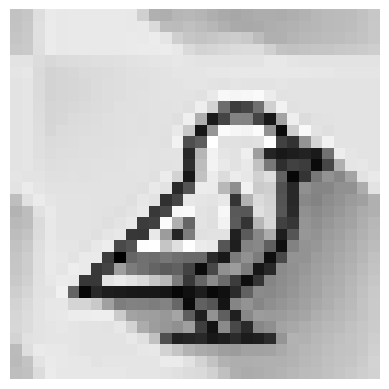

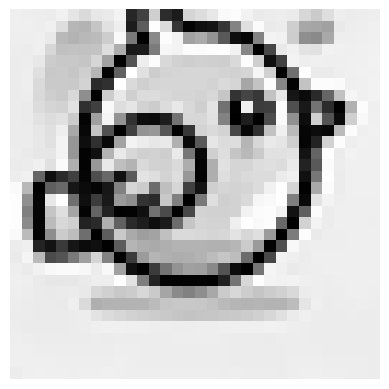

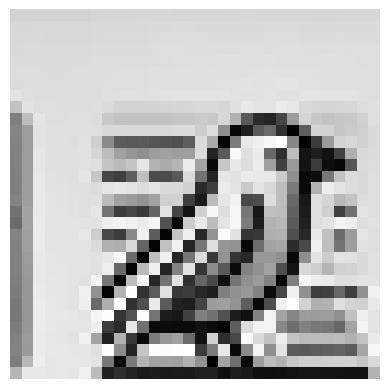

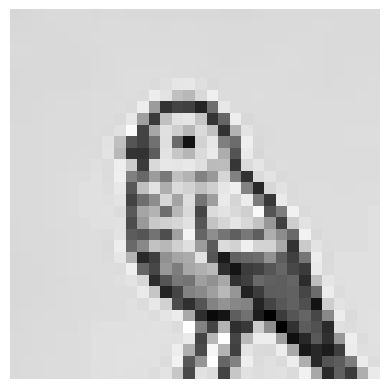

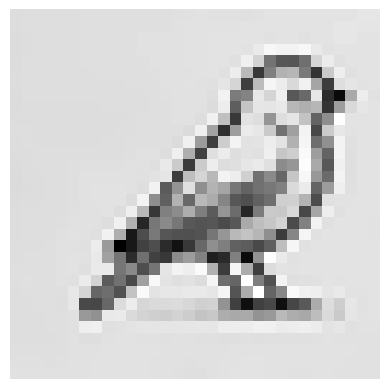

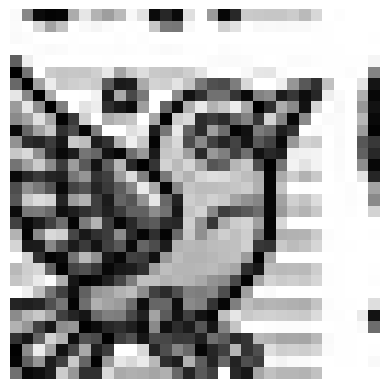

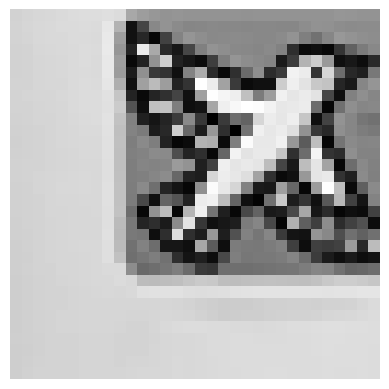

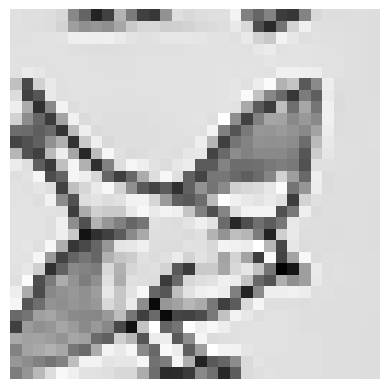

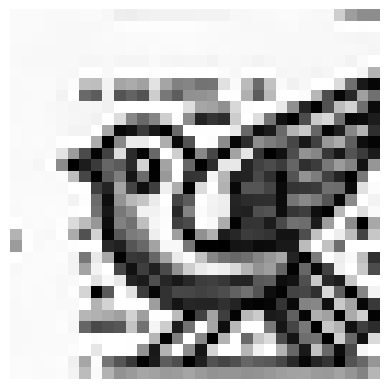

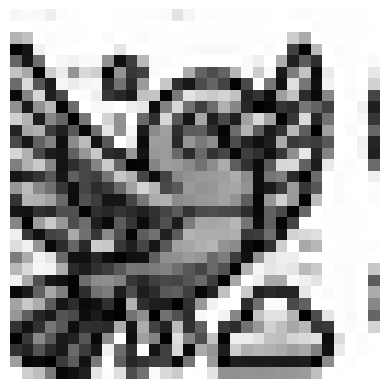

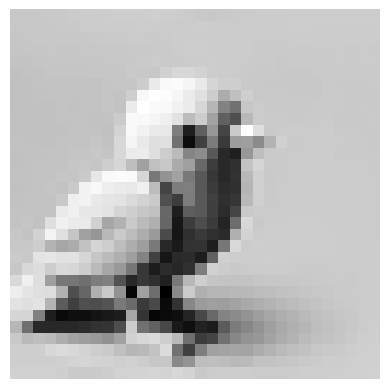

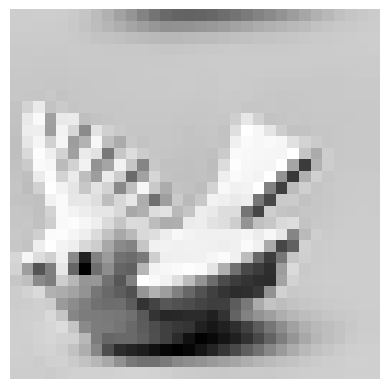

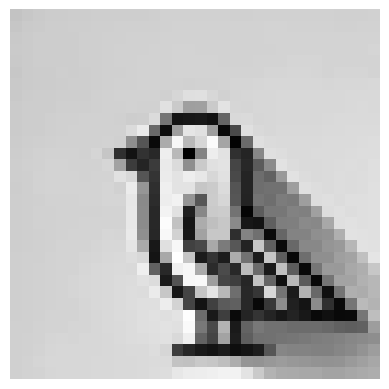

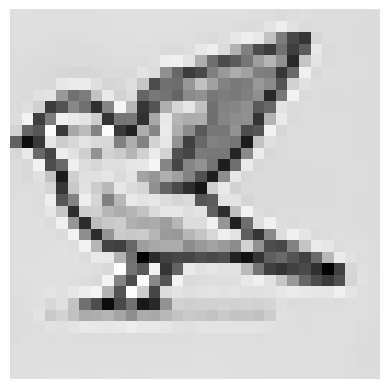

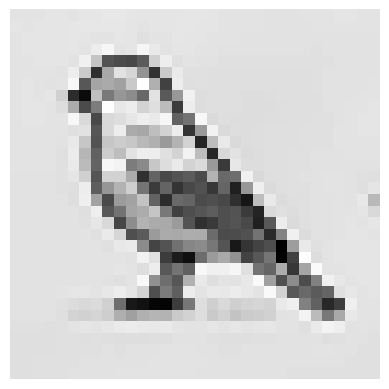

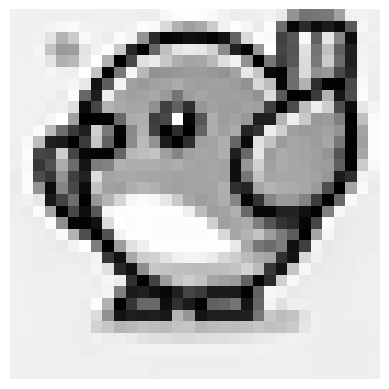

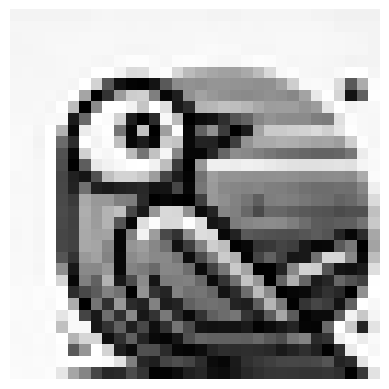

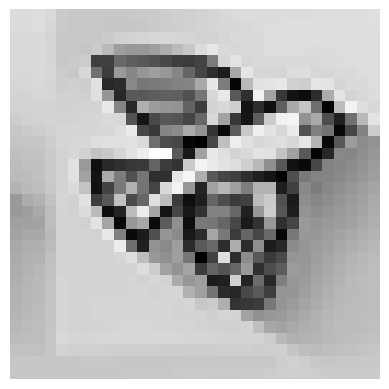

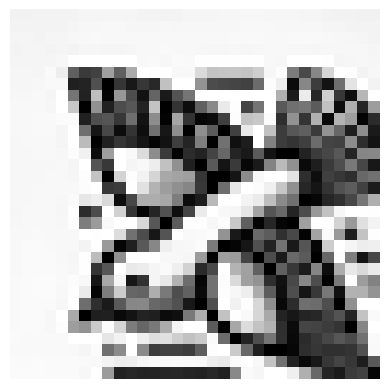

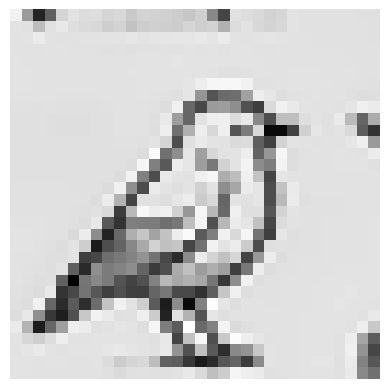

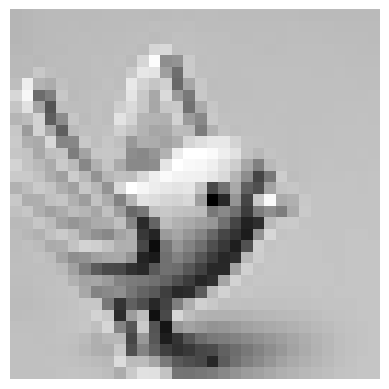

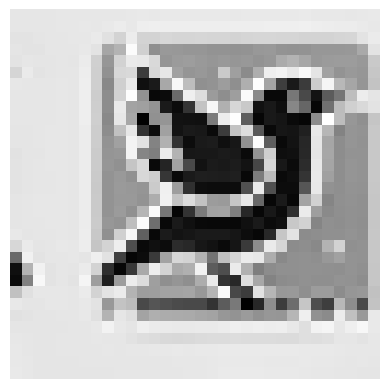

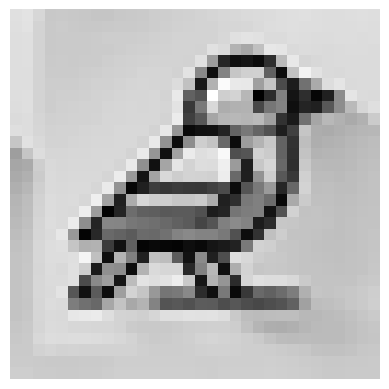

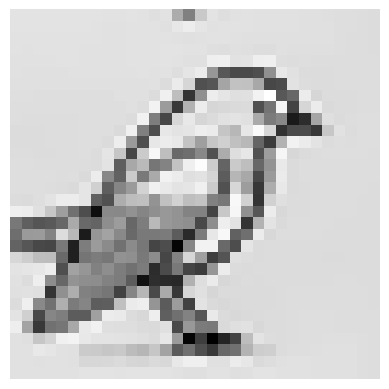

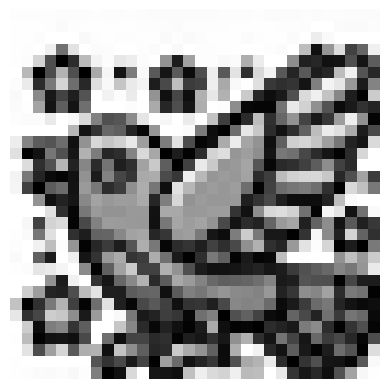

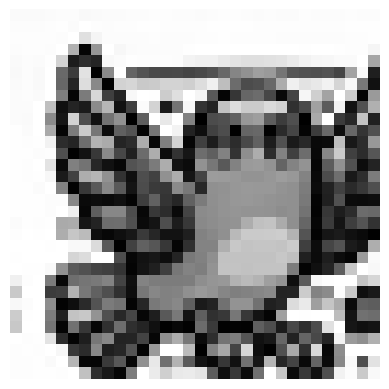

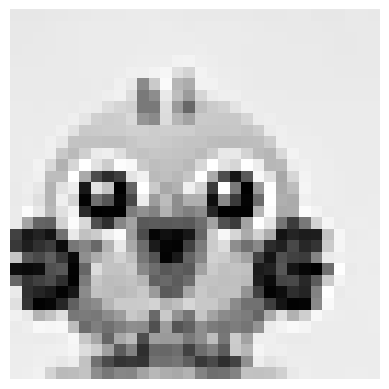

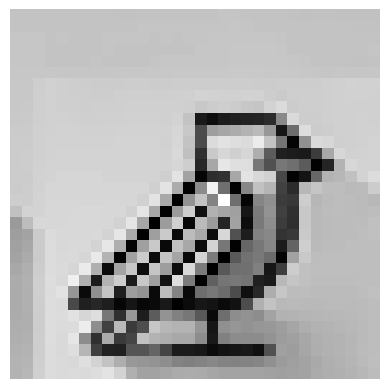

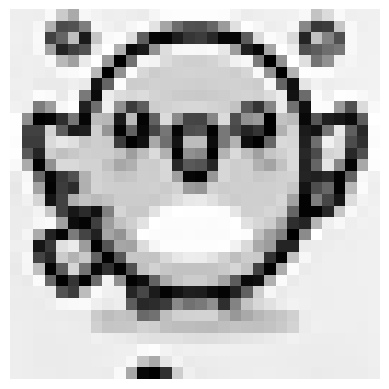

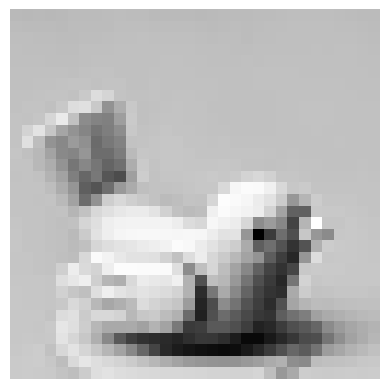

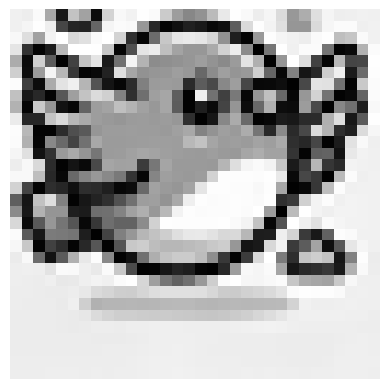

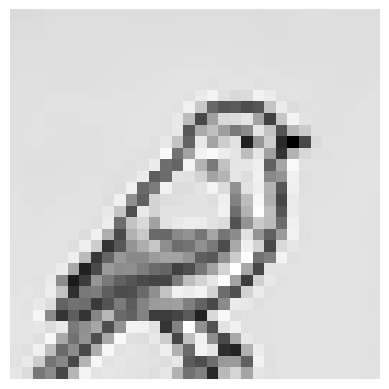

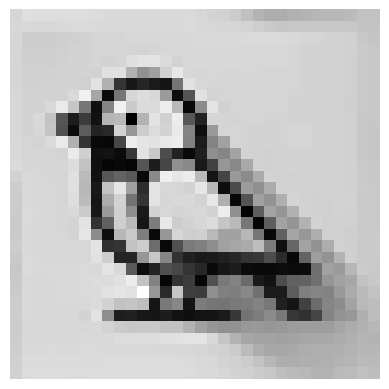

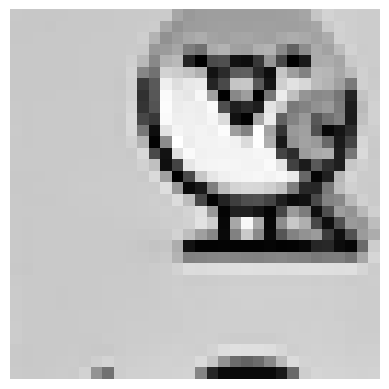

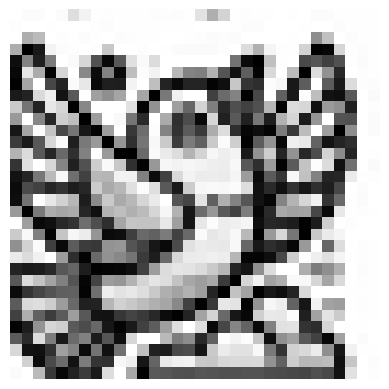

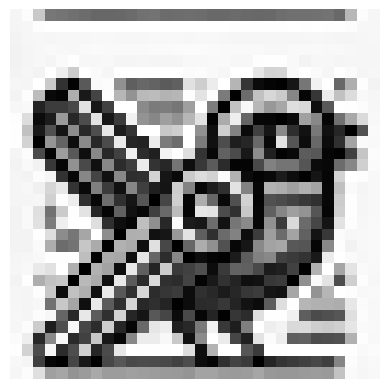

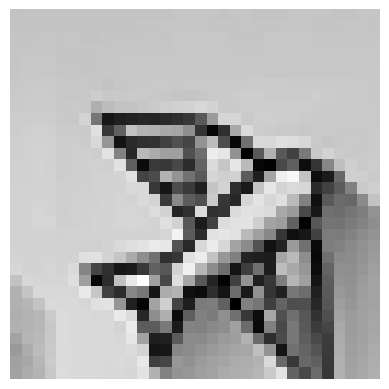

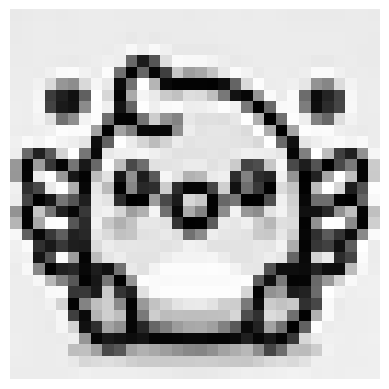

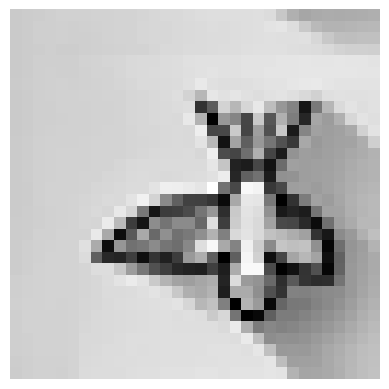

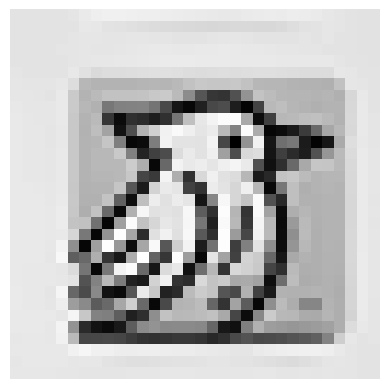

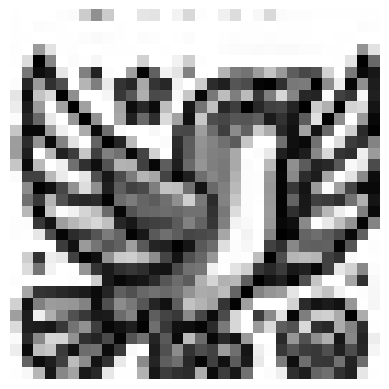

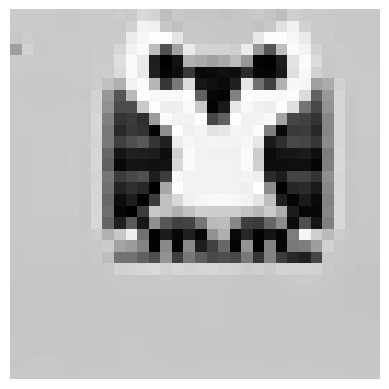

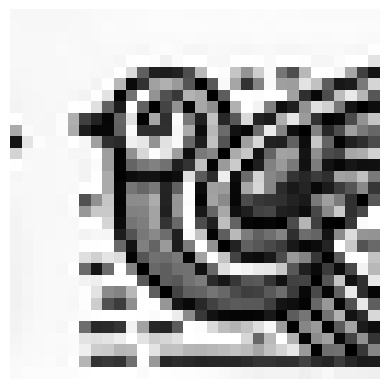

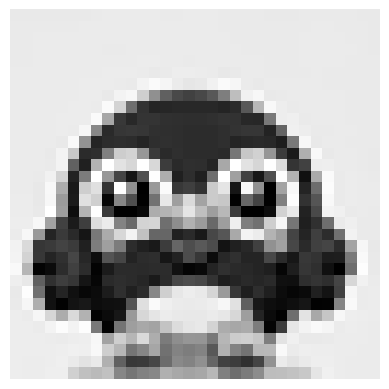

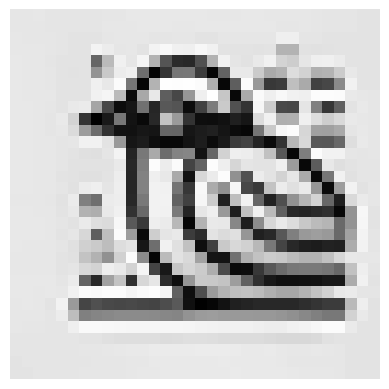

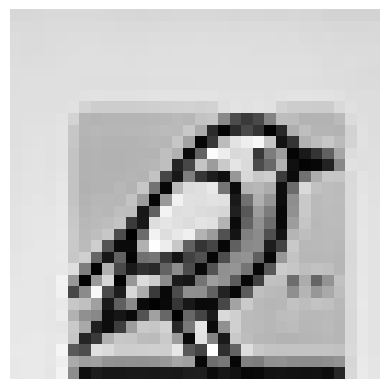

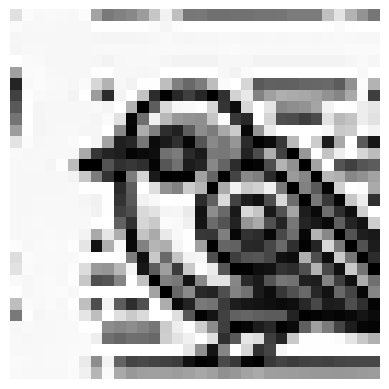

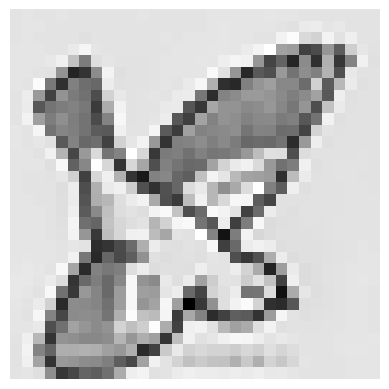

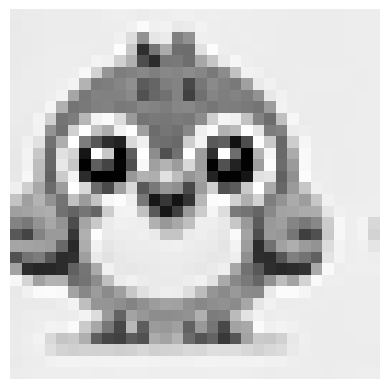

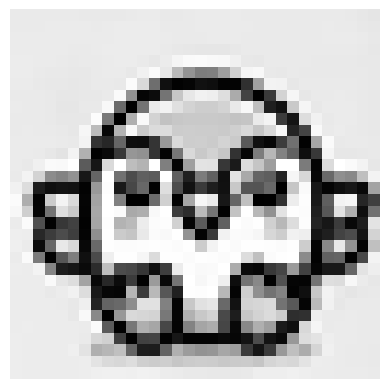

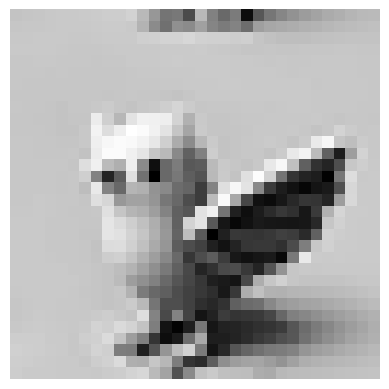

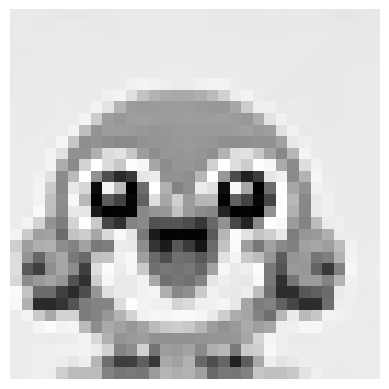

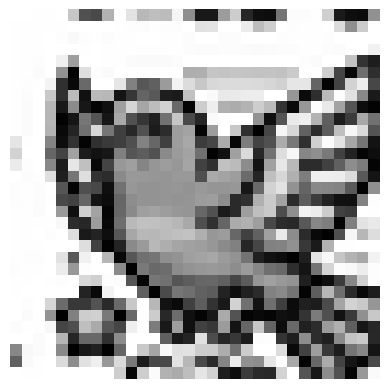

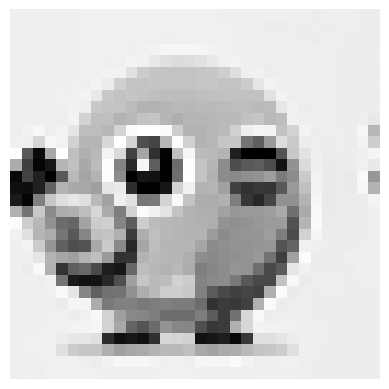

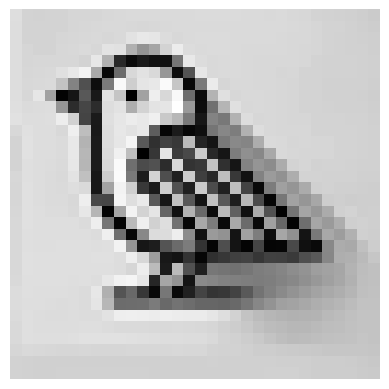

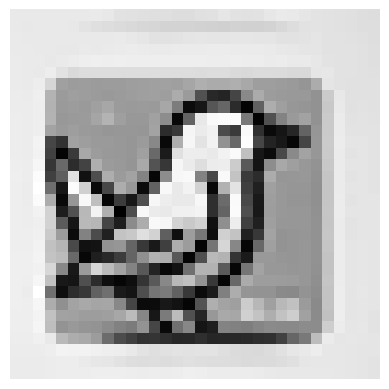

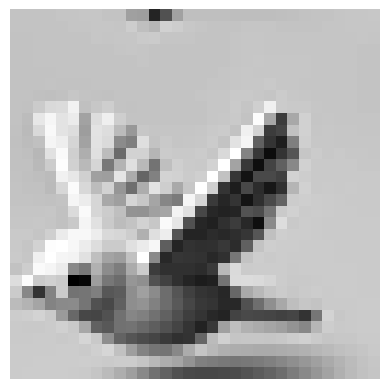

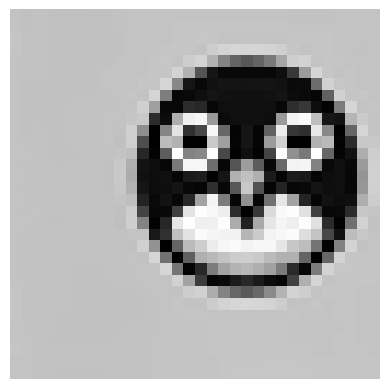

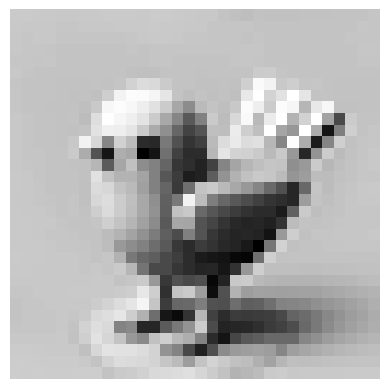

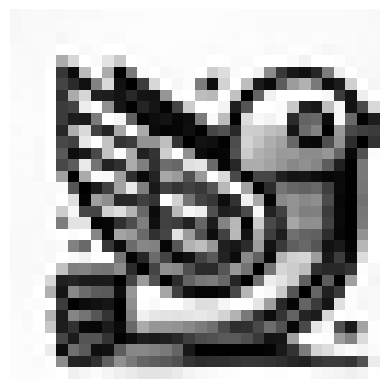

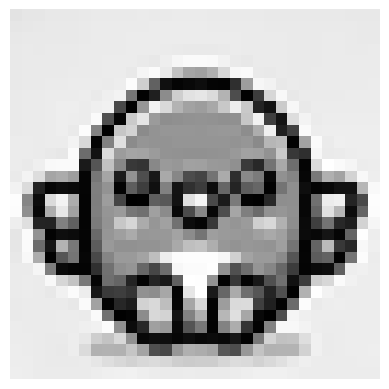

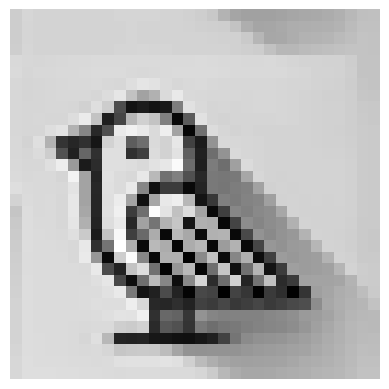

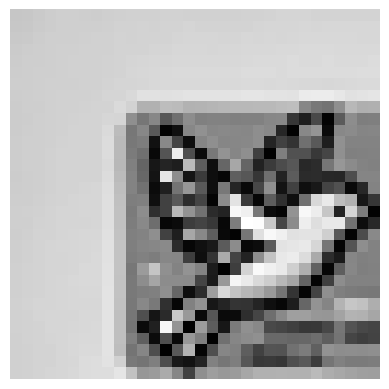

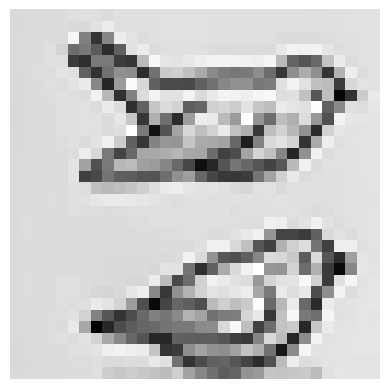

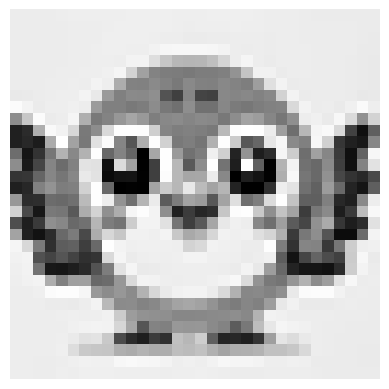

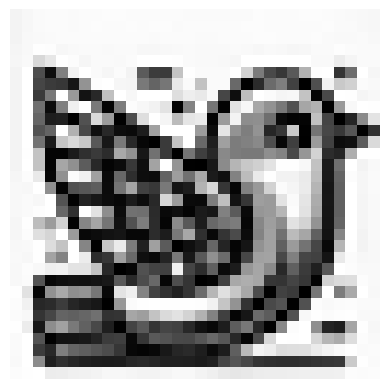

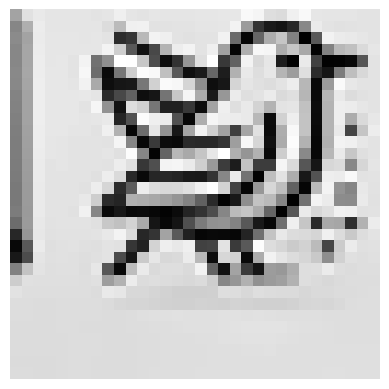

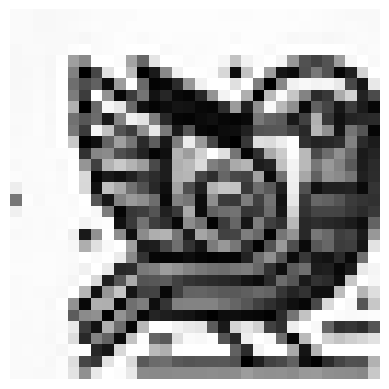

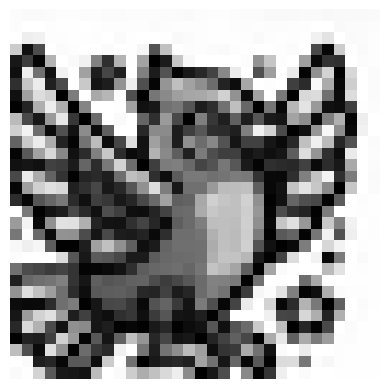

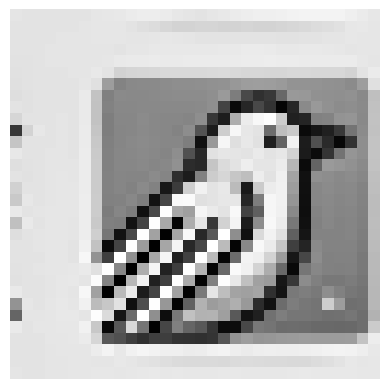

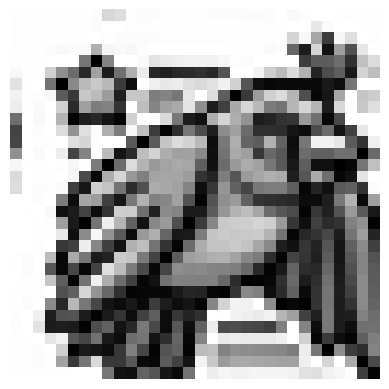

Label: truck, Len: 32


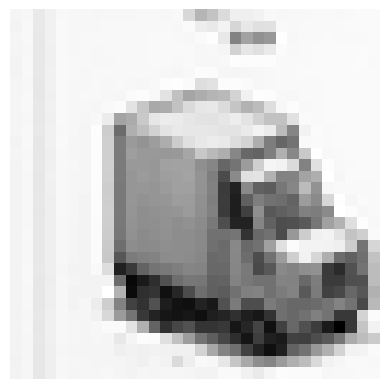

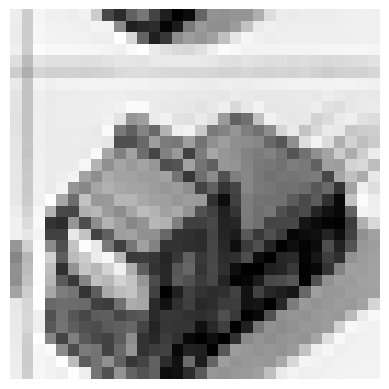

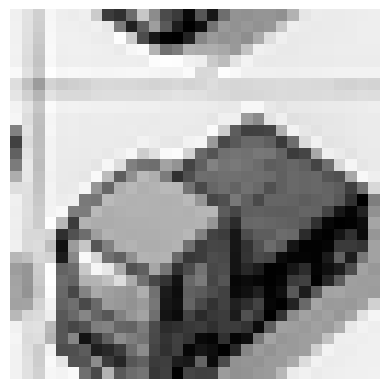

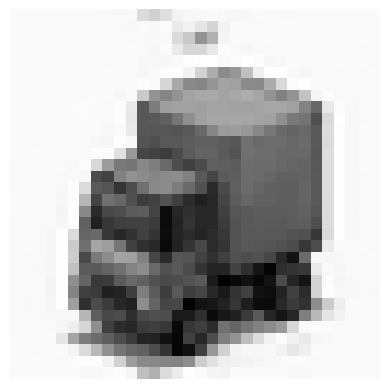

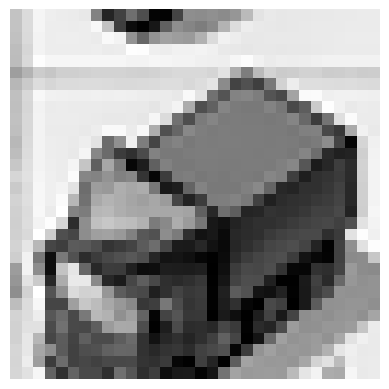

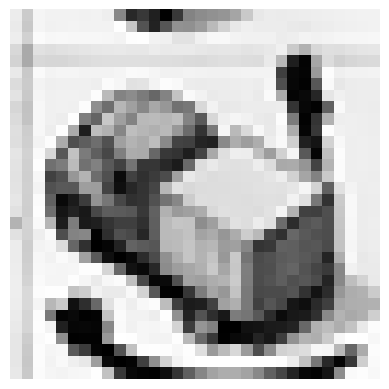

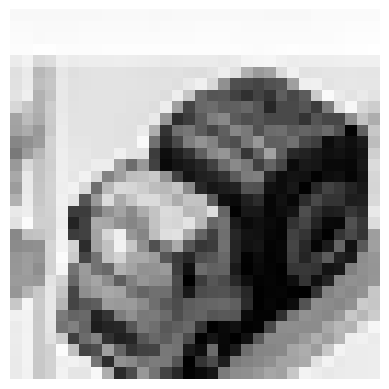

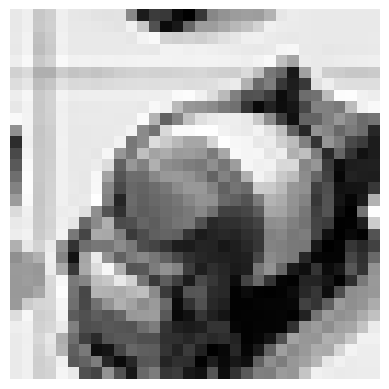

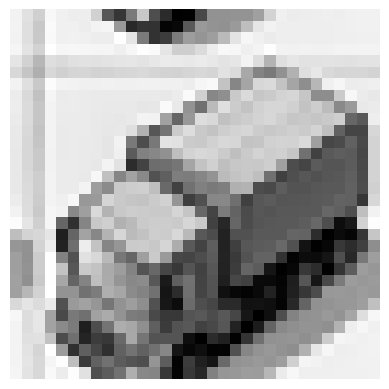

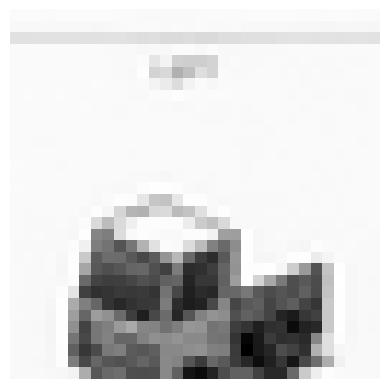

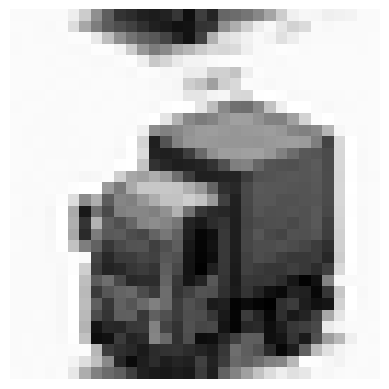

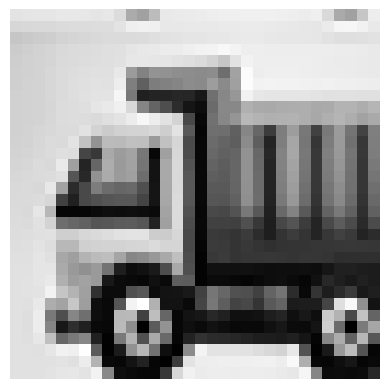

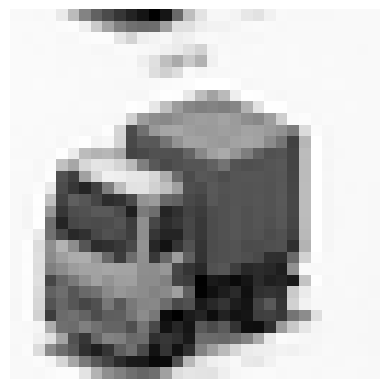

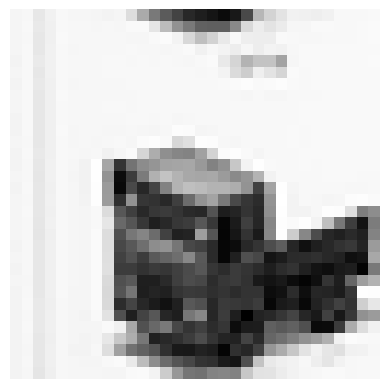

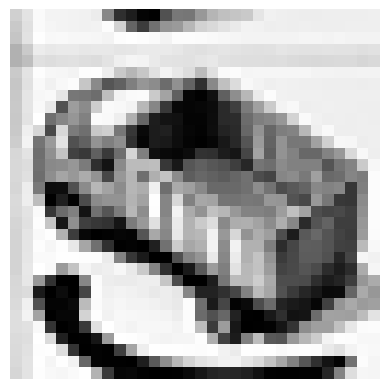

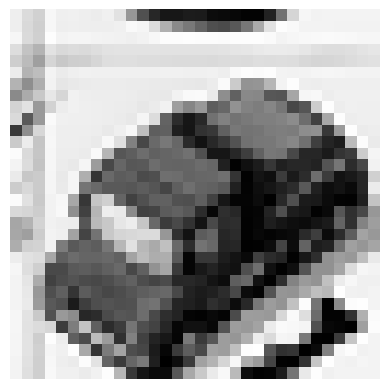

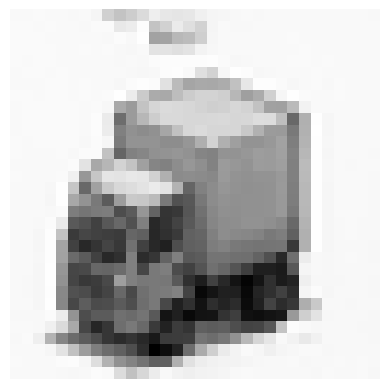

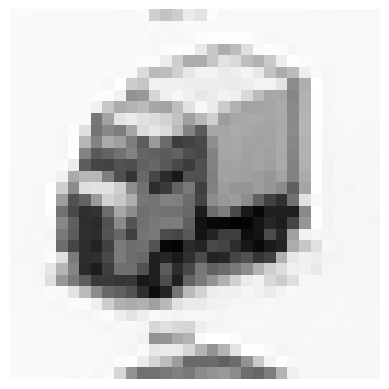

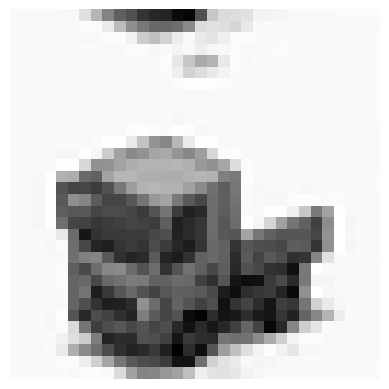

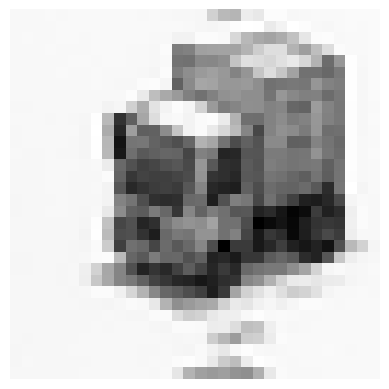

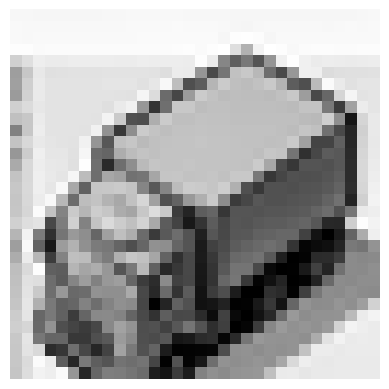

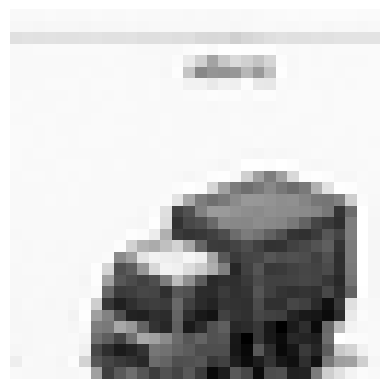

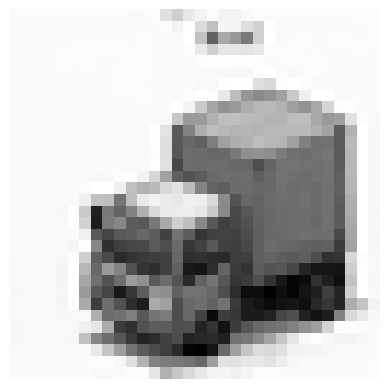

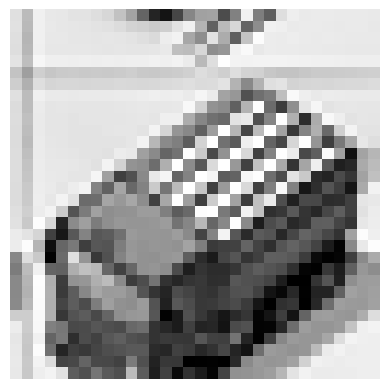

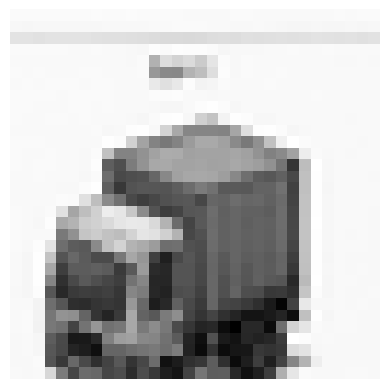

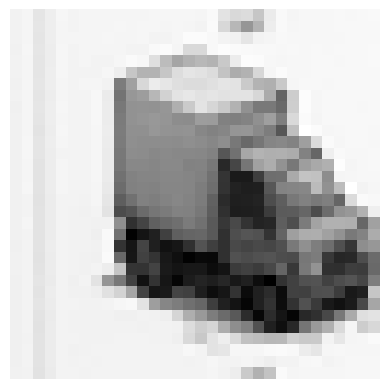

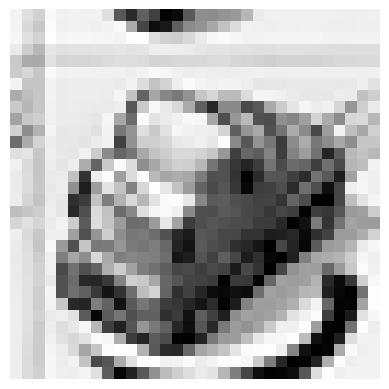

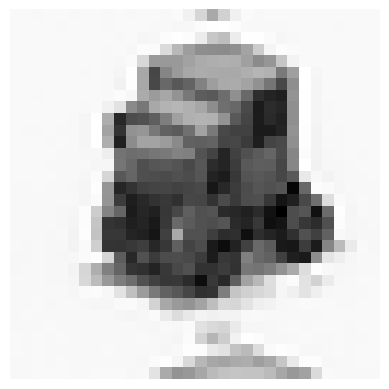

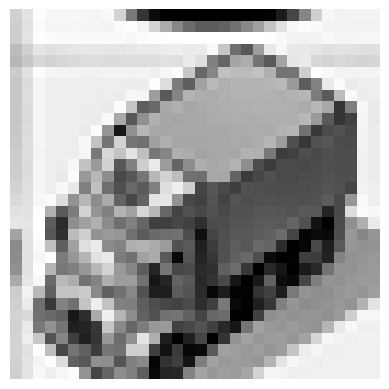

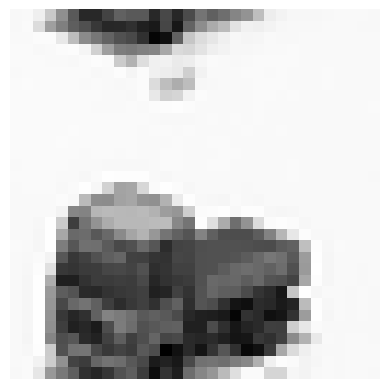

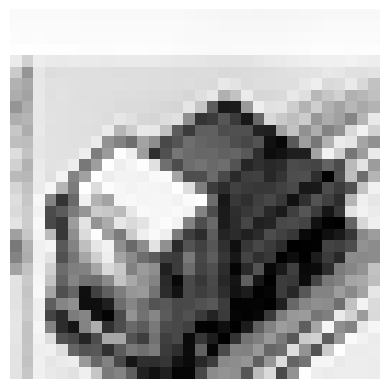

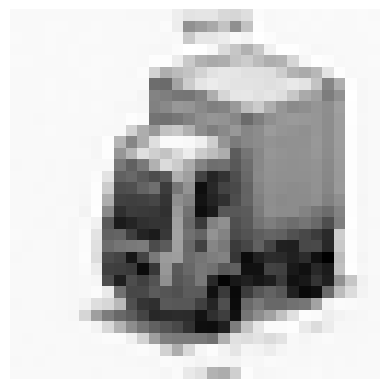

Label: ball, Len: 37


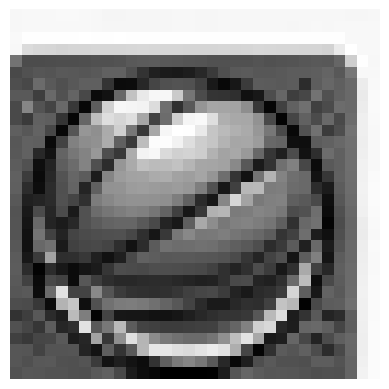

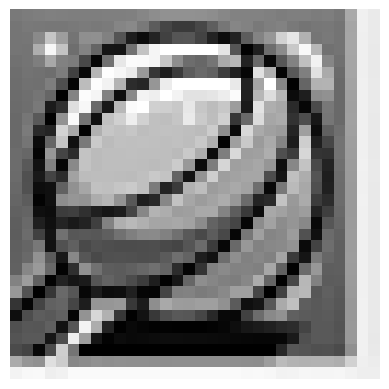

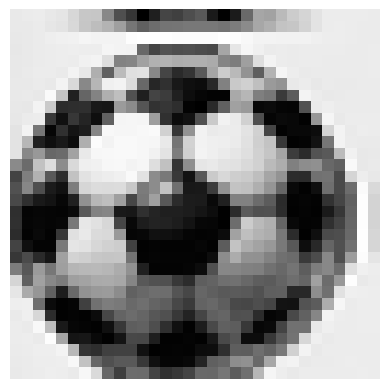

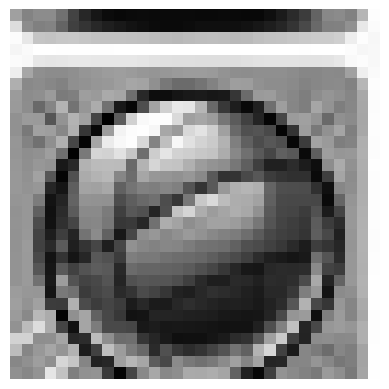

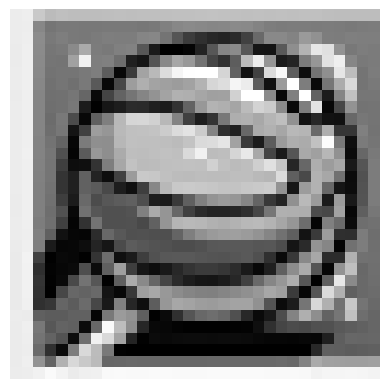

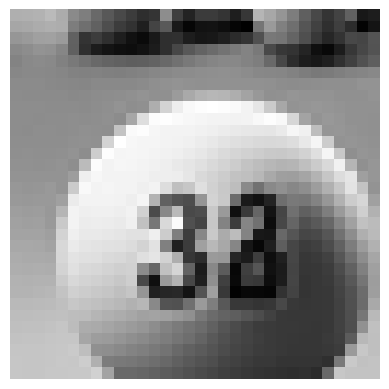

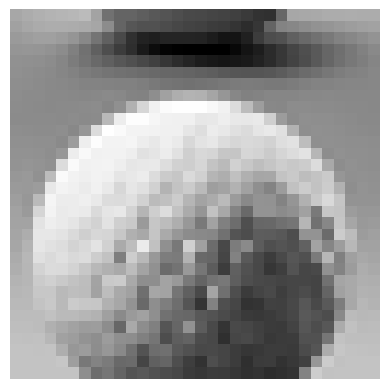

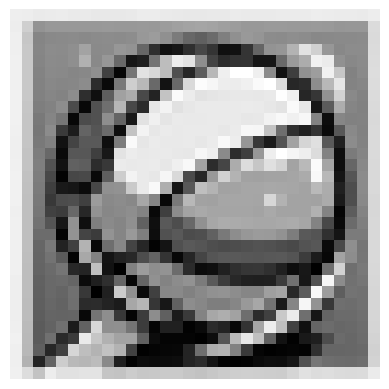

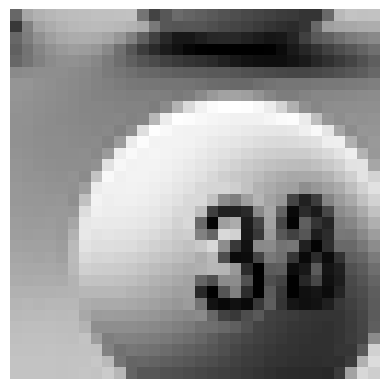

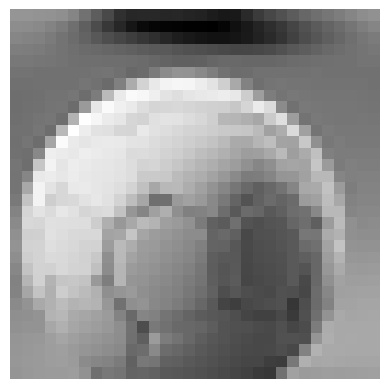

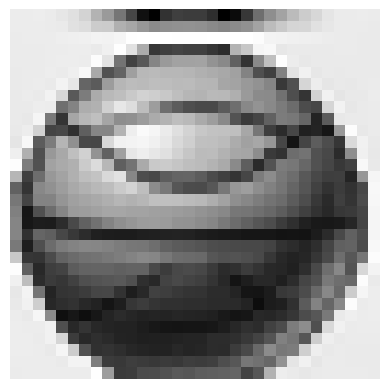

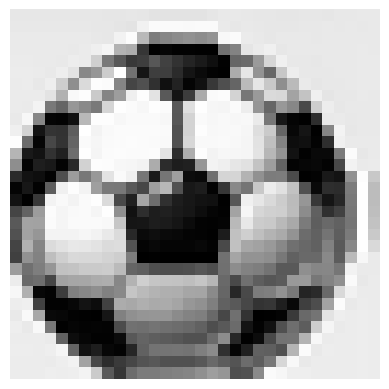

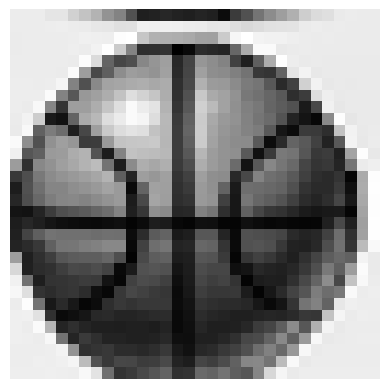

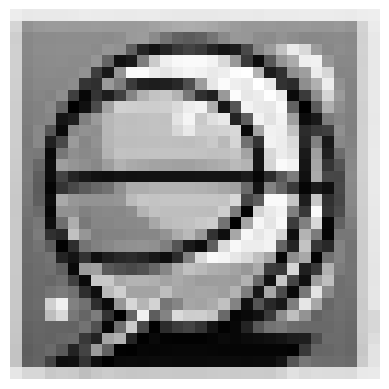

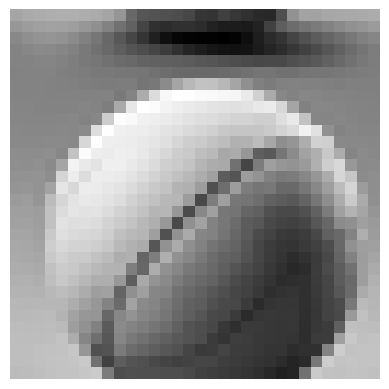

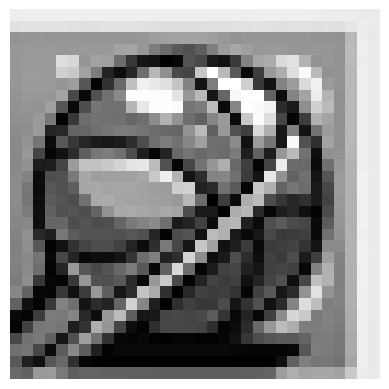

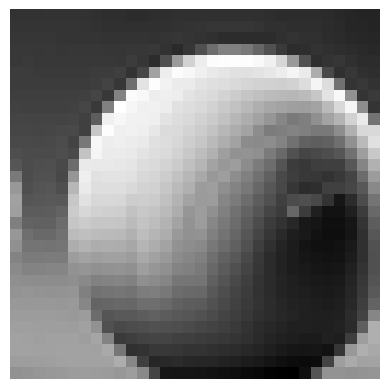

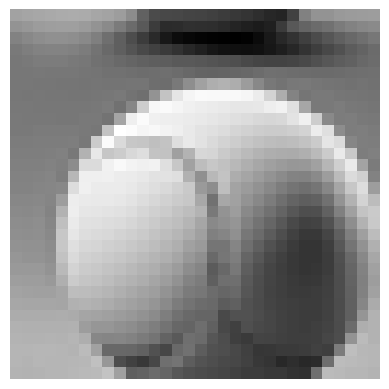

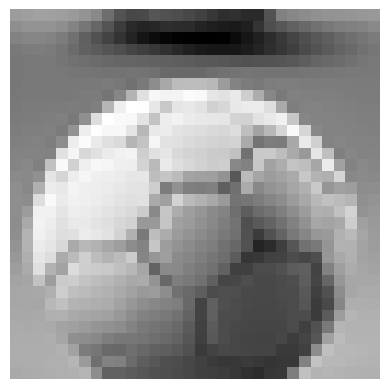

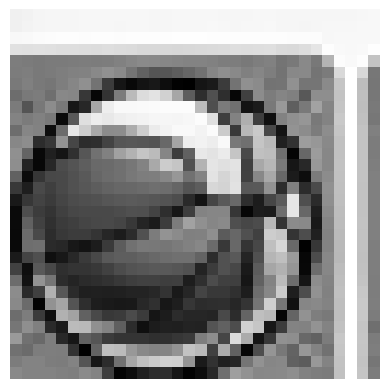

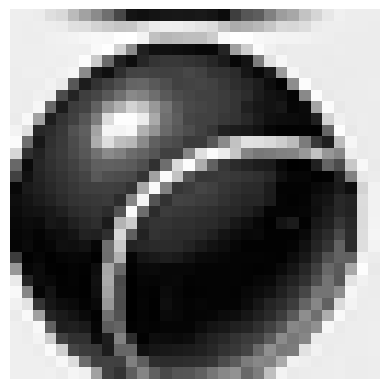

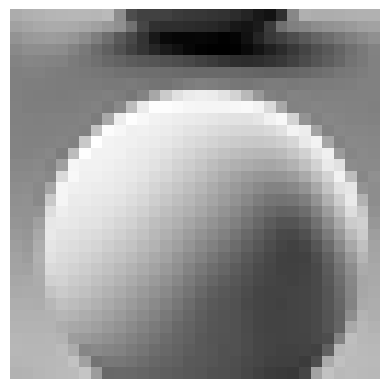

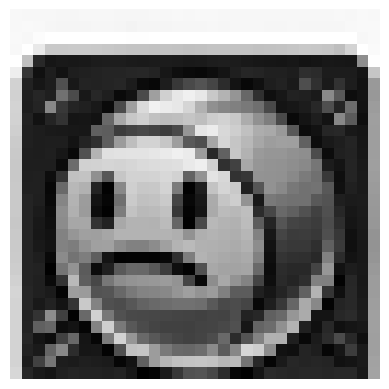

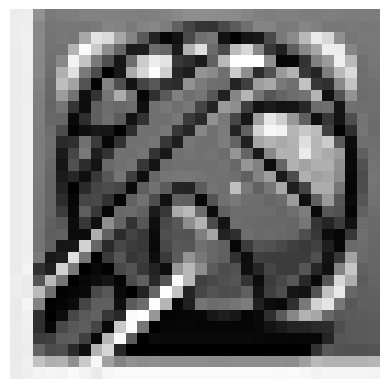

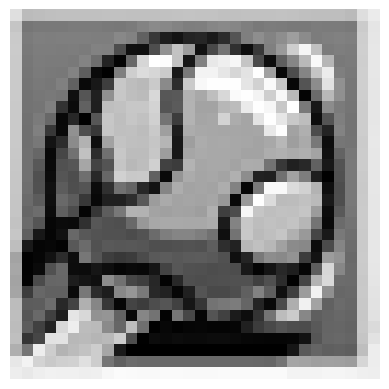

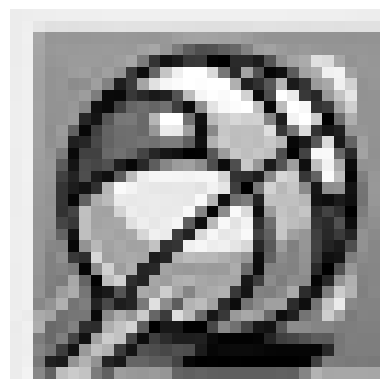

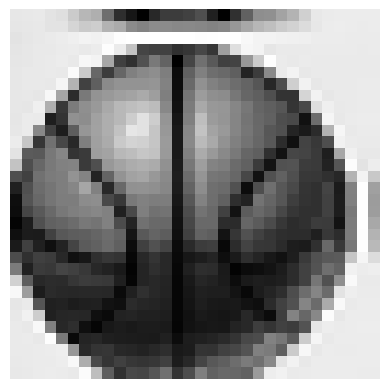

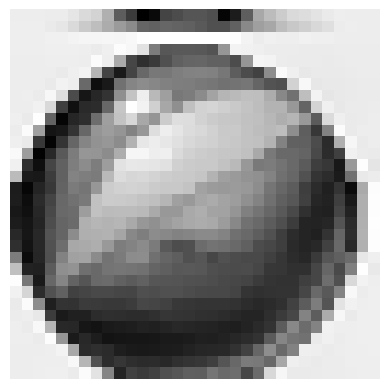

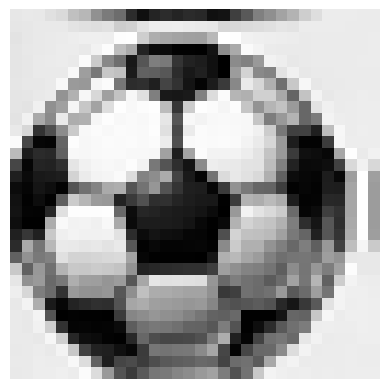

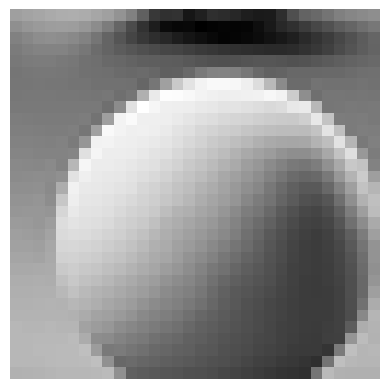

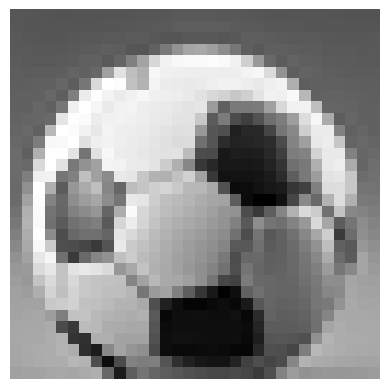

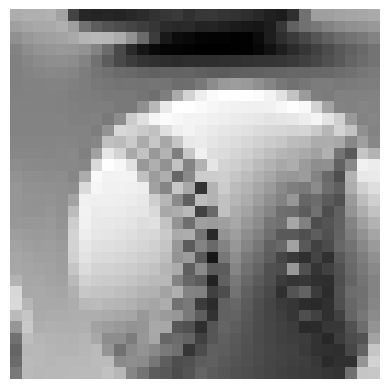

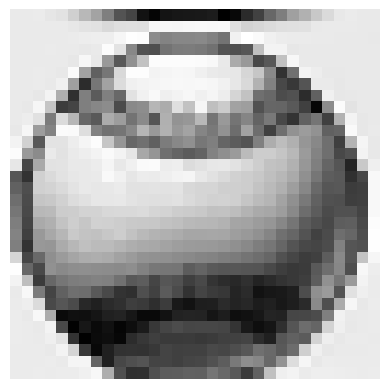

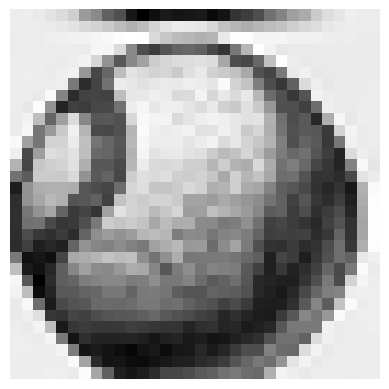

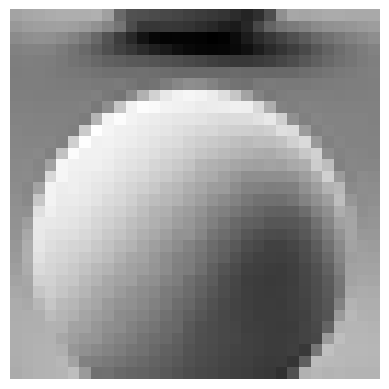

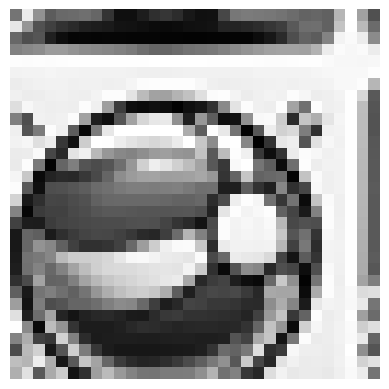

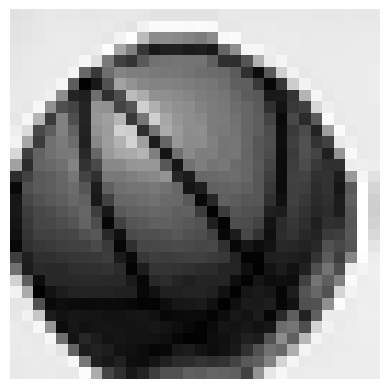

Label: police_car, Len: 21


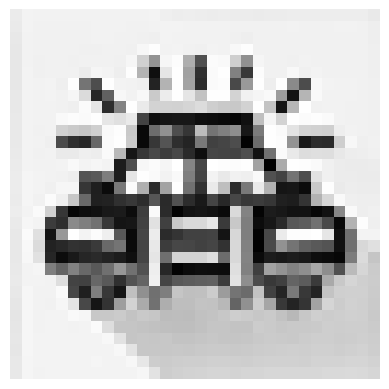

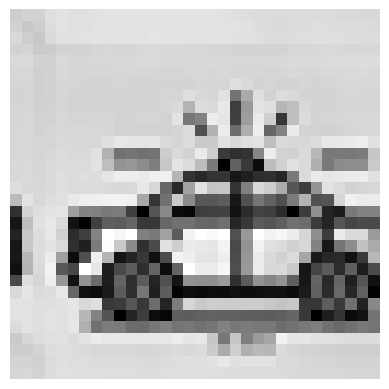

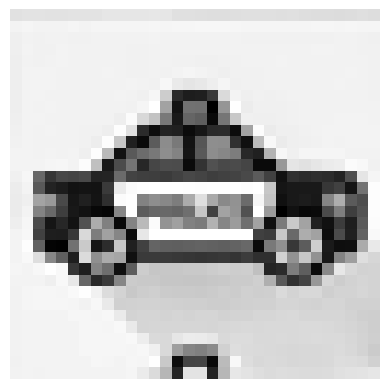

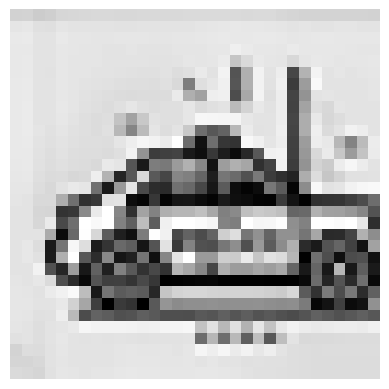

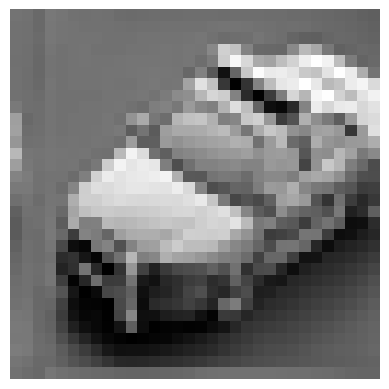

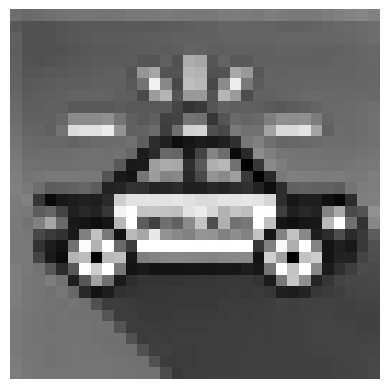

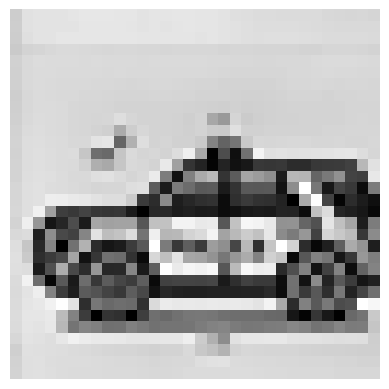

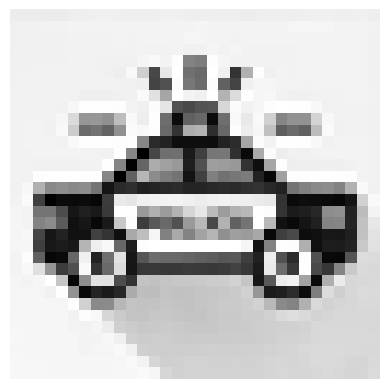

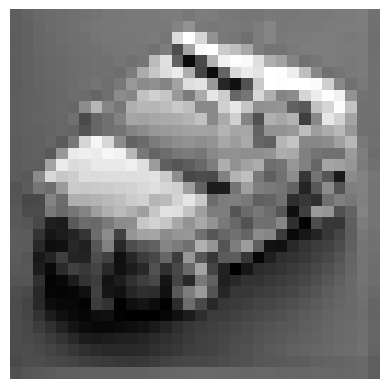

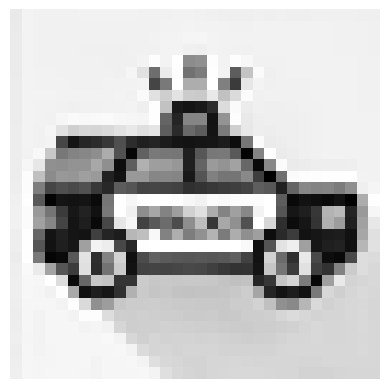

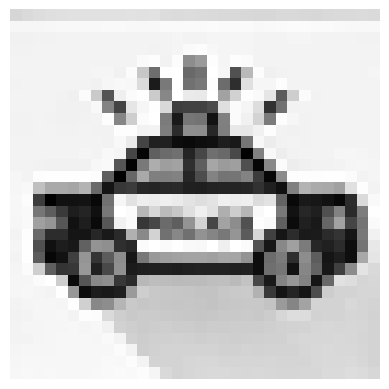

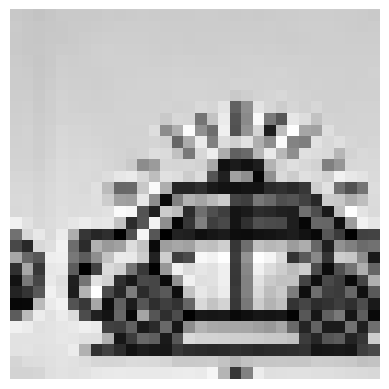

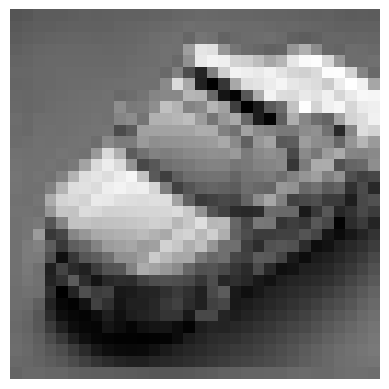

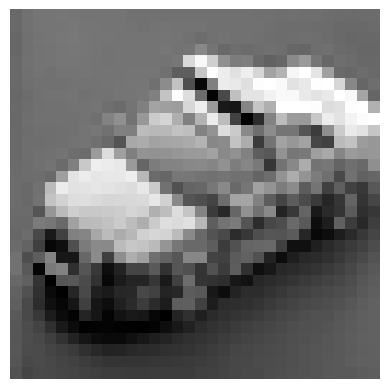

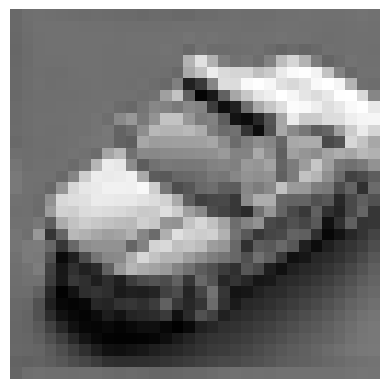

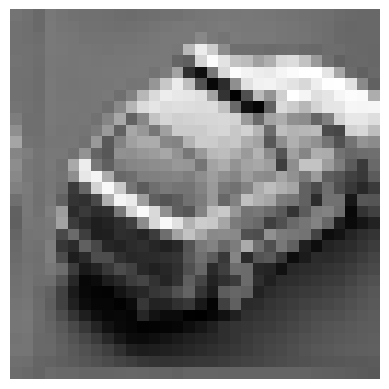

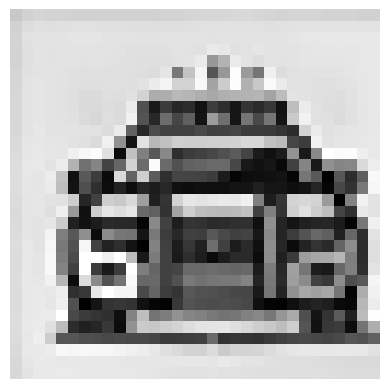

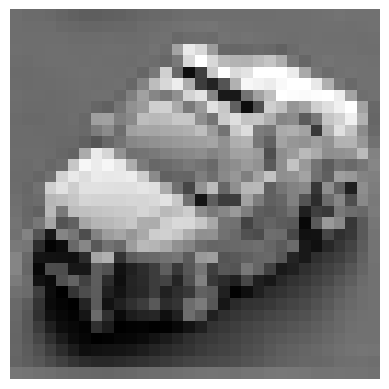

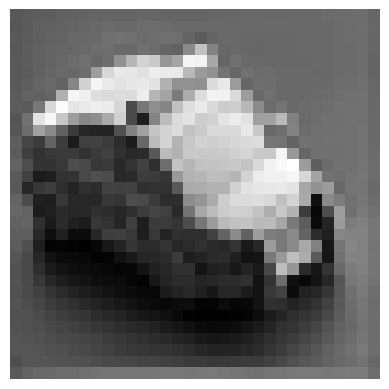

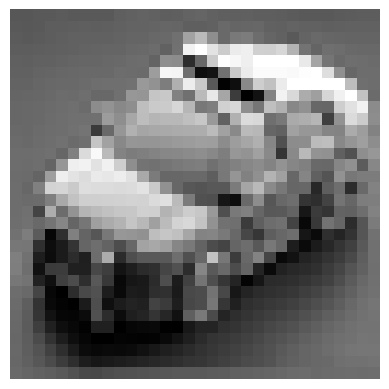

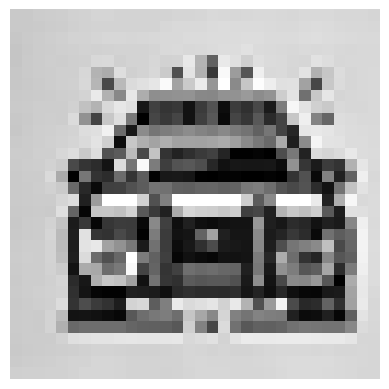

Label: apple, Len: 51


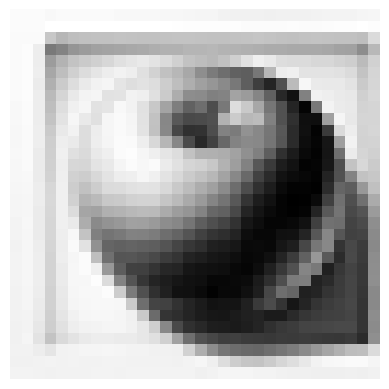

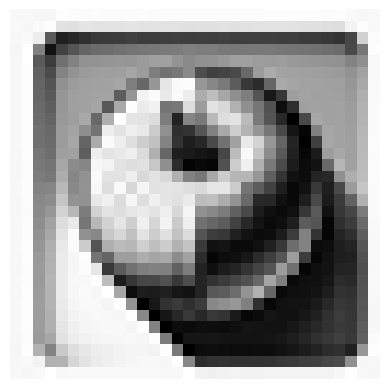

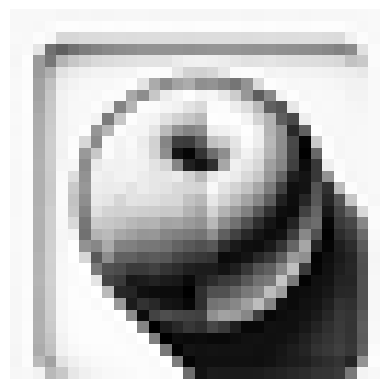

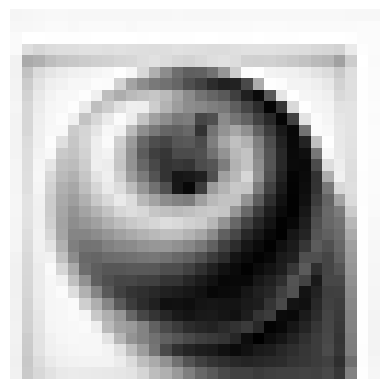

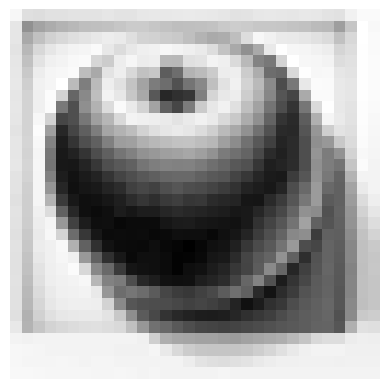

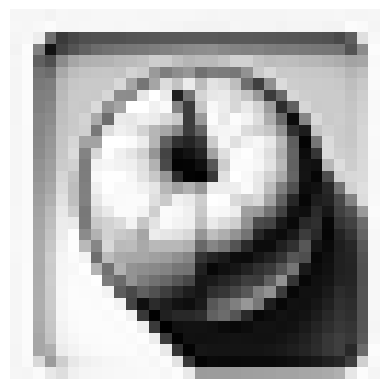

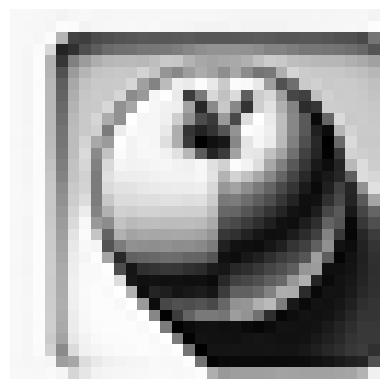

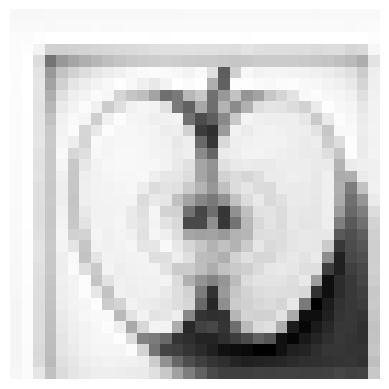

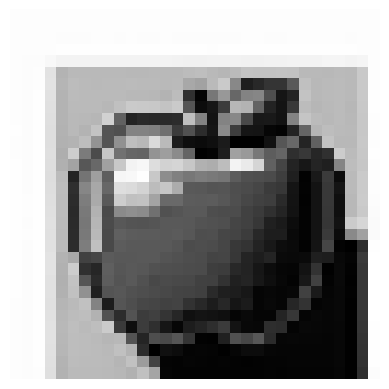

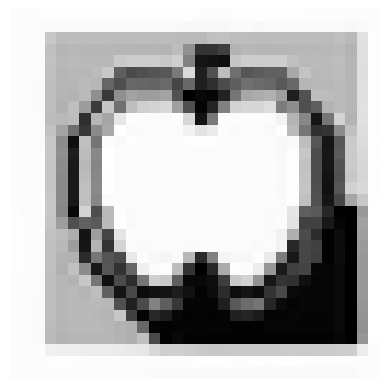

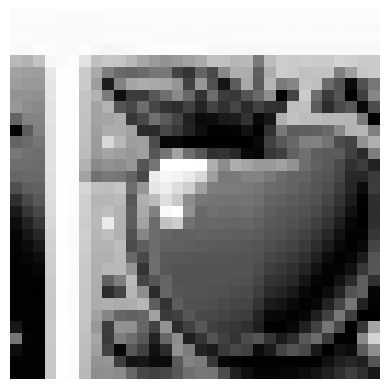

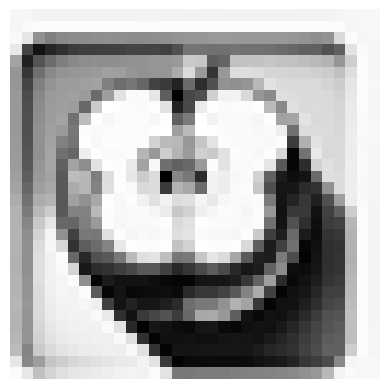

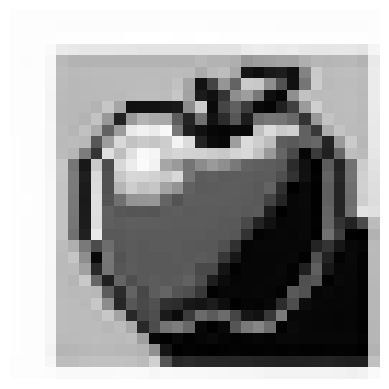

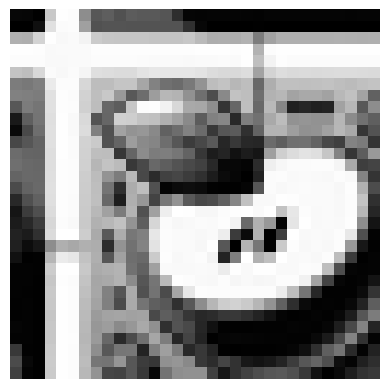

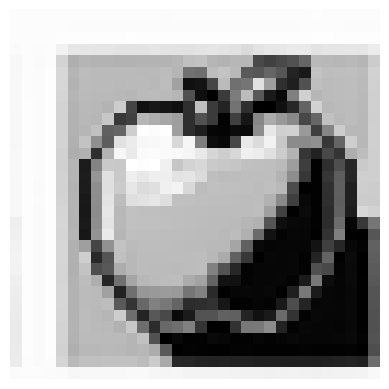

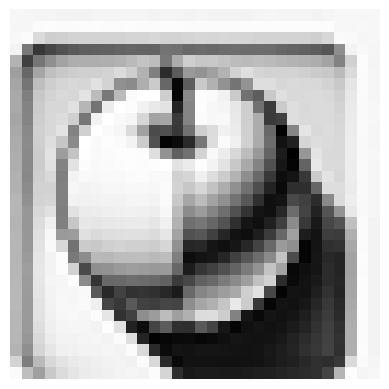

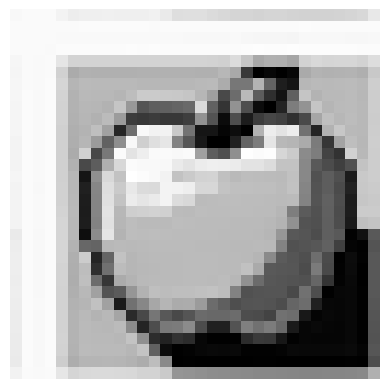

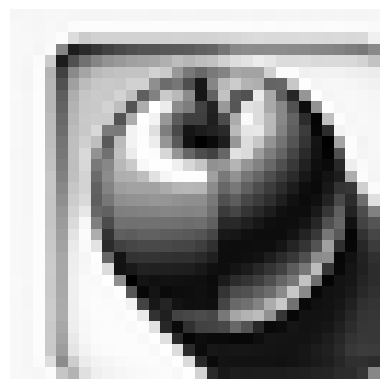

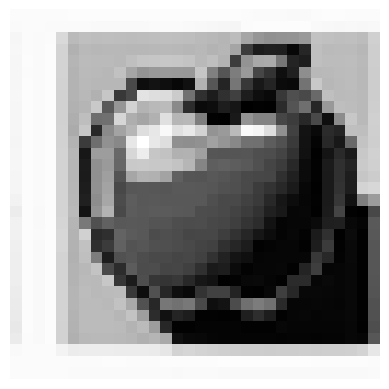

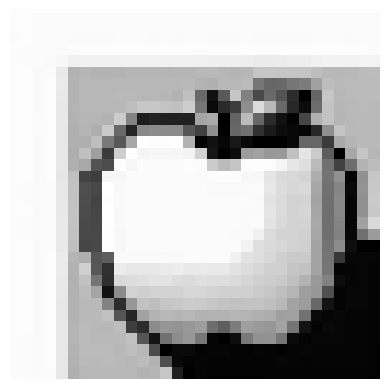

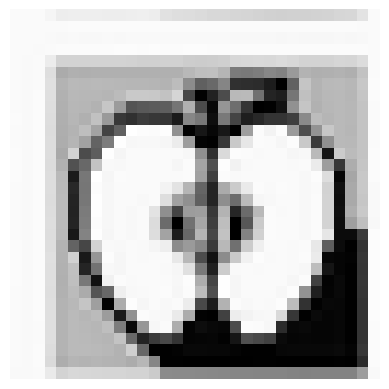

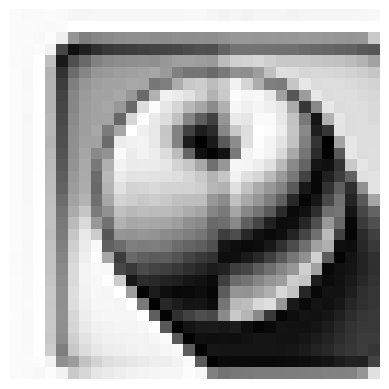

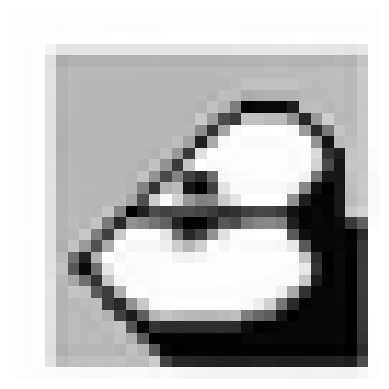

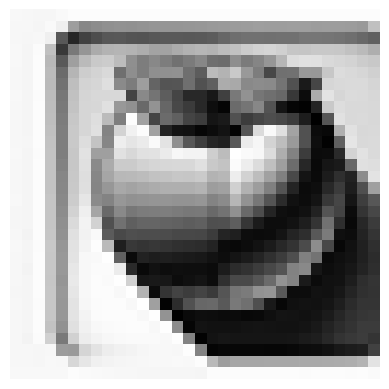

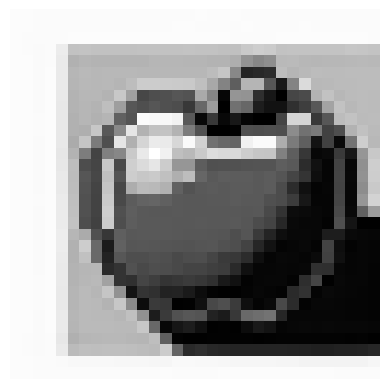

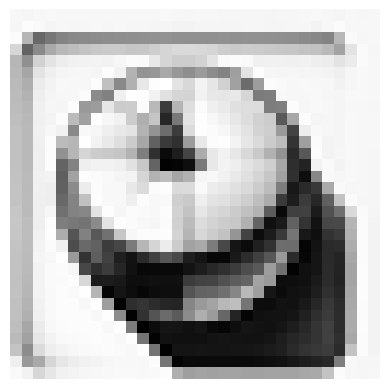

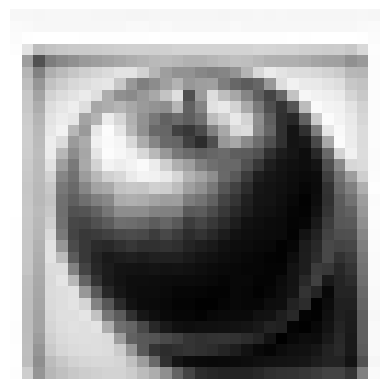

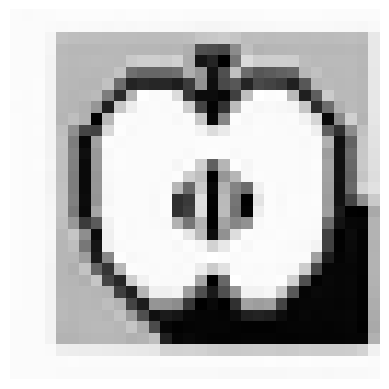

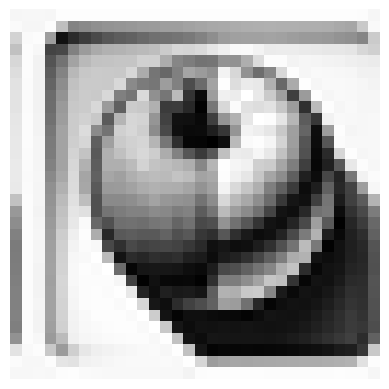

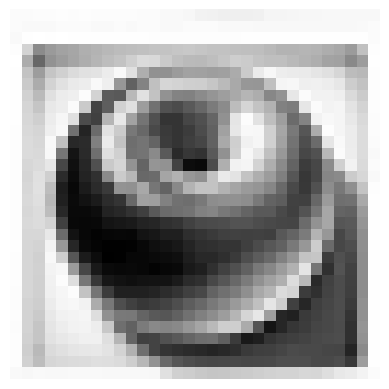

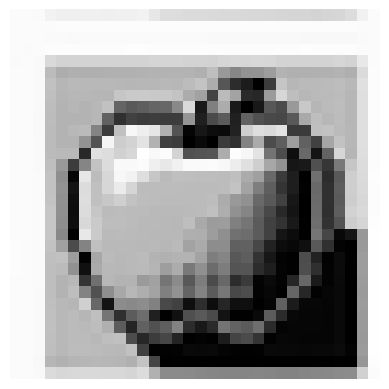

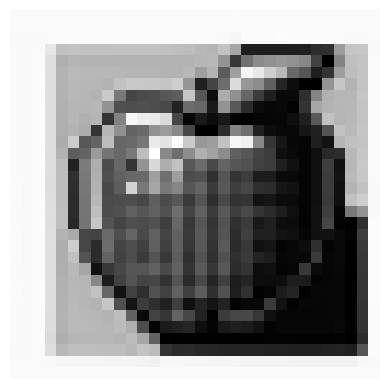

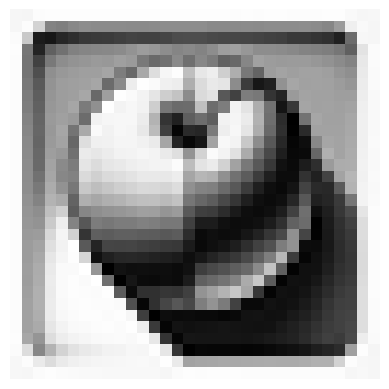

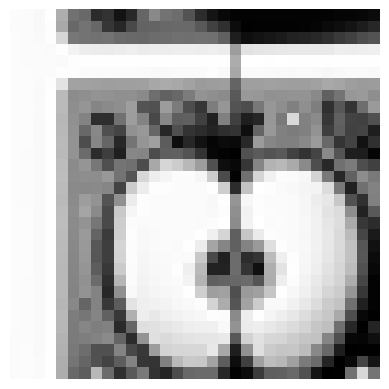

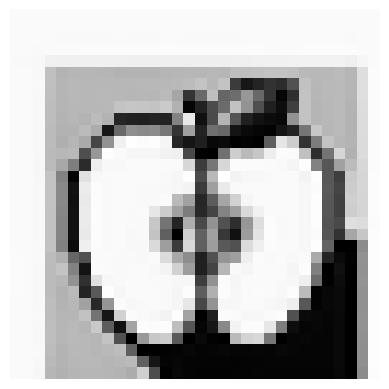

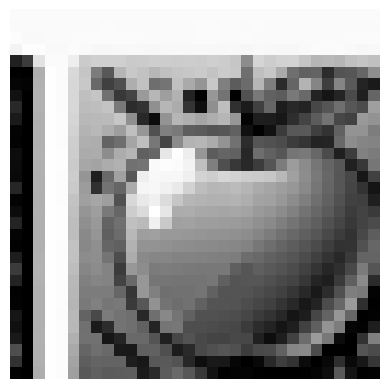

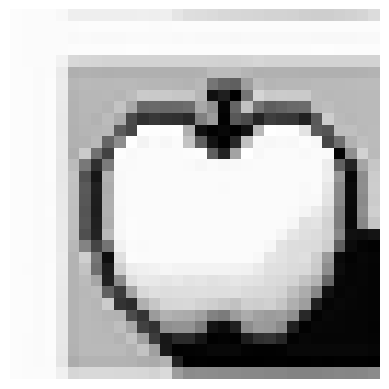

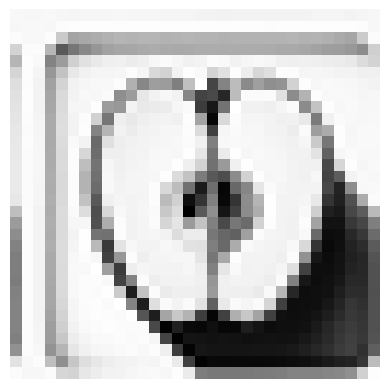

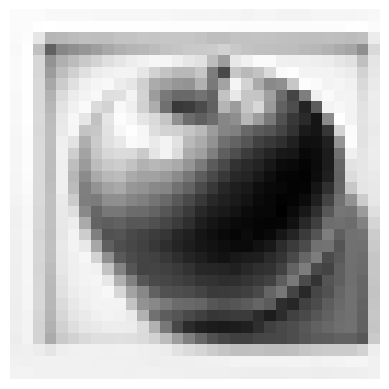

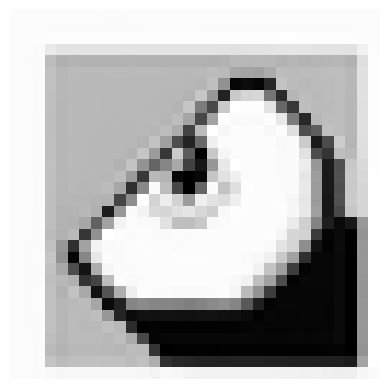

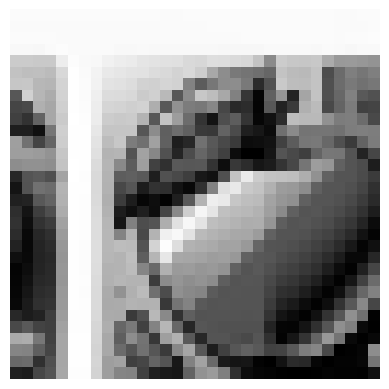

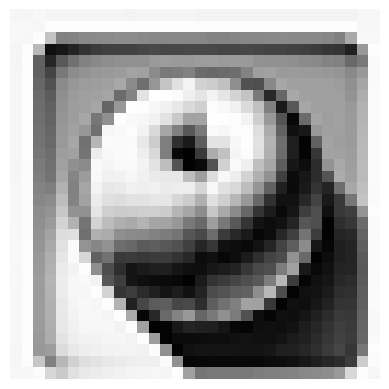

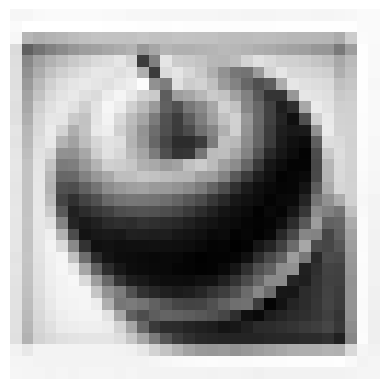

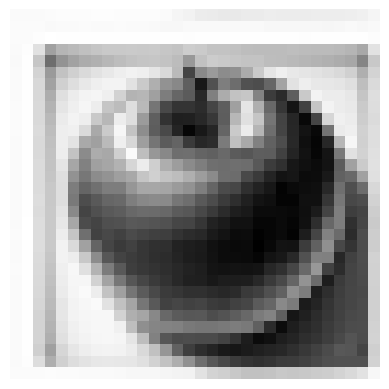

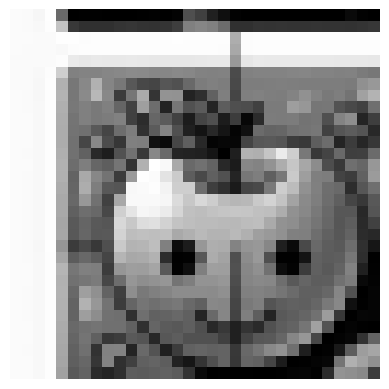

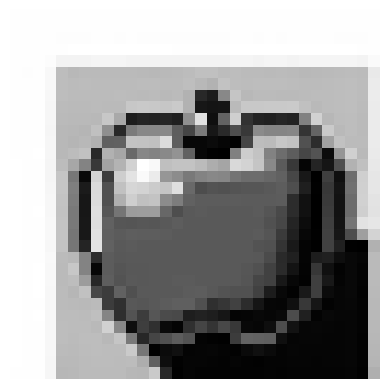

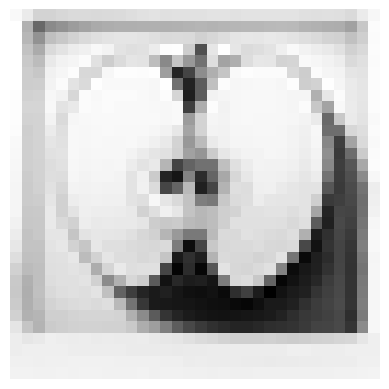

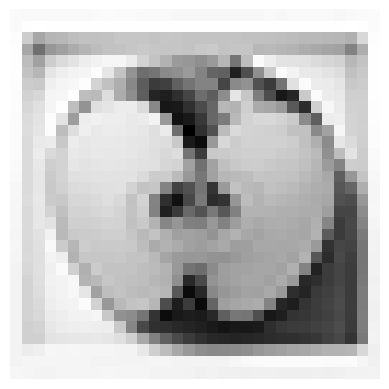

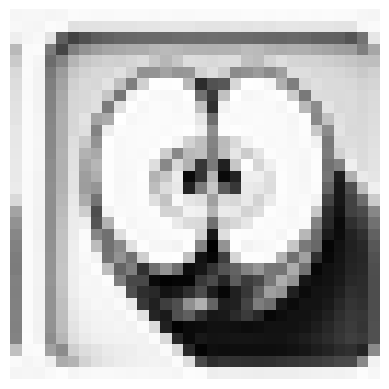

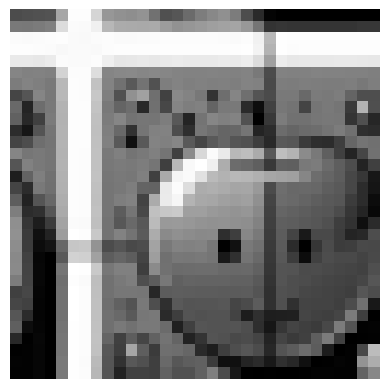

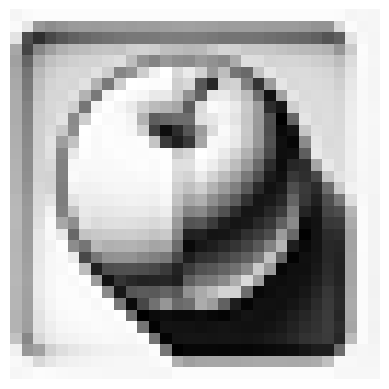

In [19]:
import matplotlib.pyplot as plt

labels = train['label'].unique()  # 고유 라벨 가져오기

for label in labels:
    label_idxs = train[train['label'] == label].index  # 해당 라벨의 모든 인덱스 가져오기
    
    print(f"Label: {label}, Len: {len(label_idxs)}")  # 현재 라벨 출력
    
    for idx in label_idxs:
        image = train.iloc[idx, 2:].values.astype('uint8').reshape(32, 32)  # 이미지 변환
        
        plt.imshow(image, cmap='gray')
        plt.axis('off')
        plt.show()  # 한 이미지씩 출력

In [2]:
image = train.iloc[0, 2:].values.astype('uint8').reshape(32, 32)  # 이미지 변환

### Kernel Test

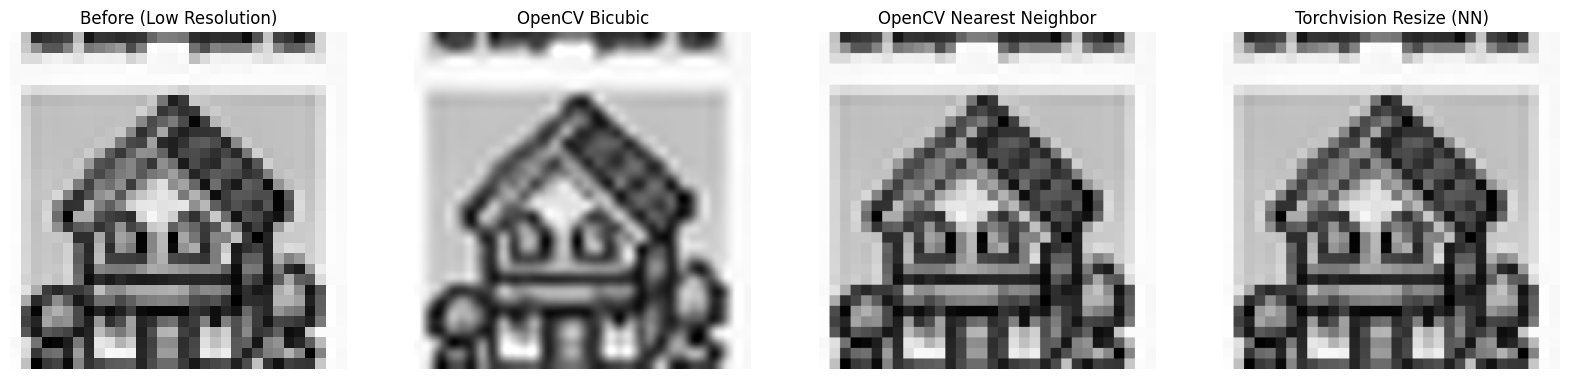

In [35]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
from PIL import Image
import torch


def upscale_image(img, scale=2):
    """저해상도 이미지를 Bicubic Interpolation으로 업스케일"""
    # img = cv2.imread(image_path, cv2.IMREAD_COLOR)
    
    h, w = img.shape[:2]
    img_upscaled = cv2.resize(img, (w*scale, h*scale), interpolation=cv2.INTER_CUBIC)
    origin_img_upscaled = cv2.resize(img, (w*scale, h*scale) , interpolation=cv2.INTER_NEAREST)
    return img_upscaled, origin_img_upscaled
    
def upscale_image_torchvision(img, scale=2):
    """Torchvision의 transforms.Resize를 사용한 업스케일"""
    transform = transforms.Compose([
        transforms.Resize((img.shape[0] * scale, img.shape[1] * scale), interpolation=transforms.InterpolationMode.NEAREST),
        transforms.ToTensor()
    ])
    img_pil = Image.fromarray(img)
    img_resized = transform(img_pil).permute(1, 2, 0).numpy()  # HWC로 변환
    return (img_resized * 255).astype(np.uint8)
    
# 사용 예시
upscaled, origin_upscaled = upscale_image(image, scale=7) # 32 -> 224
upscaled_torch = upscale_image_torchvision(image, scale=7) # 32 -> 224

# Before & After 비교
plt.figure(figsize=(20, 5))

# 원본 (저해상도)
plt.subplot(1, 4, 1)
plt.title("Before (Low Resolution)")
plt.imshow(image, cmap = 'gray')
plt.axis("off")

# Bicubic (부드러운 업스케일링)
plt.subplot(1, 4, 2)
plt.title("OpenCV Bicubic")
plt.imshow(upscaled, cmap = 'gray')
plt.axis("off")

# Nearest Neighbor (픽셀 블록 현상)
plt.subplot(1, 4, 3)
plt.title("OpenCV Nearest Neighbor")
plt.imshow(origin_upscaled, cmap = 'gray')
plt.axis("off")

# Torchvision Resize (PyTorch Bicubic)
plt.subplot(1, 4, 4)
plt.title("Torchvision Resize (NN)")
plt.imshow(upscaled_torch, cmap = 'gray')
plt.axis("off")

plt.show()

### Model 검사

In [139]:
import timm
model = timm.create_model('timm/resnet50.a1_in1k', 
                      num_classes=10, in_chans=1,
                      pretrained=False)  # 사전 훈련된 가중치 로드

In [140]:
class CustomConv(nn.Module):
    def __init__(self, in_channels=1, out_channels=64):
        super().__init__()
        # 각 branch의 채널 수를 계산
        ch1 = out_channels // 3            # 예: 64//3 = 21
        ch2 = out_channels // 3            # 21
        ch3 = out_channels - ch1 - ch2     # 64 - 21 - 21 = 22

        # 세 개의 다른 커널 크기의 Conv 레이어 적용
        self.conv_3x3 = nn.Conv2d(in_channels, ch1, kernel_size=3, padding=1)
        self.conv_5x5 = nn.Conv2d(in_channels, ch2, kernel_size=5, padding=2)
        self.conv_7x7 = nn.Conv2d(in_channels, ch3, kernel_size=7, padding=3)
        
        # 1x1 Conv로 출력 채널을 64로 맞추기 (안정적인 학습을 위해)
        self.conv1x1 = nn.Conv2d(out_channels, out_channels, kernel_size=1, stride=1, bias=False)
        
    def forward(self, x):
        # 여러 Conv 적용 후 병합
        out_3x3 = self.conv_3x3(x)
        out_5x5 = self.conv_5x5(x)
        out_7x7 = self.conv_7x7(x)
        
        # Concatenation 후 1x1 Conv로 차원 조정
        out = torch.cat([out_3x3, out_5x5, out_7x7], dim=1)
        out = self.conv1x1(out)

        return out

# 모델의 Stem 교체
model.conv1 = CustomConv()
# model.bn1 = nn.BatchNorm2d(192)

# model.layer1[0].conv1 = nn.Conv2d(192, 64, kernel_size=1, stride=1, bias=False)
print(model)

ResNet(
  (conv1): CustomConv(
    (conv_3x3): Conv2d(1, 21, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv_5x5): Conv2d(1, 21, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (conv_7x7): Conv2d(1, 22, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
    (conv1x1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
  )
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act1): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act1): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     

In [141]:
dummy_dataset = torch.randn(1, 1, 224, 224)

output = model(dummy_dataset)

print("Input Shape:", example_input.shape)
print("Output Shape:", output.shape)

Input Shape: torch.Size([1, 1, 224, 224])
Output Shape: torch.Size([1, 10])


In [105]:
import torch

def count_model_parameters(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    return {
        "Total Parameters": total_params,
        "Trainable Parameters": trainable_params
    }

param_counts = count_model_parameters(CustomModel())
print(f"Total Parameters: {param_counts['Total Parameters']}")
print(f"Trainable Parameters: {param_counts['Trainable Parameters']}")

Total Parameters: 23738122
Trainable Parameters: 23738122
